## Notebook 1 — Paired-Control Stream Design Validation

### Analysis units and independence assumptions

The physical QRNG call is the source observation: bit 0 assigns labels, bits 1–150 form physical half A, and bits 151–300 form physical half B. The analysis then reconstructs the labeled **Subject** and **Paired Control Stream (PCS)** halves and calculates row-aligned paired estimands.

Blocks from the same session—and repeated sessions from the same Human participant—are not assumed statistically independent merely because the QRNG calls are distinct. Point estimates may be block-weighted when that is the stated estimand, but uncertainty and null procedures must preserve the relevant session and participant structure. Each analysis below states its observational unit, inferential unit, estimand, and resampling scheme.

Canonical paired estimands are:

- `delta_hit = subject_hit_rate - pcs_hit_rate`
- `delta_hurst = subject_hurst - pcs_hurst`

Legacy source fields containing `demon` are retained only as compatibility aliases for PCS. Raw fractions of ones are composition measures, not hit rates; hit rates are always scored against each row's actual `target_bit`.

Sensitivity calculations characterize resolution, not proof that smaller effects are absent. Null findings are not treated as proof of independence, equivalence, universal artifact cancellation, or absence of all hardware structure.

The notebook's temporal ordering metric is the single-scale score
`log(R/S) / log(n)` computed once at `n = 150`. It is retained as an ordering-sensitive
R/S summary. It is not a classical multiscale Hurst-exponent estimate and is not direct
evidence of long-range dependence.


### Load Frozen Data

Place these five frozen data files either in the same folder from which this notebook is run or in a `data/` subfolder:

- `Frozen_Blocks_2026-02-10_195735.csv`
- `Frozen_Sessions_2026-02-10_195735.csv`
- `Frozen_Participants_2026-02-10_195735.csv`
- `Frozen_Audits_2026-02-10_195735.csv`
- `Frozen_Exp4_RawBlockBits_2026-07-26*.pkl` (the wildcard accepts a download suffix such as `(1)`)

The setup searches the current project folder recursively, requires exactly one copy of each file, and stops with a clear error if a file is missing or duplicated. It does not depend on ChatGPT storage paths or download mutable internet data.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import ast
import pickle
import hashlib
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp
from numpy.random import default_rng

warnings.filterwarnings("ignore")

STRUCTURAL_REVISION = "2026-08-04 structural gates 1-8"

REQUIRED_INPUTS = {
    "blocks": "Frozen_Blocks_2026-02-10_195735.csv",
    "sessions": "Frozen_Sessions_2026-02-10_195735.csv",
    "participants": "Frozen_Participants_2026-02-10_195735.csv",
    "audits": "Frozen_Audits_2026-02-10_195735.csv",
    "raw_calls": "Frozen_Exp4_RawBlockBits_2026-07-26*.pkl",
}

def locate_required_inputs(filenames, search_root=None):
    """Find one unambiguous local copy of every frozen input file."""
    root = Path.cwd() if search_root is None else Path(search_root)
    resolved = {}
    problems = []
    for label, filename_pattern in filenames.items():
        # Common layouts are checked first; recursive search supports a project
        # root containing notebook/ and data/ subfolders.
        candidates = []
        for parent in (root, root / "data"):
            if parent.is_dir():
                candidates.extend(path.resolve() for path in parent.glob(filename_pattern) if path.is_file())
        if not candidates:
            candidates = [
                path.resolve()
                for path in root.rglob(filename_pattern)
                if path.is_file()
            ]
        candidates = sorted(set(candidates))
        if len(candidates) == 1:
            resolved[label] = str(candidates[0])
        elif len(candidates) == 0:
            problems.append(f"MISSING: {filename_pattern}")
        else:
            locations = ", ".join(str(path) for path in candidates)
            problems.append(f"DUPLICATED accepted input for {label}: {locations}")
    if problems:
        expected = "\n".join(f"  - {pattern}" for pattern in filenames.values())
        details = "\n".join(problems)
        raise FileNotFoundError(
            "Frozen input-file check failed.\n"
            f"{details}\n\n"
            "Place exactly one copy of each required file in the notebook's working "
            "folder or its data/ subfolder:\n"
            f"{expected}\n"
            f"Current search root: {root.resolve()}"
        )
    return resolved

INPUT_PATHS = locate_required_inputs(REQUIRED_INPUTS)
FROZEN_BLOCKS_PATH = INPUT_PATHS["blocks"]
FROZEN_SESSIONS_PATH = INPUT_PATHS["sessions"]
FROZEN_PARTICIPANTS_PATH = INPUT_PATHS["participants"]
FROZEN_AUDITS_PATH = INPUT_PATHS["audits"]
FROZEN_RAW_BITS_PATH = INPUT_PATHS["raw_calls"]

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_manifest = pd.DataFrame([
    {
        "label": label,
        "filename": Path(path).name,
        "bytes": Path(path).stat().st_size,
        "sha256": sha256_file(path),
    }
    for label, path in INPUT_PATHS.items()
])

print("Loading frozen data once...")
df_blocks_raw = pd.read_csv(FROZEN_BLOCKS_PATH)
df_sessions_raw = pd.read_csv(FROZEN_SESSIONS_PATH)
df_participants_raw = pd.read_csv(FROZEN_PARTICIPANTS_PATH)
df_audits_raw = pd.read_csv(FROZEN_AUDITS_PATH)

with open(FROZEN_RAW_BITS_PATH, "rb") as handle:
    raw_call_mapping = pickle.load(handle)

assert isinstance(raw_call_mapping, dict), "Raw-call pickle must be a session-keyed dictionary"
raw_call_rows = [
    (session_id, block_idx, bits301)
    for session_id, session_calls in raw_call_mapping.items()
    for block_idx, bits301 in session_calls
]
df_raw_calls = pd.DataFrame(raw_call_rows, columns=["session_id", "block_idx", "bits301"])
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any(), "Duplicate raw-call key"
valid_301 = df_raw_calls["bits301"].apply(
    lambda value: isinstance(value, str) and len(value) == 301 and set(value) <= {"0", "1"}
)
assert valid_301.all(), f"Invalid 301-bit strings: {(~valid_301).sum()}"
df_raw_calls["bit0"] = df_raw_calls["bits301"].str[0].astype("int8")
df_raw_calls["halfA"] = df_raw_calls["bits301"].str[1:151].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["halfB"] = df_raw_calls["bits301"].str[151:301].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["raw_sha256"] = df_raw_calls["bits301"].apply(
    lambda value: hashlib.sha256(value.encode("ascii")).hexdigest()
)

# Compatibility names: these objects are never mutated downstream.
df_blocks = df_blocks_raw.copy()
df_participants = df_participants_raw.copy()
df_audits = df_audits_raw.copy()

assert not df_sessions_raw["sessionId"].duplicated().any(), "Duplicate sessionId in Sessions"
assert not df_participants_raw["participant_id"].duplicated().any(), "Duplicate participant_id"
assert not df_blocks_raw.duplicated(["sessionId", "block_idx"]).any(), "Duplicate block key"

df_sessions = df_sessions_raw.rename(
    columns={"sessionId": "session_id", "agent_class": "condition"}
).copy()
df_audits_norm = df_audits_raw.rename(columns={"sessionId": "session_id"}).copy()

def parse_trial_data(value):
    if isinstance(value, dict):
        return value
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, dict) else None
    except (ValueError, SyntaxError, TypeError):
        return None

def hurstApprox(bits):
    """Single-scale R/S estimator matching the experiment's JS implementation."""
    if bits is None:
        return np.nan
    try:
        bits = np.asarray(bits, dtype=int)
        n = bits.size
        if n < 20:
            return np.nan
        x = np.where(bits != 0, 1.0, -1.0)
        mean = float(x.sum() / n)
        y = min_y = max_y = s2 = 0.0
        for value in x:
            deviation = value - mean
            y += deviation
            min_y = min(min_y, y)
            max_y = max(max_y, y)
            s2 += deviation * deviation
        spread = max_y - min_y
        scale = np.sqrt(s2 / n) if s2 > 0 else 1.0
        ratio = spread / scale if np.isfinite(scale) and scale != 0 else 1.0
        ratio = ratio if np.isfinite(ratio) and ratio != 0 else 1.0
        estimate = np.log(ratio) / np.log(n)
        estimate = estimate if np.isfinite(estimate) else 0.5
        return float(np.clip(estimate, 0.0, 1.0))
    except (TypeError, ValueError):
        return np.nan

# Normalize blocks without altering the raw table.
df_blocks_norm = df_blocks_raw.rename(columns={"sessionId": "session_id"}).copy()
df_blocks_norm["parsed"] = df_blocks_norm["trial_data"].apply(parse_trial_data)
for column, key in {
    "subject_bits": "subject_bits",
    "demon_bits": "demon_bits",
    "target_bit": "target_bit",
    "trial_count": "trial_count",
}.items():
    df_blocks_norm[column] = df_blocks_norm["parsed"].apply(
        lambda value, k=key: value.get(k) if value else None
    )

def target_aligned_rate(bits, target):
    """Fraction of bits equal to this row's target (not the fraction of ones)."""
    if target not in (0, 1) or not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    array = np.asarray(bits, dtype=np.int8)
    return float(np.mean(array == int(target)))

def one_fraction(bits):
    """Literal fraction of ones; a composition metric, never a hit rate."""
    if not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    return float(np.mean(np.asarray(bits, dtype=np.int8)))

df_blocks_norm["subject_hit_rate"] = df_blocks_norm["hits"] / 150.0
df_blocks_norm["pcs_hit_rate"] = df_blocks_norm["demon_hits"] / 150.0
df_blocks_norm["delta_hit"] = (
    df_blocks_norm["subject_hit_rate"] - df_blocks_norm["pcs_hit_rate"]
)

# Explicit composition variables prevent target-0 blocks from being scored as if
# the target were always 1.
df_blocks_norm["subject_one_fraction"] = df_blocks_norm["subject_bits"].apply(one_fraction)
df_blocks_norm["pcs_one_fraction"] = df_blocks_norm["demon_bits"].apply(one_fraction)
df_blocks_norm["subject_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["subject_bits"], row["target_bit"]), axis=1
)
df_blocks_norm["pcs_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["demon_bits"], row["target_bit"]), axis=1
)

# Compatibility aliases used by legacy downstream cells.
df_blocks_norm["rate_subject"] = df_blocks_norm["subject_hit_rate"]
df_blocks_norm["rate_pcs"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["rate_demon"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["delta_rate"] = df_blocks_norm["delta_hit"]
df_blocks_norm["subject_bit_length"] = df_blocks_norm["subject_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)
df_blocks_norm["demon_bit_length"] = df_blocks_norm["demon_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)

print("Computing single-scale R/S ordering scores...")
df_blocks_norm["hurst_subject"] = df_blocks_norm["subject_bits"].apply(hurstApprox)
df_blocks_norm["hurst_demon"] = df_blocks_norm["demon_bits"].apply(hurstApprox)
df_blocks_norm["hurst_pcs"] = df_blocks_norm["hurst_demon"]
df_blocks_norm["delta_hurst"] = (
    df_blocks_norm["hurst_subject"] - df_blocks_norm["hurst_pcs"]
)
df_blocks_norm["hurst_delta"] = df_blocks_norm["delta_hurst"]  # compatibility alias

# Reconcile raw pre-split calls with frozen blocks before analysis filtering.
df_raw_block_reconciliation = df_raw_calls.merge(
    df_blocks_norm[["session_id", "block_idx", "block_id", "qrng_hash", "subject_bits", "demon_bits", "target_bit", "hits", "demon_hits", "subject_hit_rate_reconstructed", "pcs_hit_rate_reconstructed"]],
    on=["session_id", "block_idx"], how="outer", validate="one_to_one", indicator="_raw_block_join"
)
raw_calls_without_block = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "left_only",
    ["session_id", "block_idx", "bits301"]
].copy()
blocks_without_raw_call = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "right_only",
    ["session_id", "block_idx", "block_id"]
].copy()

raw_matched = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "both"
].copy()
hash_match = raw_matched["raw_sha256"].eq(raw_matched["qrng_hash"])
assert hash_match.all(), f"Raw-call hash mismatches: {(~hash_match).sum()}"

def reconstructed_labels_match(row):
    expected_subject, expected_pcs = (
        (row["halfA"], row["halfB"]) if row["bit0"] == 1
        else (row["halfB"], row["halfA"])
    )
    return (
        np.array_equal(np.asarray(row["subject_bits"], dtype=np.int8), expected_subject)
        and np.array_equal(np.asarray(row["demon_bits"], dtype=np.int8), expected_pcs)
    )

raw_matched["labels_reconstruct"] = raw_matched.apply(reconstructed_labels_match, axis=1)
assert raw_matched["labels_reconstruct"].all(), (
    f"Raw-call label reconstruction mismatches: {(~raw_matched['labels_reconstruct']).sum()}"
)

valid_scoring = (
    raw_matched["target_bit"].isin([0, 1])
    & raw_matched["subject_hit_rate_reconstructed"].notna()
    & raw_matched["pcs_hit_rate_reconstructed"].notna()
)
assert valid_scoring.all(), f"Unscorable matched rows: {(~valid_scoring).sum()}"
assert np.allclose(
    raw_matched["subject_hit_rate_reconstructed"], raw_matched["hits"] / 150.0
), "Stored Subject hit counts disagree with target-aligned raw-bit scoring"
assert np.allclose(
    raw_matched["pcs_hit_rate_reconstructed"], raw_matched["demon_hits"] / 150.0
), "Stored PCS hit counts disagree with target-aligned raw-bit scoring"

# Validate the many-blocks-to-one-session join and preserve unmatched rows for QA.
df_joined_raw = df_blocks_norm.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one", indicator="_session_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Session join changed block-row count"
unmatched_block_sessions = df_joined_raw.loc[
    df_joined_raw["_session_join"] == "left_only", ["session_id", "block_id", "block_idx"]
].copy()

# Participant metadata are not present for all system/AI identifiers. Preserve and
# report those unmatched identifiers rather than silently calling them participants.
participant_metadata = df_participants_raw.rename(
    columns={c: f"participant_{c}" for c in df_participants_raw.columns if c != "participant_id"}
)
df_joined_raw = df_joined_raw.merge(
    participant_metadata, on="participant_id", how="left", validate="many_to_one",
    indicator="_participant_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Participant join changed block-row count"
unmatched_participant_sessions = df_joined_raw.loc[
    df_joined_raw["_participant_join"] == "left_only",
    ["session_id", "participant_id", "condition"]
].drop_duplicates().copy()

# Audits are one-to-many within session. Keep the row-level audit table separate and
# join only a one-row-per-session summary to blocks to avoid multiplying block rows.
df_audit_session = (
    df_audits_norm.groupby("session_id", as_index=False)
    .agg(
        audit_count=("audit_id", "size"),
        audit_failures=("is_random", lambda x: int((x == False).sum())),
        audit_nist_complete=("nist_all_pass", lambda x: int(x.notna().sum())),
        audit_first_timestamp=("qrng_timestamp", "min"),
        audit_last_timestamp=("qrng_timestamp", "max"),
    )
)
df_joined_raw = df_joined_raw.merge(
    df_audit_session, on="session_id", how="left", validate="many_to_one"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Audit-summary join changed block-row count"

# Canonical analysis cohort: required outcomes/session metadata, then >=25 retained
# blocks per session. Every exclusion is recorded for the integrity audit.
required_mask = df_joined_raw[["rate_subject", "rate_demon", "condition"]].notna().all(axis=1)
df_required = df_joined_raw.loc[required_mask].copy()
required_session_sizes = df_required.groupby("session_id").size()
eligible_session_ids = required_session_sizes[required_session_sizes >= 25].index
eligible_mask = df_required["session_id"].isin(eligible_session_ids)
df = df_required.loc[eligible_mask].copy()

# Every retained analysis block must have an authenticated raw call. Raw-only calls
# are retained in the reconciliation ledger but cannot silently enter analyses.
retained_raw_check = df[["session_id", "block_idx"]].merge(
    df_raw_calls[["session_id", "block_idx"]],
    on=["session_id", "block_idx"], how="left", validate="one_to_one", indicator=True
)
assert retained_raw_check["_merge"].eq("both").all(), (
    f"Retained blocks lacking raw 301-bit calls: "
    f"{(~retained_raw_check['_merge'].eq('both')).sum()}"
)

valid_session_counts = (
    df.groupby(["participant_id", "condition"])["session_id"]
    .nunique().rename("session_count").reset_index()
)
df = df.merge(
    valid_session_counts, on=["participant_id", "condition"], how="left", validate="many_to_one"
)
df["session_count"] = df["session_count"].fillna(1).astype(int)

analysis_units = pd.DataFrame([
    {"object": "raw QRNG call", "key": "session_id + block_idx", "role": "physical source observation"},
    {"object": "paired block", "key": "session_id + block_idx", "role": "row-aligned Subject−PCS estimand"},
    {"object": "session", "key": "session_id", "role": "minimum resampling cluster for condition/session inference"},
    {"object": "Human participant", "key": "participant_id", "role": "higher cluster for repeated-Human sensitivity"},
])

def cluster_bootstrap_mean(data, value_col, cluster_col="session_id", n_boot=5000, seed=20260804):
    """Block-weighted mean with whole-cluster bootstrap uncertainty."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    keys = grouped.index.to_numpy()
    rng_local = default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng_local.choice(keys, size=len(keys), replace=True)
        draws[i] = grouped.loc[sampled, "sum"].sum() / grouped.loc[sampled, "count"].sum()
    estimate = work[value_col].mean()
    lo, hi = np.quantile(draws, [0.025, 0.975])
    return {"estimate": estimate, "ci_low": lo, "ci_high": hi, "n_clusters": len(keys), "n_boot": n_boot}

def clustered_paired_signflip(data, value_col, cluster_col="session_id", n_perm=10000, seed=20260804):
    """Sign-flip whole session clusters; pairing is preserved inside each row."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    observed = work[value_col].mean()
    rng_local = default_rng(seed)
    signs = rng_local.choice((-1.0, 1.0), size=(n_perm, len(grouped)))
    null = (signs * grouped["sum"].to_numpy()).sum(axis=1) / grouped["count"].sum()
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (n_perm + 1)
    return {"estimate": observed, "p_value": p_value, "n_clusters": len(grouped), "n_perm": n_perm}

setup_exclusions = pd.DataFrame([
    {"stage": "raw blocks", "excluded_rows": 0, "remaining_rows": len(df_blocks_norm)},
    {"stage": "missing required outcome/session metadata", "excluded_rows": int((~required_mask).sum()), "remaining_rows": len(df_required)},
    {"stage": "sessions with fewer than 25 retained blocks", "excluded_rows": int((~eligible_mask).sum()), "remaining_rows": len(df)},
])

# Reusable canonical subsets. Downstream analyses should create local views and must
# not overwrite these names.
df_hurst = df.dropna(subset=["hurst_subject", "hurst_demon"]).copy()
df_valid_bits = df.loc[
    df["subject_bit_length"].eq(150) & df["demon_bit_length"].eq(150)
].copy()
df_repeat = df[df["session_count"] >= 5].copy()
df_repeat_hurst = df_hurst[df_hurst["session_count"] >= 5].copy()
df_single = df[df["session_count"] == 1].copy()
human_df = df[df["condition"] == "human"].copy()
ai_df = df[df["condition"] == "ai_agent"].copy()
base_df = df[df["condition"] == "baseline"].copy()
df_base = base_df.copy()  # compatibility alias; do not overwrite downstream
df_base_h = df_hurst[df_hurst["condition"] == "baseline"].copy()
base_hurst_df = df_base_h.copy()


df_raw_calls_with_session = df_raw_calls.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one"
)
baseline_raw_calls = df_raw_calls_with_session.loc[
    df_raw_calls_with_session["condition"].eq("baseline")
    & df_raw_calls_with_session["session_id"].isin(eligible_session_ids)
].copy()

h_1 = human_df[human_df["session_count"] == 1].copy()
h_2_4 = human_df[human_df["session_count"].between(2, 4)].copy()
h_5plus = human_df[human_df["session_count"] >= 5].copy()
n_human_total = human_df["participant_id"].nunique()

print("\nFrozen-input manifest")
print(input_manifest.to_string(index=False))
print("\nCanonical dataset ready")
print(setup_exclusions.to_string(index=False))
print("\nBlocks by condition:", df["condition"].value_counts().to_dict())
print("Sessions:", df["session_id"].nunique())
print("Human participants:", n_human_total)
print("Unmatched raw block rows retained for QA:", len(unmatched_block_sessions))
print("Raw calls / matched blocks:", len(df_raw_calls), len(raw_matched))
print("Raw calls without frozen block / blocks without raw call:", len(raw_calls_without_block), len(blocks_without_raw_call))
print("Baseline raw calls:", len(baseline_raw_calls))
print("Canonical paired columns: subject_hit_rate, pcs_hit_rate, delta_hit, hurst_subject, hurst_pcs, delta_hurst")
print("Objects: raw tables, normalized tables, df_joined_raw, df, df_hurst, df_valid_bits,")
print("         df_repeat, df_repeat_hurst, df_single, human_df, ai_df, base_df,")
print("         df_base, df_base_h, df_audit_session, df_raw_calls, baseline_raw_calls,")
print("         df_raw_block_reconciliation, setup_exclusions")


Loading frozen data once...
Computing single-scale R/S ordering scores...

Frozen-input manifest
       label                                  filename    bytes                                                           sha256
      blocks       Frozen_Blocks_2026-02-10_195735.csv 22044201 3328875750873c704abc47c872064c4878cb0f9d7f621a95dfdcc393b9f0b529
    sessions     Frozen_Sessions_2026-02-10_195735.csv   107732 6b54ae50ba65bcfaf2fe5a4f452765540dee2e1a3afd2da524418e5bc97f83b9
participants Frozen_Participants_2026-02-10_195735.csv    55638 9debd57c983725c2bd770e961a8fc34d5d405c8624a6b734a3d5a60d9ef362d3
      audits       Frozen_Audits_2026-02-10_195735.csv  2366384 3e6779ae2ac009934dd9360a18ed8421c7900e0d07c05eeaacfe254253b1e1d8
   raw_calls   Frozen_Exp4_RawBlockBits_2026-07-26.pkl  3959136 6cf3248d3ef2ac34f3bf9d18faaba5aeb72fdd19b9c3d78c0b3ed81e868498f7

Canonical dataset ready
                                      stage  excluded_rows  remaining_rows
                             

### Structural Integrity Gates 1–4

**Scope:** frozen-data provenance and joins; raw-call split/assignment reconstruction; target-aligned scoring; and explicit analysis units.

This cell is fail-loud. A failed assertion means later analysis must not run. Passing these checks establishes that the supplied frozen files were loaded consistently and the retained rows encode the stated architecture. It does not establish statistical independence, unbiasedness, or artifact cancellation.


In [3]:
# STRUCTURAL GATES 1–4 — fail-loud architecture checks
print("=" * 76)
print("STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS")
print("=" * 76)

expected_counts = {"frozen_blocks": 11764, "retained_blocks": 11607, "excluded_rows": 157}
assert len(df_blocks_norm) == expected_counts["frozen_blocks"]
assert len(df) == expected_counts["retained_blocks"]
assert len(df_blocks_norm) - len(df) == expected_counts["excluded_rows"]
assert setup_exclusions["excluded_rows"].sum() == expected_counts["excluded_rows"]
assert len(unmatched_block_sessions) == 100
assert len(df_required) - len(df) == 57

# Join cardinality and retained raw coverage
assert not df_blocks_norm.duplicated(["session_id", "block_idx"]).any()
assert not df_sessions.duplicated("session_id").any()
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any()
assert len(df_joined_raw) == len(df_blocks_norm)
assert retained_raw_check["_merge"].eq("both").all()

# Raw call: bit 0 assigns labels; the two remaining halves are exactly 150 bits.
assert valid_301.all()
assert hash_match.all()
assert raw_matched["labels_reconstruct"].all()
assert raw_matched["halfA"].apply(len).eq(150).all()
assert raw_matched["halfB"].apply(len).eq(150).all()

# Target scoring: both target values must be represented and every stored count must
# equal raw-bit scoring against that row's actual target.
assert set(df["target_bit"].unique()) == {0, 1}
assert np.allclose(df["subject_hit_rate"], df["subject_hit_rate_reconstructed"])
assert np.allclose(df["pcs_hit_rate"], df["pcs_hit_rate_reconstructed"])
assert np.allclose(df["delta_hit"], df["subject_hit_rate"] - df["pcs_hit_rate"])
assert np.allclose(df_hurst["delta_hurst"], df_hurst["hurst_subject"] - df_hurst["hurst_pcs"])

integrity_report = pd.DataFrame([
    {"gate": "1 Frozen data and joins", "result": "verified", "detail": "11,764 raw block rows → 11,607 retained; 157 exclusions reconciled"},
    {"gate": "2 Stream reconstruction", "result": "verified", "detail": f"{len(raw_matched):,} matched calls; hashes and labels agree for every matched row"},
    {"gate": "3 Target alignment", "result": "verified", "detail": f"target 0={int((df.target_bit==0).sum()):,}; target 1={int((df.target_bit==1).sum()):,}; zero scoring mismatches"},
    {"gate": "4 Analysis units", "result": "defined", "detail": "block point estimands; session/participant clustering for inference"},
])
print(integrity_report.to_string(index=False))
print("\nExclusion ledger")
print(setup_exclusions.to_string(index=False))
print("\nAnalysis-unit registry")
print(analysis_units.to_string(index=False))
print("\nThese checks verify data encoding and reconstruction only; they do not establish statistical validity beyond those checks.")


STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS
                   gate   result                                                              detail
1 Frozen data and joins verified  11,764 raw block rows → 11,607 retained; 157 exclusions reconciled
2 Stream reconstruction verified 11,664 matched calls; hashes and labels agree for every matched row
     3 Target alignment verified             target 0=5,732; target 1=5,875; zero scoring mismatches
       4 Analysis units  defined block point estimands; session/participant clustering for inference

Exclusion ledger
                                      stage  excluded_rows  remaining_rows
                                 raw blocks              0           11764
  missing required outcome/session metadata            100           11664
sessions with fewer than 25 retained blocks             57           11607

Analysis-unit registry
           object                    key                                               

### Three-Subtest Audit-Battery Reconstruction and Session-Aware Summary

This audit uses the three stored NIST SP 800-22-style subtests available in the frozen data: Frequency (Monobit), Runs, and Longest Run of Ones. It is not a comprehensive SP 800-22 suite. Audit sequences are distinct 1,000-bit sequences nested within sessions, so uncertainty and condition comparisons resample or permute whole sessions.

The raw 1,000-bit strings permit an implementation-provenance check. Missing legacy subtest results are recovered only if the standard reconstruction reproduces the stored p-values and pass/fail decisions. Otherwise, the named battery is reported on the 1,771 audits with complete stored subtests, and the 120 legacy audits remain explicitly missing for that battery.


In [4]:
# THREE-SUBTEST AUDIT BATTERY — provenance, denominators, and clustered summaries
from scipy.special import erfc, gammaincc

AUDIT_ALPHA = 0.01
AUDIT_BOOT = 5000
AUDIT_PERM = 10000
AUDIT_SEED = 20260805

audit = df_audits_norm.merge(
    df_sessions[["session_id", "condition", "createdAt"]],
    on="session_id", how="left", validate="many_to_one"
).copy()
audit["audit_time"] = pd.to_datetime(audit["qrng_timestamp"], utc=True, errors="coerce")
audit["month"] = audit["audit_time"].dt.to_period("M").astype(str)

subtests = {
    "Frequency (Monobit)": ("nist_frequency_pass", "nist_frequency_pvalue"),
    "Runs": ("nist_runs_pass", "nist_runs_pvalue"),
    "Longest Run of Ones": ("nist_longest_run_pass", "nist_longest_run_pvalue"),
}
required_subtest_cols = [column for pair in subtests.values() for column in pair]
audit["stored_suite_complete"] = audit[required_subtest_cols].notna().all(axis=1)

valid_raw = audit["audit_bits"].apply(
    lambda value: isinstance(value, str) and len(value) == 1000 and set(value) <= {"0", "1"}
)
assert valid_raw.all(), f"Invalid stored 1,000-bit audit strings: {(~valid_raw).sum()}"

def audit_frequency_pvalue(bits):
    signs = np.fromiter((1.0 if bit == "1" else -1.0 for bit in bits), dtype=float)
    return float(erfc(abs(signs.sum()) / np.sqrt(2.0 * signs.size)))

def audit_runs_pvalue(bits):
    values = np.fromiter((int(bit) for bit in bits), dtype=np.int8)
    n = values.size
    pi = values.mean()
    if abs(pi - 0.5) >= 2.0 / np.sqrt(n):
        return 0.0
    runs = 1 + np.count_nonzero(values[1:] != values[:-1])
    denominator = 2.0 * np.sqrt(2.0 * n) * pi * (1.0 - pi)
    return float(erfc(abs(runs - 2.0 * n * pi * (1.0 - pi)) / denominator))

def audit_longest_run_pvalue(bits):
    # NIST SP 800-22 parameters for 128 <= n < 6,272: M=128, K=5, N=floor(n/M).
    values = np.fromiter((int(bit) for bit in bits), dtype=np.int8)
    block_size = 128
    n_blocks = values.size // block_size
    maxima = []
    for block in values[:n_blocks * block_size].reshape(n_blocks, block_size):
        longest = current = 0
        for value in block:
            current = current + 1 if value else 0
            longest = max(longest, current)
        maxima.append(longest)
    observed = np.array([
        np.count_nonzero(np.asarray(maxima) <= 4),
        np.count_nonzero(np.asarray(maxima) == 5),
        np.count_nonzero(np.asarray(maxima) == 6),
        np.count_nonzero(np.asarray(maxima) == 7),
        np.count_nonzero(np.asarray(maxima) == 8),
        np.count_nonzero(np.asarray(maxima) >= 9),
    ], dtype=float)
    probabilities = np.array([0.1174, 0.2430, 0.2493, 0.1752, 0.1027, 0.1124])
    chi_square = np.sum((observed - n_blocks * probabilities) ** 2 / (n_blocks * probabilities))
    return float(gammaincc(5.0 / 2.0, chi_square / 2.0))

reconstructors = {
    "Frequency (Monobit)": audit_frequency_pvalue,
    "Runs": audit_runs_pvalue,
    "Longest Run of Ones": audit_longest_run_pvalue,
}

verification_rows = []
for test_name, (_, p_col) in subtests.items():
    reconstructed = audit["audit_bits"].map(reconstructors[test_name])
    stored = audit[p_col]
    comparable = stored.notna()
    absolute_error = (reconstructed[comparable] - stored[comparable]).abs()
    pass_mismatches = int(
        ((reconstructed[comparable] >= AUDIT_ALPHA) != (stored[comparable] >= AUDIT_ALPHA)).sum()
    )
    verification_rows.append({
        "subtest": test_name,
        "stored_n": int(comparable.sum()),
        "max_abs_p_error": float(absolute_error.max()),
        "pass_mismatches": pass_mismatches,
        "legacy_recovery_justified": bool(absolute_error.max() < 1e-6 and pass_mismatches == 0),
    })
audit_reconstruction_check = pd.DataFrame(verification_rows)

# The standard reconstruction reproduces Frequency but not the stored Runs and
# Longest-Run implementations. Therefore, do not impute any complete legacy suite.
assert audit_reconstruction_check.loc[
    audit_reconstruction_check["subtest"].eq("Frequency (Monobit)"),
    "legacy_recovery_justified"
].item()
assert not audit_reconstruction_check["legacy_recovery_justified"].all()

complete = audit.loc[audit["stored_suite_complete"]].copy()
complete["suite_pass"] = complete["nist_all_pass"].astype(bool)
complete["suite_fail"] = ~complete["suite_pass"]
assert complete["suite_fail"].sum() == 44
assert complete.loc[complete["suite_fail"], "session_id"].nunique() == 44

def clustered_rate_ci(data, outcome, cluster="session_id", n_boot=AUDIT_BOOT, seed=AUDIT_SEED):
    work = data[[cluster, outcome]].dropna().copy()
    grouped = work.groupby(cluster)[outcome].agg(["sum", "count"])
    keys = grouped.index.to_numpy()
    rng_local = default_rng(seed)
    draws = np.empty(n_boot)
    for index in range(n_boot):
        sampled = rng_local.choice(keys, size=len(keys), replace=True)
        draws[index] = grouped.loc[sampled, "sum"].sum() / grouped.loc[sampled, "count"].sum()
    return float(work[outcome].mean()), *np.quantile(draws, [0.025, 0.975]), len(keys)

overall_rows = []
for label, outcome in [("Suite pass", "suite_pass")] + [
    (test_name, pass_col) for test_name, (pass_col, _) in subtests.items()
]:
    estimate, low, high, sessions = clustered_rate_ci(complete, outcome)
    overall_rows.append({
        "measure": label, "audits": len(complete), "sessions": sessions,
        "rate": estimate, "cluster_boot_ci_low": low, "cluster_boot_ci_high": high,
    })
audit_overall = pd.DataFrame(overall_rows)

condition_rows = []
for condition, group in complete.groupby("condition", sort=True):
    estimate, low, high, sessions = clustered_rate_ci(
        group, "suite_pass", seed=AUDIT_SEED + len(condition)
    )
    condition_rows.append({
        "condition": condition, "audits": len(group), "sessions": sessions,
        "suite_pass_rate": estimate, "cluster_boot_ci_low": low,
        "cluster_boot_ci_high": high,
    })
audit_by_condition = pd.DataFrame(condition_rows)

subtest_condition_rows = []
for test_name, (pass_col, p_col) in subtests.items():
    for condition, group in complete.groupby("condition", sort=True):
        subtest_condition_rows.append({
            "subtest": test_name, "condition": condition, "audits": len(group),
            "pass_rate": group[pass_col].astype(bool).mean(),
            "mean_p_value": group[p_col].mean(),
            "median_p_value": group[p_col].median(),
        })
audit_subtests_by_condition = pd.DataFrame(subtest_condition_rows)

# Session-label permutation comparisons respect the clustering unit. Holm-adjust
# the three pairwise suite-failure comparisons; interpret descriptively because
# condition, provider, and collection date are not fully separable.
session_profiles = (
    complete.groupby(["session_id", "condition"], as_index=False)
    .agg(failures=("suite_fail", "sum"), audits=("suite_fail", "size"))
)
conditions = sorted(session_profiles["condition"].dropna().unique())
pairs = [(conditions[i], conditions[j]) for i in range(len(conditions)) for j in range(i + 1, len(conditions))]
rng_perm = default_rng(AUDIT_SEED)
observed_diffs = {}
null_abs = {pair: np.empty(AUDIT_PERM) for pair in pairs}

def profile_rate(frame):
    return frame["failures"].sum() / frame["audits"].sum()

for left, right in pairs:
    observed_diffs[(left, right)] = profile_rate(
        session_profiles[session_profiles["condition"].eq(left)]
    ) - profile_rate(session_profiles[session_profiles["condition"].eq(right)])

labels = session_profiles["condition"].to_numpy()
for index in range(AUDIT_PERM):
    shuffled = rng_perm.permutation(labels)
    for pair in pairs:
        left, right = pair
        left_rate = session_profiles.loc[shuffled == left, "failures"].sum() / session_profiles.loc[shuffled == left, "audits"].sum()
        right_rate = session_profiles.loc[shuffled == right, "failures"].sum() / session_profiles.loc[shuffled == right, "audits"].sum()
        null_abs[pair][index] = abs(left_rate - right_rate)

condition_test_rows = []
raw_ps = []
for pair in pairs:
    p_value = (np.count_nonzero(null_abs[pair] >= abs(observed_diffs[pair])) + 1) / (AUDIT_PERM + 1)
    raw_ps.append(p_value)
    condition_test_rows.append({
        "comparison": f"{pair[0]} - {pair[1]}",
        "failure_rate_difference": observed_diffs[pair],
        "session_permutation_p": p_value,
    })
order = np.argsort(raw_ps)
holm = np.empty(len(raw_ps))
running = 0.0
for rank, position in enumerate(order):
    running = max(running, min(1.0, (len(raw_ps) - rank) * raw_ps[position]))
    holm[position] = running
for row, adjusted in zip(condition_test_rows, holm):
    row["holm_p"] = adjusted
audit_condition_tests = pd.DataFrame(condition_test_rows)

# Provider and month are descriptive because provider, date, and regime are confounded,
# and some strata are sparse.
audit_by_provider = (
    complete.groupby("qrng_source", dropna=False)
    .agg(audits=("suite_fail", "size"), sessions=("session_id", "nunique"), failures=("suite_fail", "sum"))
    .reset_index()
)
audit_by_provider["failure_rate"] = audit_by_provider["failures"] / audit_by_provider["audits"]
audit_by_month = (
    complete.groupby("month", dropna=False)
    .agg(audits=("suite_fail", "size"), sessions=("session_id", "nunique"), failures=("suite_fail", "sum"))
    .reset_index()
)
audit_by_month["failure_rate"] = audit_by_month["failures"] / audit_by_month["audits"]

print("=" * 92)
print("THREE-SUBTEST AUDIT BATTERY (not the full NIST SP 800-22 suite)")
print("=" * 92)
print(f"All audit sequences: {len(audit):,} across {audit['session_id'].nunique():,} sessions")
print(f"Complete stored three-subtest batteries: {len(complete):,}")
print(f"Legacy audits missing stored subtests: {(~audit['stored_suite_complete']).sum():,}")
print(f"Complete batteries failing >=1 stored subtest: {complete['suite_fail'].sum():,} ({complete['suite_fail'].mean():.2%})")
print(f"Distinct sessions containing those failures: {complete.loc[complete['suite_fail'], 'session_id'].nunique():,}")
print("\nReconstruction/provenance check")
print(audit_reconstruction_check.to_string(index=False))
print("\nOverall session-clustered pass-rate summaries")
print(audit_overall.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nSuite pass rate by condition (session-cluster bootstrap intervals)")
print(audit_by_condition.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nSubtest pass rates and stored-p summaries by condition")
print(audit_subtests_by_condition.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nPairwise condition comparisons (whole-session permutation; Holm adjusted)")
print(audit_condition_tests.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nProvider summary — descriptive only")
print(audit_by_provider.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nMonth summary — descriptive only")
print(audit_by_month.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nINTERPRETATION:")
print("The standard Frequency reconstruction reproduced the stored implementation, but the")
print("standard Runs and Longest-Run reconstructions did not. The 120 legacy rows are therefore")
print("not imputed as complete batteries. Named three-subtest results use n=1,771. The broader")
print("is_random field may be shown only as a separate provenance sensitivity, not as a reconstructed suite.")
print("Condition intervals/comparisons respect session nesting. Provider and month patterns remain")
print("descriptive because collection date, provider, and regime are partly confounded and sparse.")


THREE-SUBTEST AUDIT BATTERY (not the full NIST SP 800-22 suite)
All audit sequences: 1,891 across 389 sessions
Complete stored three-subtest batteries: 1,771
Legacy audits missing stored subtests: 120
Complete batteries failing >=1 stored subtest: 44 (2.48%)
Distinct sessions containing those failures: 44

Reconstruction/provenance check
            subtest  stored_n  max_abs_p_error  pass_mismatches  legacy_recovery_justified
Frequency (Monobit)      1771     8.193031e-08                0                       True
               Runs      1771     1.660641e-01               18                      False
Longest Run of Ones      1771     9.665743e-01               44                      False

Overall session-clustered pass-rate summaries
            measure  audits  sessions   rate  cluster_boot_ci_low  cluster_boot_ci_high
         Suite pass    1771       365 0.9752               0.9681                0.9819
Frequency (Monobit)    1771       365 0.9825               0.9763        

### PCS Stream Calibration

**Paper section: 3.1 (bounded PCS calibration)**

Assesses whether the observed PCS hit rate shows evidence of departure from 0.50 or
differences across the sampled Baseline, Human, and AI conditions. It also reports the
Subject–PCS mean-rate difference and observed association as distinct quantities.

Block-level estimates describe the realized QRNG output. Session-clustered uncertainty is
reported because blocks from the same session may be dependent. These tests can detect
specified departures at their available resolution; null results do not prove exact
unbiasedness, condition invariance, or independence.


PCS STREAM CALIBRATION

Goal: estimate the PCS hit rate and test for detectable departure
      from 0.50 and detectable differences across conditions.

------------------------------------------------------------------------
TEST 1: PCS hit rate relative to 0.50
------------------------------------------------------------------------
PCS hit rate (all blocks): 0.500253
Whole-session bootstrap 95% CI: [0.499504, 0.501022] (387 sessions)
Block-level one-sample t-test (descriptive): t=0.669, p=0.5035
Whole-session sign-flip test: p=0.5160
At alpha=.05, no departure from 0.50 was detected.

------------------------------------------------------------------------
TEST 2: PCS hit rate across sampled conditions
------------------------------------------------------------------------

Block-weighted PCS hit rate by condition:
  ai_agent    : 0.500060 (3,780 blocks; 126 sessions)
  baseline    : 0.499978 (3,090 blocks; 103 sessions)
  human       : 0.500585 (4,737 blocks; 158 sessions)

Block-

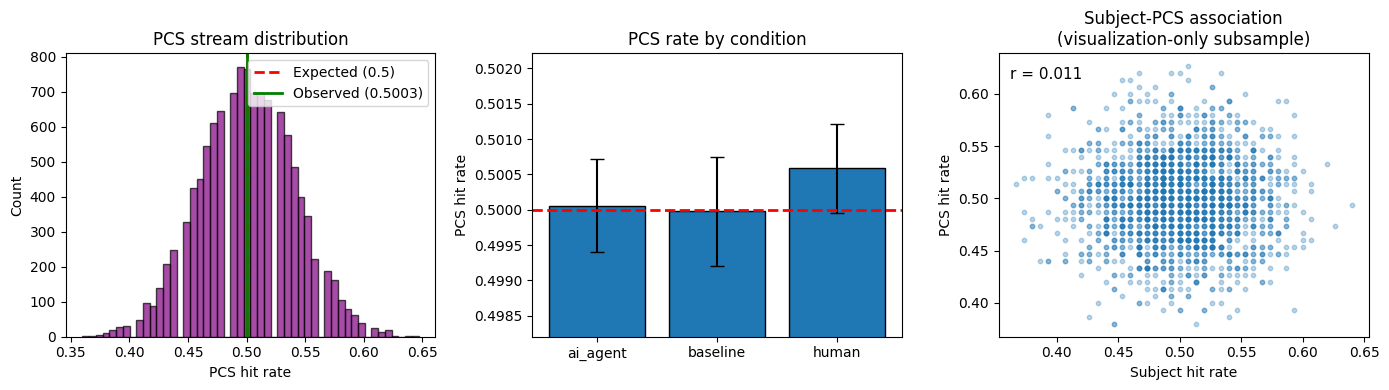


PCS STREAM CALIBRATION SUMMARY
PCS mean=0.500253; session-bootstrap 95% CI=[0.499504, 0.501022]
Session-level condition ANOVA p=0.7769
Subject-PCS Pearson r=+0.0113; session-bootstrap 95% CI=[-0.0077, +0.0305]

Interpretation:
At alpha=.05, these analyses detected neither a departure of the PCS hit rate
from 0.50 nor a PCS mean difference across sampled conditions.
The observed Subject-PCS association is
reported separately. These null results do not prove exact unbiasedness,
condition invariance, independence, or the absence of small effects.

The session-aware analyses address dependence among blocks within a session.
They do not by themselves provide population-level participant inference.



In [5]:
# PCS STREAM CALIBRATION
# Purpose: estimate PCS calibration and test for detectable departures while
# preserving the distinction between block-level estimates and session-aware inference.

import matplotlib.pyplot as plt
from scipy import stats

print("=" * 72)
print("PCS STREAM CALIBRATION")
print("=" * 72)
print("\nGoal: estimate the PCS hit rate and test for detectable departure")
print("      from 0.50 and detectable differences across conditions.")

# -----------------------------------------------------------------------------
# TEST 1: PCS mean relative to 0.50
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 1: PCS hit rate relative to 0.50")
print("-" * 72)

pcs_mean = df["pcs_hit_rate"].mean()
block_t, block_p = stats.ttest_1samp(df["pcs_hit_rate"], 0.5)

pcs_centered = df[["session_id", "pcs_hit_rate"]].copy()
pcs_centered["pcs_minus_half"] = pcs_centered["pcs_hit_rate"] - 0.5
pcs_cluster_ci = cluster_bootstrap_mean(
    pcs_centered,
    "pcs_hit_rate",
    cluster_col="session_id",
    n_boot=5000,
    seed=20260804,
)
pcs_cluster_test = clustered_paired_signflip(
    pcs_centered,
    "pcs_minus_half",
    cluster_col="session_id",
    n_perm=10000,
    seed=20260804,
)

print(f"PCS hit rate (all blocks): {pcs_mean:.6f}")
print(
    "Whole-session bootstrap 95% CI: "
    f"[{pcs_cluster_ci['ci_low']:.6f}, {pcs_cluster_ci['ci_high']:.6f}] "
    f"({pcs_cluster_ci['n_clusters']} sessions)"
)
print(f"Block-level one-sample t-test (descriptive): t={block_t:.3f}, p={block_p:.4f}")
print(
    "Whole-session sign-flip test: "
    f"p={pcs_cluster_test['p_value']:.4f}"
)
if pcs_cluster_test["p_value"] > 0.05:
    print("At alpha=.05, no departure from 0.50 was detected.")
else:
    print("At alpha=.05, a departure from 0.50 was detected.")

# -----------------------------------------------------------------------------
# TEST 2: PCS hit rate across sampled conditions
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 2: PCS hit rate across sampled conditions")
print("-" * 72)

condition_order = sorted(df["condition"].dropna().unique())
session_pcs = (
    df.groupby(["session_id", "condition"], as_index=False)
    .agg(
        pcs_hit_rate=("pcs_hit_rate", "mean"),
        subject_hit_rate=("subject_hit_rate", "mean"),
        n_blocks=("pcs_hit_rate", "size"),
    )
)

print("\nBlock-weighted PCS hit rate by condition:")
for condition in condition_order:
    subset = df.loc[df["condition"].eq(condition), "pcs_hit_rate"]
    n_sessions = session_pcs.loc[session_pcs["condition"].eq(condition), "session_id"].nunique()
    print(
        f"  {condition:12s}: {subset.mean():.6f} "
        f"({len(subset):,} blocks; {n_sessions} sessions)"
    )

block_groups = [
    df.loc[df["condition"].eq(condition), "pcs_hit_rate"].to_numpy()
    for condition in condition_order
]
block_f, block_anova_p = stats.f_oneway(*block_groups)

session_groups = [
    session_pcs.loc[session_pcs["condition"].eq(condition), "pcs_hit_rate"].to_numpy()
    for condition in condition_order
]
session_f, session_anova_p = stats.f_oneway(*session_groups)

print(f"\nBlock-level one-way ANOVA (descriptive): F={block_f:.3f}, p={block_anova_p:.4f}")
print(f"Session-level one-way ANOVA: F={session_f:.3f}, p={session_anova_p:.4f}")
if session_anova_p > 0.05:
    print("At alpha=.05, no PCS mean difference across sampled conditions was detected.")
else:
    print("At alpha=.05, a PCS mean difference across sampled conditions was detected.")

print("\nPCS calibration table")
print(f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} {'Block mean':>12} {'Block SD':>10}")
print("-" * 58)
for condition in condition_order:
    block_subset = df.loc[df["condition"].eq(condition), "pcs_hit_rate"]
    session_subset = session_pcs.loc[session_pcs["condition"].eq(condition)]
    print(
        f"{condition:<12} {len(block_subset):>8} {len(session_subset):>9} "
        f"{block_subset.mean():>12.6f} {block_subset.std():>10.6f}"
    )
print("-" * 58)
print(
    f"{'TOTAL':<12} {len(df):>8} {df['session_id'].nunique():>9} "
    f"{df['pcs_hit_rate'].mean():>12.6f} {df['pcs_hit_rate'].std():>10.6f}"
)

# -----------------------------------------------------------------------------
# TEST 3: paired Subject-minus-PCS mean-rate comparison
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 3: Subject vs PCS mean-rate comparison")
print("-" * 72)

subject_mean = df["subject_hit_rate"].mean()
paired_t, paired_p = stats.ttest_rel(df["subject_hit_rate"], df["pcs_hit_rate"])
delta_cluster_ci = cluster_bootstrap_mean(
    df,
    "delta_hit",
    cluster_col="session_id",
    n_boot=5000,
    seed=20260805,
)
delta_cluster_test = clustered_paired_signflip(
    df,
    "delta_hit",
    cluster_col="session_id",
    n_perm=10000,
    seed=20260805,
)

print(f"Subject mean: {subject_mean:.6f}")
print(f"PCS mean:     {pcs_mean:.6f}")
print(f"Paired mean difference (Subject - PCS): {df['delta_hit'].mean():+.6f}")
print(f"Block-level paired t-test (descriptive): t={paired_t:.3f}, p={paired_p:.4f}")
print(
    "Whole-session bootstrap 95% CI for paired mean: "
    f"[{delta_cluster_ci['ci_low']:+.6f}, {delta_cluster_ci['ci_high']:+.6f}]"
)
print(f"Whole-session paired sign-flip test: p={delta_cluster_test['p_value']:.4f}")

# -----------------------------------------------------------------------------
# TEST 4: observed Subject-PCS association
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 4: Observed Subject-PCS block-level association")
print("-" * 72)

corr_r, corr_p = stats.pearsonr(df["subject_hit_rate"], df["pcs_hit_rate"])
rng_corr = np.random.default_rng(20260806)
session_groups_for_corr = {
    key: group[["subject_hit_rate", "pcs_hit_rate"]].to_numpy()
    for key, group in df.groupby("session_id")
}
session_keys_for_corr = np.array(list(session_groups_for_corr))
corr_draws = np.empty(5000)
for draw_idx in range(len(corr_draws)):
    sampled_keys = rng_corr.choice(
        session_keys_for_corr,
        size=len(session_keys_for_corr),
        replace=True,
    )
    sampled_rows = np.concatenate(
        [session_groups_for_corr[key] for key in sampled_keys],
        axis=0,
    )
    corr_draws[draw_idx] = np.corrcoef(sampled_rows[:, 0], sampled_rows[:, 1])[0, 1]
corr_ci_low, corr_ci_high = np.quantile(corr_draws, [0.025, 0.975])

print(f"Pearson correlation: r={corr_r:.4f}, block-level p={corr_p:.4f}")
print(
    "Whole-session bootstrap 95% CI for r: "
    f"[{corr_ci_low:+.4f}, {corr_ci_high:+.4f}]"
)
print("This association analysis is distinct from the paired mean-rate comparison.")

# -----------------------------------------------------------------------------
# Visualization (the scatter subsample is for display only)
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("Generating calibration plots (all calculations above use the full dataset)")
print("-" * 72)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
ax1.hist(df["pcs_hit_rate"], bins=50, alpha=0.7, color="purple", edgecolor="black")
ax1.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Expected (0.5)")
ax1.axvline(pcs_mean, color="green", linewidth=2, label=f"Observed ({pcs_mean:.4f})")
ax1.set_xlabel("PCS hit rate")
ax1.set_ylabel("Count")
ax1.set_title("PCS stream distribution")
ax1.legend()

ax2 = axes[1]
condition_means = [
    df.loc[df["condition"].eq(condition), "pcs_hit_rate"].mean()
    for condition in condition_order
]
condition_session_sems = [
    session_pcs.loc[session_pcs["condition"].eq(condition), "pcs_hit_rate"].sem()
    for condition in condition_order
]
ax2.bar(
    condition_order,
    condition_means,
    yerr=condition_session_sems,
    capsize=5,
    edgecolor="black",
)
ax2.axhline(0.5, color="red", linestyle="--", linewidth=2)
ax2.set_ylabel("PCS hit rate")
ax2.set_title("PCS rate by condition")
plot_values = np.array(condition_means)
plot_errors = np.array(condition_session_sems)
plot_low = min(0.5, np.min(plot_values - plot_errors))
plot_high = max(0.5, np.max(plot_values + plot_errors))
plot_margin = max(0.001, 0.25 * (plot_high - plot_low))
ax2.set_ylim(plot_low - plot_margin, plot_high + plot_margin)

ax3 = axes[2]
scatter_sample = df.sample(min(2000, len(df)), random_state=42)
ax3.scatter(
    scatter_sample["subject_hit_rate"],
    scatter_sample["pcs_hit_rate"],
    alpha=0.3,
    s=10,
)
ax3.set_xlabel("Subject hit rate")
ax3.set_ylabel("PCS hit rate")
ax3.set_title("Subject-PCS association\n(visualization-only subsample)")
ax3.text(
    0.03,
    0.95,
    f"r = {corr_r:.3f}",
    transform=ax3.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("PCS STREAM CALIBRATION SUMMARY")
print("=" * 72)
print(
    f"PCS mean={pcs_mean:.6f}; session-bootstrap 95% CI="
    f"[{pcs_cluster_ci['ci_low']:.6f}, {pcs_cluster_ci['ci_high']:.6f}]"
)
print(f"Session-level condition ANOVA p={session_anova_p:.4f}")
print(
    f"Subject-PCS Pearson r={corr_r:+.4f}; session-bootstrap 95% CI="
    f"[{corr_ci_low:+.4f}, {corr_ci_high:+.4f}]"
)
print("""
Interpretation:
At alpha=.05, these analyses detected neither a departure of the PCS hit rate
from 0.50 nor a PCS mean difference across sampled conditions.
The observed Subject-PCS association is
reported separately. These null results do not prove exact unbiasedness,
condition invariance, independence, or the absence of small effects.

The session-aware analyses address dependence among blocks within a session.
They do not by themselves provide population-level participant inference.
""")


### PCS Distribution Shape

**Paper section: 3.1 (bounded PCS calibration)**

Provides descriptive comparisons of the marginal PCS hit-rate distributions across the
sampled Baseline, Human, and AI conditions and a session-level comparison of mean PCS
single-scale R/S ordering scores. The formal hit-rate condition test is reported in the
preceding **PCS Stream Calibration** section; this section does not duplicate it with an
omnibus distribution test because the paper does not claim complete distributional
equivalence.

The plots describe the realized data. The session-level single-scale R/S-score comparison is a
difference-detection analysis: a null result means that no condition difference was
detected at this analysis's resolution, not that the conditions are equivalent or that
the PCS is unaffected by condition.


PCS DISTRIBUTION SHAPE

Scope: describe PCS hit-rate distributions and test whether mean PCS
       single-scale R/S ordering score differs across sampled conditions.

------------------------------------------------------------------------
DESCRIPTIVE PCS HIT-RATE DISTRIBUTIONS
------------------------------------------------------------------------
Condition      Blocks  Sessions       Mean         SD       Skew   Kurtosis
--------------------------------------------------------------------------
AI Agent         3780       126   0.500060   0.040841    -0.0221    -0.0065
Baseline         3090       103   0.499978   0.041311     0.0163    -0.1050
Human            4737       158   0.500585   0.040189    -0.0130    -0.0723

No omnibus hit-rate distribution test is reported here. The paper does not claim complete distributional equivalence, and the preceding calibration section reports the prespecified session-level condition comparison of mean PCS hit rate.

----------------------------

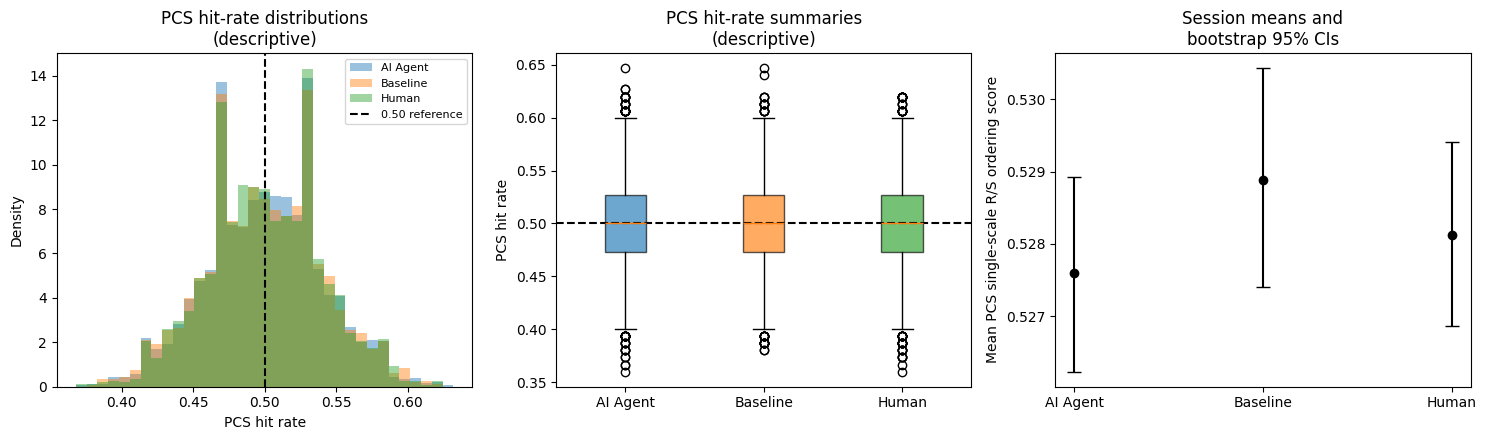


PCS DISTRIBUTION SHAPE SUMMARY
Session-level PCS R/S-score condition comparison: F=0.7574, p=0.4696

Interpretation:
The observed marginal PCS hit-rate distributions were visually similar across
the sampled conditions. In these data, the specified session-level comparison
detected no condition difference in mean PCS single-scale R/S ordering score at its available
resolution. This is a difference-detection analysis, not
an equivalence test.

This section does not establish exact distributional equality, equal variance,
causal invariance, or PCS randomness. It does not validate the full paired
design, establish Subject-PCS independence, rule out shared or time-varying
artifacts, or attribute an observed Subject-PCS difference to the Subject.
Those questions require the separate temporal, relational, paired-delta, and
collection-structure analyses.



In [6]:
# PCS DISTRIBUTION SHAPE
# Purpose: descriptive marginal PCS distributions plus a session-aware
# difference-detection analysis for mean PCS single-scale R/S ordering score by condition.

import matplotlib.pyplot as plt
from scipy import stats

print("=" * 72)
print("PCS DISTRIBUTION SHAPE")
print("=" * 72)
print("\nScope: describe PCS hit-rate distributions and test whether mean PCS")
print("       single-scale R/S ordering score differs across sampled conditions.")

condition_order = sorted(df["condition"].dropna().unique())
condition_labels = {
    "baseline": "Baseline",
    "human": "Human",
    "ai_agent": "AI Agent",
}

# -----------------------------------------------------------------------------
# DESCRIPTIVE PCS HIT-RATE DISTRIBUTIONS
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("DESCRIPTIVE PCS HIT-RATE DISTRIBUTIONS")
print("-" * 72)
print(
    f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} "
    f"{'Mean':>10} {'SD':>10} {'Skew':>10} {'Kurtosis':>10}"
)
print("-" * 74)

hit_groups = {}
for condition in condition_order:
    subset = df.loc[df["condition"].eq(condition)]
    values = subset["pcs_hit_rate"].dropna().to_numpy()
    hit_groups[condition] = values
    print(
        f"{condition_labels.get(condition, condition):<12} "
        f"{len(values):>8} {subset['session_id'].nunique():>9} "
        f"{values.mean():>10.6f} {values.std(ddof=1):>10.6f} "
        f"{stats.skew(values, bias=False):>10.4f} "
        f"{stats.kurtosis(values, bias=False):>10.4f}"
    )

print(
    "\nNo omnibus hit-rate distribution test is reported here. The paper does "
    "not claim complete distributional equivalence, and the preceding calibration "
    "section reports the prespecified session-level condition comparison of mean "
    "PCS hit rate."
)

# -----------------------------------------------------------------------------
# SESSION-LEVEL PCS HURST CONDITION COMPARISON
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("SESSION-LEVEL PCS SINGLE-SCALE R/S ORDERING SCORE BY CONDITION")
print("-" * 72)

pcs_hurst_session = (
    df_hurst.groupby(["session_id", "condition"], as_index=False)
    .agg(
        pcs_hurst=("hurst_pcs", "mean"),
        n_blocks=("hurst_pcs", "size"),
    )
)

hurst_results = []
for idx, condition in enumerate(condition_order):
    block_values = df_hurst.loc[
        df_hurst["condition"].eq(condition), "hurst_pcs"
    ].dropna()
    session_values = pcs_hurst_session.loc[
        pcs_hurst_session["condition"].eq(condition), "pcs_hurst"
    ].dropna()
    rng = np.random.default_rng(20260820 + idx)
    boot_means = np.empty(5000)
    values = session_values.to_numpy()
    for draw_idx in range(len(boot_means)):
        boot_means[draw_idx] = rng.choice(values, size=len(values), replace=True).mean()
    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    hurst_results.append(
        {
            "condition": condition,
            "block_mean": block_values.mean(),
            "block_sd": block_values.std(ddof=1),
            "n_blocks": len(block_values),
            "session_mean": session_values.mean(),
            "session_ci_low": ci_low,
            "session_ci_high": ci_high,
            "n_sessions": len(session_values),
        }
    )

hurst_results = pd.DataFrame(hurst_results)
print(
    f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} {'Block mean':>12} "
    f"{'Block SD':>10} {'Session mean':>13} {'Session-bootstrap 95% CI':>28}"
)
print("-" * 98)
for row in hurst_results.itertuples(index=False):
    print(
        f"{condition_labels.get(row.condition, row.condition):<12} "
        f"{row.n_blocks:>8} {row.n_sessions:>9} {row.block_mean:>12.6f} "
        f"{row.block_sd:>10.6f} {row.session_mean:>13.6f} "
        f"[{row.session_ci_low:.6f}, {row.session_ci_high:.6f}]"
    )

hurst_session_groups = [
    pcs_hurst_session.loc[
        pcs_hurst_session["condition"].eq(condition), "pcs_hurst"
    ].dropna().to_numpy()
    for condition in condition_order
]
hurst_f, hurst_p = stats.f_oneway(*hurst_session_groups)
print(
    f"\nSession-level one-way ANOVA for mean PCS single-scale R/S ordering score: "
    f"F={hurst_f:.4f}, p={hurst_p:.4f}"
)
if hurst_p <= 0.05:
    print("A condition difference was detected by this session-level comparison.")
else:
    print("No condition difference was detected by this session-level comparison.")

# -----------------------------------------------------------------------------
# DESCRIPTIVE FIGURE
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("Generating descriptive PCS plots")
print("-" * 72)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

all_hit = np.concatenate(list(hit_groups.values()))
hit_low, hit_high = np.quantile(all_hit, [0.001, 0.999])
hit_margin = max(1 / 150, 0.05 * (hit_high - hit_low))
bins = np.linspace(hit_low - hit_margin, hit_high + hit_margin, 36)

ax1 = axes[0]
for idx, condition in enumerate(condition_order):
    ax1.hist(
        hit_groups[condition],
        bins=bins,
        alpha=0.45,
        density=True,
        color=colors[idx % len(colors)],
        label=condition_labels.get(condition, condition),
    )
ax1.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="0.50 reference")
ax1.set_xlabel("PCS hit rate")
ax1.set_ylabel("Density")
ax1.set_title("PCS hit-rate distributions\n(descriptive)")
ax1.legend(fontsize=8)

ax2 = axes[1]
box = ax2.boxplot(
    [hit_groups[condition] for condition in condition_order],
    tick_labels=[condition_labels.get(condition, condition) for condition in condition_order],
    patch_artist=True,
)
for idx, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[idx % len(colors)])
    patch.set_alpha(0.65)
ax2.axhline(0.5, color="black", linestyle="--", linewidth=1.5)
ax2.set_ylabel("PCS hit rate")
ax2.set_title("PCS hit-rate summaries\n(descriptive)")

ax3 = axes[2]
x = np.arange(len(hurst_results))
means = hurst_results["session_mean"].to_numpy()
yerr = np.vstack([
    means - hurst_results["session_ci_low"].to_numpy(),
    hurst_results["session_ci_high"].to_numpy() - means,
])
ax3.errorbar(x, means, yerr=yerr, fmt="o", capsize=5, color="black")
ax3.set_xticks(x)
ax3.set_xticklabels([
    condition_labels.get(condition, condition)
    for condition in hurst_results["condition"]
])
ax3.set_ylabel("Mean PCS single-scale R/S ordering score")
ax3.set_title("Session means and\nbootstrap 95% CIs")

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("PCS DISTRIBUTION SHAPE SUMMARY")
print("=" * 72)
print(f"Session-level PCS R/S-score condition comparison: F={hurst_f:.4f}, p={hurst_p:.4f}")
print("""
Interpretation:
The observed marginal PCS hit-rate distributions were visually similar across
the sampled conditions. In these data, the specified session-level comparison
detected no condition difference in mean PCS single-scale R/S ordering score at its available
resolution. This is a difference-detection analysis, not
an equivalence test.

This section does not establish exact distributional equality, equal variance,
causal invariance, or PCS randomness. It does not validate the full paired
design, establish Subject-PCS independence, rule out shared or time-varying
artifacts, or attribute an observed Subject-PCS difference to the Subject.
Those questions require the separate temporal, relational, paired-delta, and
collection-structure analyses.
""")


### PCS Temporal Integrity

**Paper section: 3.1**

This section examines three narrowly defined temporal features of the PCS: (1) lag-1 association of block hit rates across blocks within sessions, (2) runs structure within each 150-bit block, and (3) linear change in PCS hit rate over block position within a session. The single-scale R/S values are shown descriptively only; their condition comparison is reported in the preceding section.

These diagnostics do not test every lag, periodic or nonlinear pattern, long-term chronological drift, provider/batch effects, or global randomness.


PCS Temporal Integrity
Scope: across-block lag-1 association, within-block runs structure,
       and within-session linear drift in PCS hit rate.

Eligible sessions: 387
Session-length distribution: 27 blocks: 1 sessions, 30 blocks: 386 sessions
Permutation draws: 10,000; equal weight per session

------------------------------------------------------------------------
TEST 1: Across-block, within-session lag-1 association of PCS hit rates
------------------------------------------------------------------------
Observed mean session lag-1 r: -0.041393
Permutation-null mean:         -0.034386
95% permutation-null interval: [-0.052414, -0.016610]
Observed minus null mean:      -0.007007
Two-sided Monte Carlo p:       0.4434

------------------------------------------------------------------------
TEST 2: Within-block runs structure of PCS bits
------------------------------------------------------------------------
Eligible blocks: 11,607; excluded/invalid: 0
Calibration: exact Wald-Wol

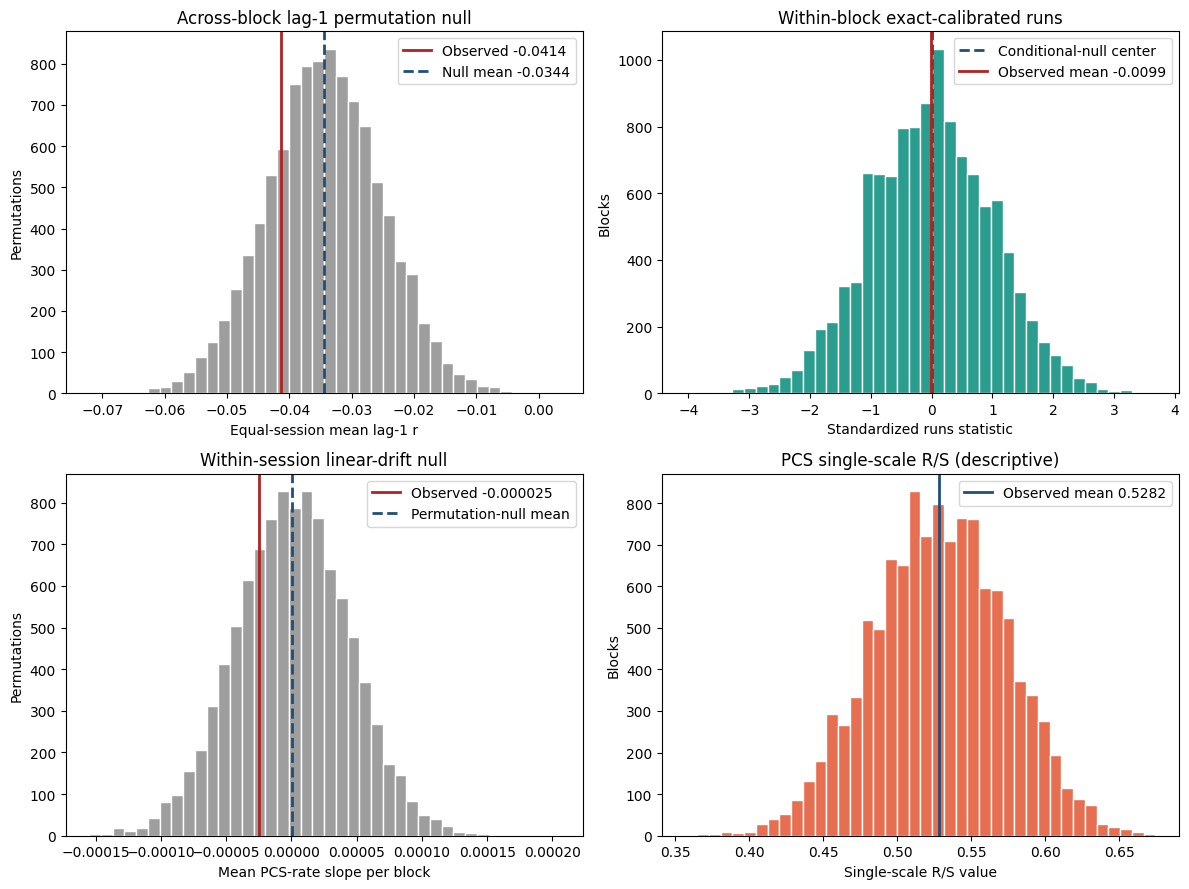


SUMMARY: Bounded temporal diagnostics
Across-block lag-1: observed -0.041393, permutation p=0.4434
Within-block runs mean: -0.009871, session-aware p=0.2677
Within-block runs tails: observed 556 vs 549.2 expected, p=0.7582
Within-session linear drift: -0.00002470 per block, permutation p=0.5576

Interpretation: No departure was detected by the specified across-block
lag-1, within-block runs, or within-session linear-drift diagnostics at
their available resolution. These results do not establish global
randomness or rule out other lags, nonlinear/periodic patterns, long-term
drift, or unmeasured provider and batch effects.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# PCS Temporal Integrity
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test specified across-block and within-block temporal features of
#          the PCS using design-matched nulls and session-aware uncertainty.
# ═══════════════════════════════════════════════════════════════════════════

import math
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 72)
print("PCS Temporal Integrity")
print("=" * 72)
print("Scope: across-block lag-1 association, within-block runs structure,")
print("       and within-session linear drift in PCS hit rate.")

N_PERM_TEMPORAL = 10_000
N_RESAMPLE_TEMPORAL = 10_000
TEMPORAL_SEED = 20260804
rng_temporal = np.random.default_rng(TEMPORAL_SEED)


def plus_one_two_sided(null_values, observed, center=None):
    null_values = np.asarray(null_values, dtype=float)
    if center is None:
        center = float(np.mean(null_values))
    extreme = np.sum(np.abs(null_values - center) >= abs(observed - center))
    return (int(extreme) + 1) / (len(null_values) + 1)


def session_bootstrap_ci(values, rng, n_resamples=N_RESAMPLE_TEMPORAL):
    values = np.asarray(values, dtype=float)
    draws = rng.choice(values, size=(n_resamples, len(values)), replace=True).mean(axis=1)
    return np.quantile(draws, [0.025, 0.975])


def sign_flip_p(values, rng, n_perm=N_PERM_TEMPORAL):
    values = np.asarray(values, dtype=float)
    observed = float(values.mean())
    null = np.empty(n_perm, dtype=float)
    chunk = 1_000
    for start in range(0, n_perm, chunk):
        stop = min(start + chunk, n_perm)
        signs = rng.choice((-1.0, 1.0), size=(stop - start, len(values)))
        null[start:stop] = (signs * values).mean(axis=1)
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (n_perm + 1)
    return observed, null, p_value


# Preserve observed block order inside every eligible session.
temporal_sessions = []
for session_id, session_data in df.groupby("session_id", sort=False):
    ordered = session_data.sort_values("block_idx")
    rates = ordered["rate_pcs"].to_numpy(dtype=float)
    rates = rates[np.isfinite(rates)]
    if len(rates) >= 5 and np.std(rates) > 0:
        temporal_sessions.append((session_id, rates))

session_lengths = np.array([len(rates) for _, rates in temporal_sessions], dtype=int)
length_counts = pd.Series(session_lengths).value_counts().sort_index()
print(f"\nEligible sessions: {len(temporal_sessions)}")
print("Session-length distribution: " + ", ".join(
    f"{length} blocks: {count} sessions" for length, count in length_counts.items()
))
print(f"Permutation draws: {N_PERM_TEMPORAL:,}; equal weight per session")


# TEST 1: Across-block lag-1 association and TEST 3: linear drift.
# The same independently permuted orderings supply both design-matched nulls.
observed_ac = []
observed_slopes = []
null_ac_sum = np.zeros(N_PERM_TEMPORAL, dtype=float)
null_slope_sum = np.zeros(N_PERM_TEMPORAL, dtype=float)

for _, rates in temporal_sessions:
    n = len(rates)
    x = np.arange(n, dtype=float)
    x_centered = x - x.mean()
    x_ss = np.sum(x_centered ** 2)

    observed_ac.append(np.corrcoef(rates[:-1], rates[1:])[0, 1])
    observed_slopes.append(np.dot(x_centered, rates) / x_ss)

    # Generator.permuted independently permutes each row along axis 1.
    permuted = rng_temporal.permuted(
        np.broadcast_to(rates, (N_PERM_TEMPORAL, n)), axis=1
    )
    left = permuted[:, :-1]
    right = permuted[:, 1:]
    left_centered = left - left.mean(axis=1, keepdims=True)
    right_centered = right - right.mean(axis=1, keepdims=True)
    denom = np.sqrt(
        np.sum(left_centered ** 2, axis=1) * np.sum(right_centered ** 2, axis=1)
    )
    null_ac_sum += np.divide(
        np.sum(left_centered * right_centered, axis=1),
        denom,
        out=np.zeros_like(denom),
        where=denom > 0,
    )
    null_slope_sum += permuted @ x_centered / x_ss

observed_ac = np.asarray(observed_ac)
observed_slopes = np.asarray(observed_slopes)
mean_ac = float(observed_ac.mean())
null_ac = null_ac_sum / len(temporal_sessions)
null_ac_mean = float(null_ac.mean())
null_ac_ci = np.quantile(null_ac, [0.025, 0.975])
ac_difference = mean_ac - null_ac_mean
p_ac = plus_one_two_sided(null_ac, mean_ac, center=null_ac_mean)

mean_slope = float(observed_slopes.mean())
null_slope = null_slope_sum / len(temporal_sessions)
null_slope_mean = float(null_slope.mean())
null_slope_ci = np.quantile(null_slope, [0.025, 0.975])
p_slope = plus_one_two_sided(null_slope, mean_slope, center=null_slope_mean)
change_30 = mean_slope * 29

print("\n" + "-" * 72)
print("TEST 1: Across-block, within-session lag-1 association of PCS hit rates")
print("-" * 72)
print(f"Observed mean session lag-1 r: {mean_ac:+.6f}")
print(f"Permutation-null mean:         {null_ac_mean:+.6f}")
print(f"95% permutation-null interval: [{null_ac_ci[0]:+.6f}, {null_ac_ci[1]:+.6f}]")
print(f"Observed minus null mean:      {ac_difference:+.6f}")
print(f"Two-sided Monte Carlo p:       {p_ac:.4f}")


# TEST 2: exact conditional Wald-Wolfowitz runs calibration.
def count_runs(bits):
    array = np.asarray(bits, dtype=np.int8)
    return 1 + int(np.sum(array[1:] != array[:-1])) if len(array) else 0


def runs_mean_sd(n0, n1):
    n = n0 + n1
    mean = 1 + (2 * n0 * n1) / n
    variance = (2 * n0 * n1 * (2 * n0 * n1 - n)) / (n * n * (n - 1))
    return mean, math.sqrt(variance)


@lru_cache(maxsize=None)
def exact_runs_distribution(n0, n1):
    total = math.comb(n0 + n1, n1)
    support = []
    weights = []
    for runs in range(2, 2 * min(n0, n1) + 2):
        if runs % 2 == 0:
            k = runs // 2
            count = 2 * math.comb(n0 - 1, k - 1) * math.comb(n1 - 1, k - 1)
        else:
            k = (runs - 1) // 2
            count = 0
            if k <= n0 - 1 and k - 1 <= n1 - 1:
                count += math.comb(n0 - 1, k) * math.comb(n1 - 1, k - 1)
            if k <= n1 - 1 and k - 1 <= n0 - 1:
                count += math.comb(n1 - 1, k) * math.comb(n0 - 1, k - 1)
        if count:
            support.append(runs)
            weights.append(count / total)
    support = np.asarray(support, dtype=int)
    probabilities = np.asarray(weights, dtype=float)
    mean, sd = runs_mean_sd(n0, n1)
    z_support = (support - mean) / sd
    exact_p = np.array([
        probabilities[np.abs(z_support) >= abs(z) - 1e-12].sum()
        for z in z_support
    ])
    return support, probabilities, z_support, exact_p


runs_rows = []
invalid_runs = 0
for _, row in df.iterrows():
    bits = row["demon_bits"]
    if not isinstance(bits, (list, tuple, np.ndarray)) or len(bits) != 150:
        invalid_runs += 1
        continue
    bits_array = np.asarray(bits, dtype=np.int8)
    n1 = int(bits_array.sum())
    n0 = len(bits_array) - n1
    if n0 == 0 or n1 == 0:
        invalid_runs += 1
        continue
    observed_runs = count_runs(bits_array)
    support, probabilities, z_support, exact_p = exact_runs_distribution(n0, n1)
    position = int(np.where(support == observed_runs)[0][0])
    # Exact two-sided p-values are discrete; this is the conditional null
    # probability of landing in the p <= .05 rejection set.
    expected_extreme_probability = float(probabilities[exact_p <= 0.05].sum())
    runs_rows.append({
        "session_id": row["session_id"],
        "z": float(z_support[position]),
        "exact_p": float(exact_p[position]),
        "extreme": float(exact_p[position] <= 0.05),
        "expected_extreme_probability": expected_extreme_probability,
    })

runs_df = pd.DataFrame(runs_rows)
session_runs = runs_df.groupby("session_id", sort=False).agg(
    mean_z=("z", "mean"),
    observed_extreme_rate=("extreme", "mean"),
    expected_extreme_rate=("expected_extreme_probability", "mean"),
)
session_runs["extreme_rate_difference"] = (
    session_runs["observed_extreme_rate"] - session_runs["expected_extreme_rate"]
)

mean_runs_z, runs_z_null, p_runs_mean = sign_flip_p(
    session_runs["mean_z"].to_numpy(), rng_temporal
)
runs_z_ci = session_bootstrap_ci(
    session_runs["mean_z"].to_numpy(), rng_temporal
)
tail_difference, tail_null, p_runs_tail = sign_flip_p(
    session_runs["extreme_rate_difference"].to_numpy(), rng_temporal
)
tail_difference_ci = session_bootstrap_ci(
    session_runs["extreme_rate_difference"].to_numpy(), rng_temporal
)
observed_extremes = int(runs_df["extreme"].sum())
expected_extremes = float(runs_df["expected_extreme_probability"].sum())

print("\n" + "-" * 72)
print("TEST 2: Within-block runs structure of PCS bits")
print("-" * 72)
print(f"Eligible blocks: {len(runs_df):,}; excluded/invalid: {invalid_runs:,}")
print("Calibration: exact Wald-Wolfowitz distribution conditional on each")
print("             block's observed numbers of zeros and ones")
print(f"Mean standardized runs statistic: {mean_runs_z:+.6f}")
print(f"Session-bootstrap 95% CI:         [{runs_z_ci[0]:+.6f}, {runs_z_ci[1]:+.6f}]")
print(f"Session sign-flip p (mean):       {p_runs_mean:.4f}")
print(f"Exact p <= .05 blocks:            {observed_extremes:,} observed")
print(f"Conditional-null expectation:     {expected_extremes:.1f}")
print(f"Observed-minus-expected rate:     {tail_difference:+.6f}")
print(f"Session-bootstrap 95% CI:         [{tail_difference_ci[0]:+.6f}, {tail_difference_ci[1]:+.6f}]")
print(f"Session sign-flip p (tails):      {p_runs_tail:.4f}")


print("\n" + "-" * 72)
print("TEST 3: Within-session linear drift in PCS hit rate")
print("-" * 72)
print(f"Observed mean slope per block:    {mean_slope:+.8f}")
print(f"Permutation-null mean:            {null_slope_mean:+.8f}")
print(f"95% permutation-null interval:    [{null_slope_ci[0]:+.8f}, {null_slope_ci[1]:+.8f}]")
print(f"Estimated change over 30 blocks:  {change_30:+.6f}")
print(f"Two-sided Monte Carlo p:          {p_slope:.4f}")


# The R/S output is descriptive here. Its finite-sample expectation at n=150
# is not 0.5, so no one-sample test against 0.5 is performed.
pcs_hurst_temporal = df_hurst["hurst_pcs"].dropna().to_numpy(dtype=float)
mean_hurst_temporal = float(np.mean(pcs_hurst_temporal))
print("\n" + "-" * 72)
print("DESCRIPTIVE: Within-block single-scale R/S statistic for PCS bits")
print("-" * 72)
print(f"Mean single-scale R/S value: {mean_hurst_temporal:.6f}")
print("No test against 0.5 is performed: this estimator has a positive")
print("finite-sample offset at n=150. The preceding section reports the")
print("session-aware condition comparison.")
print("At equal length, Subject and PCS use the same estimator, but its offset")
print("cancels in a paired difference only to the extent that estimator bias is")
print("matched for the two underlying processes.")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.hist(null_ac, bins=40, color="#9e9e9e", edgecolor="white")
ax.axvline(mean_ac, color="#b22222", linewidth=2, label=f"Observed {mean_ac:+.4f}")
ax.axvline(null_ac_mean, color="#1f4e79", linestyle="--", linewidth=2,
           label=f"Null mean {null_ac_mean:+.4f}")
ax.set(title="Across-block lag-1 permutation null", xlabel="Equal-session mean lag-1 r", ylabel="Permutations")
ax.legend()

ax = axes[0, 1]
ax.hist(runs_df["z"], bins=40, color="#2a9d8f", edgecolor="white")
ax.axvline(0, color="#1f4e79", linestyle="--", linewidth=2, label="Conditional-null center")
ax.axvline(mean_runs_z, color="#b22222", linewidth=2, label=f"Observed mean {mean_runs_z:+.4f}")
ax.set(title="Within-block exact-calibrated runs", xlabel="Standardized runs statistic", ylabel="Blocks")
ax.legend()

ax = axes[1, 0]
ax.hist(null_slope, bins=40, color="#9e9e9e", edgecolor="white")
ax.axvline(mean_slope, color="#b22222", linewidth=2, label=f"Observed {mean_slope:+.6f}")
ax.axvline(null_slope_mean, color="#1f4e79", linestyle="--", linewidth=2, label="Permutation-null mean")
ax.set(title="Within-session linear-drift null", xlabel="Mean PCS-rate slope per block", ylabel="Permutations")
ax.legend()

ax = axes[1, 1]
ax.hist(pcs_hurst_temporal, bins=40, color="#e76f51", edgecolor="white")
ax.axvline(mean_hurst_temporal, color="#1f4e79", linewidth=2,
           label=f"Observed mean {mean_hurst_temporal:.4f}")
ax.set(title="PCS single-scale R/S (descriptive)", xlabel="Single-scale R/S value", ylabel="Blocks")
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("SUMMARY: Bounded temporal diagnostics")
print("=" * 72)
print(f"Across-block lag-1: observed {mean_ac:+.6f}, permutation p={p_ac:.4f}")
print(f"Within-block runs mean: {mean_runs_z:+.6f}, session-aware p={p_runs_mean:.4f}")
print(f"Within-block runs tails: observed {observed_extremes:,} vs {expected_extremes:.1f} expected, p={p_runs_tail:.4f}")
print(f"Within-session linear drift: {mean_slope:+.8f} per block, permutation p={p_slope:.4f}")
print("\nInterpretation: No departure was detected by the specified across-block")
print("lag-1, within-block runs, or within-session linear-drift diagnostics at")
print("their available resolution. These results do not establish global")
print("randomness or rule out other lags, nonlinear/periodic patterns, long-term")
print("drift, or unmeasured provider and batch effects.")


### PCS Within-Block Structure Comparisons Across Conditions

This section extends the preceding PCS temporal checks to the condition comparisons reported in Paper §3.2.5. Each 150-bit PCS block contributes a derived within-block lag-1 correlation, normalized plug-in n-gram entropy at orders 1–4, and the linear slope of that four-point entropy profile. The slope is a descriptive finite-sample profile statistic—not a validated entropy-rate estimator.

Point estimates are block-weighted. Confidence intervals resample whole sessions within condition, and condition-label permutations move intact session bundles. Holm adjustment covers the 18 displayed pairwise comparisons. These diagnostics test only the specified summaries; nondetection does not establish equivalence, independence, provider invariance, or a generally “clean” PCS.


In [8]:
from collections import Counter

PCS_STRUCTURE_SEED = 20260805
PCS_STRUCTURE_N_PERM = 9_999
PCS_STRUCTURE_N_BOOT = 5_000
PCS_STRUCTURE_ORDERS = (1, 2, 3, 4)
PCS_STRUCTURE_PAIRS = (("human", "baseline"), ("ai_agent", "baseline"), ("human", "ai_agent"))

def nb1_holm(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running = 0.0
    m = len(values)
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * values[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted

def normalized_ngram_entropy(bits, order):
    array = np.asarray(bits, dtype=np.int8)
    words = [tuple(array[i:i + order]) for i in range(len(array) - order + 1)]
    counts = np.asarray(list(Counter(words).values()), dtype=float)
    probabilities = counts / counts.sum()
    return float(-np.sum(probabilities * np.log2(probabilities)) / order)

pcs_structure_rows = []
for row in df[["session_id", "condition", "demon_bits"]].itertuples(index=False):
    bits = np.asarray(row.demon_bits, dtype=np.int8)
    left, right = bits[:-1], bits[1:]
    lag1 = np.corrcoef(left, right)[0, 1] if left.std() > 0 and right.std() > 0 else np.nan
    entropies = [normalized_ngram_entropy(bits, order) for order in PCS_STRUCTURE_ORDERS]
    slope = np.polyfit(np.asarray(PCS_STRUCTURE_ORDERS, dtype=float), entropies, 1)[0]
    pcs_structure_rows.append({
        "session_id": row.session_id, "condition": row.condition,
        "pcs_within_block_lag1": lag1,
        **{f"pcs_ngram_h{order}_per_symbol": value for order, value in zip(PCS_STRUCTURE_ORDERS, entropies)},
        "pcs_normalized_entropy_profile_slope": slope,
    })

pcs_structure = pd.DataFrame(pcs_structure_rows)
pcs_structure_metrics = [
    "pcs_within_block_lag1",
    *[f"pcs_ngram_h{order}_per_symbol" for order in PCS_STRUCTURE_ORDERS],
    "pcs_normalized_entropy_profile_slope",
]

def session_bundle_contrast(frame, metric, condition_a, condition_b, seed):
    work = frame.loc[frame["condition"].isin([condition_a, condition_b]),
                     ["session_id", "condition", metric]].dropna()
    bundles = work.groupby(["session_id", "condition"])[metric].agg(["sum", "count"]).reset_index()
    sums = bundles["sum"].to_numpy(float)
    counts = bundles["count"].to_numpy(float)
    labels = bundles["condition"].to_numpy()
    mask_a = labels == condition_a
    observed = sums[mask_a].sum() / counts[mask_a].sum() - sums[~mask_a].sum() / counts[~mask_a].sum()
    rng = default_rng(seed)
    n_a = int(mask_a.sum())
    null = np.empty(PCS_STRUCTURE_N_PERM)
    for i in range(PCS_STRUCTURE_N_PERM):
        chosen = rng.choice(len(bundles), size=n_a, replace=False)
        perm_a = np.zeros(len(bundles), dtype=bool)
        perm_a[chosen] = True
        null[i] = sums[perm_a].sum() / counts[perm_a].sum() - sums[~perm_a].sum() / counts[~perm_a].sum()
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (PCS_STRUCTURE_N_PERM + 1)
    boot = np.empty(PCS_STRUCTURE_N_BOOT)
    a_idx, b_idx = np.flatnonzero(mask_a), np.flatnonzero(~mask_a)
    for i in range(PCS_STRUCTURE_N_BOOT):
        sa = rng.choice(a_idx, size=len(a_idx), replace=True)
        sb = rng.choice(b_idx, size=len(b_idx), replace=True)
        boot[i] = sums[sa].sum() / counts[sa].sum() - sums[sb].sum() / counts[sb].sum()
    lo, hi = np.quantile(boot, [0.025, 0.975])
    return observed, lo, hi, p_value, len(a_idx), len(b_idx)

pcs_structure_results_rows = []
for metric_index, metric in enumerate(pcs_structure_metrics):
    for pair_index, (condition_a, condition_b) in enumerate(PCS_STRUCTURE_PAIRS):
        estimate, lo, hi, p_value, n_a, n_b = session_bundle_contrast(
            pcs_structure, metric, condition_a, condition_b,
            PCS_STRUCTURE_SEED + 1000 * metric_index + pair_index
        )
        pcs_structure_results_rows.append({
            "metric": metric, "contrast": f"{condition_a}-minus-{condition_b}",
            "estimate": estimate, "ci_low": lo, "ci_high": hi,
            "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
        })

pcs_structure_condition_results = pd.DataFrame(pcs_structure_results_rows)
pcs_structure_condition_results["p_holm_18"] = nb1_holm(
    pcs_structure_condition_results["p_session_permutation"]
)
print(f"Whole-session label permutations: {PCS_STRUCTURE_N_PERM:,}; session bootstraps: {PCS_STRUCTURE_N_BOOT:,}")
print("Point-estimate weighting: blocks; inferential unit: session")
display(pcs_structure_condition_results.round(6))
print("Interpretation: results are bounded to the six specified PCS summaries. The n-gram")
print("profile slope is not labeled an entropy-rate estimator, and nondetection is not")
print("evidence of equivalence, general independence, or absence of provider confounding.")


Whole-session label permutations: 9,999; session bootstraps: 5,000
Point-estimate weighting: blocks; inferential unit: session


,metric,contrast,estimate,ci_low,ci_high,p_session_permutation,sessions_a,sessions_b,p_holm_18
0,pcs_within_block_lag1,human-minus-baseline,-0.000401,-0.003685,0.003099,0.8217,158,103,1.0
1,pcs_within_block_lag1,ai_agent-minus-baseline,-0.000444,-0.004163,0.003335,0.8204,126,103,1.0
2,pcs_within_block_lag1,human-minus-ai_agent,0.000043,-0.003298,0.003438,0.9794,158,126,1.0
3,pcs_ngram_h1_per_symbol,human-minus-baseline,0.000264,-0.000045,0.000573,0.0744,158,103,1.0
4,pcs_ngram_h1_per_symbol,ai_agent-minus-baseline,0.000111,-0.000208,0.000437,0.4970,126,103,1.0
5,pcs_ngram_h1_per_symbol,human-minus-ai_agent,0.000152,-0.000105,0.000417,0.2657,158,126,1.0
6,pcs_ngram_h2_per_symbol,human-minus-baseline,0.000312,-0.000026,0.000656,0.0691,158,103,1.0
7,pcs_ngram_h2_per_symbol,ai_agent-minus-baseline,0.000088,-0.000280,0.000449,0.6421,126,103,1.0
8,pcs_ngram_h2_per_symbol,human-minus-ai_agent,0.000224,-0.000095,0.000542,0.1604,158,126,1.0
9,pcs_ngram_h3_per_symbol,human-minus-baseline,0.000285,-0.000097,0.000665,0.1366,158,103,1.0


Interpretation: results are bounded to the six specified PCS summaries. The n-gram
profile slope is not labeled an entropy-rate estimator, and nondetection is not
evidence of equivalence, general independence, or absence of provider confounding.


### Subject–PCS Association Diagnostics

**Paper section: 3.2.1**

This section evaluates four specified forms of contemporaneous Subject–PCS association: target-aligned hit-score association within sessions and between session averages, the corresponding single-scale R/S association, same-relative-position raw-bit correlation, and PCS mean shifts conditional on low or high Subject hit scores.

Target-aligned hit scores equal the fraction of bits matching each block's target; they are not raw proportions of ones when the target is zero. Raw-bit analysis is therefore reported separately. These diagnostics do not prove statistical independence or exclude nonlinear, lagged, provider-linked, session-level, or smaller dependencies.


Subject–PCS Association Diagnostics
Scope: specified linear, rank-based, same-position, and tail-conditional
       associations; no practical-equivalence margin was prespecified.

Representations verified for every retained block:
  rate_subject/rate_pcs: target-aligned hit scores
  subject_bits/demon_bits: literal raw bits; position j is the same
  relative offset within each sequential 150-bit half of one QRNG call

----------------------------------------------------------------------------
TEST 1: Target-aligned hit-score association
----------------------------------------------------------------------------
Within-session demeaned Pearson r: +0.009298
Session-bootstrap 95% CI:          [-0.009998, +0.027976]
Circular-shift null 95% interval:  [-0.018579, +0.017960]
Two-sided Monte Carlo p:           0.3171

Between-session association of session means (Holm within metric):


,condition,sessions,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_holm,spearman_p_holm
0,ai_agent,126,0.204449,0.021654,0.218225,0.014096,0.064963,0.042287
1,baseline,103,0.036558,0.713903,0.030753,0.757799,1.000000,0.817068
2,human,158,-0.007144,0.929009,-0.066204,0.408534,1.000000,0.817068



----------------------------------------------------------------------------
TEST 2: Single-scale R/S association
----------------------------------------------------------------------------
Within-session Pearson r:          +0.009795
Session-bootstrap 95% CI:          [-0.007802, +0.027567]
Circular-shift p:                  0.3034
Within-session Spearman rho:       +0.008662
Session-bootstrap 95% CI:          [-0.009839, +0.026922]
Circular-shift p:                  0.3562

Between-session association of session means (Holm within metric):


,condition,sessions,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_holm,spearman_p_holm
0,ai_agent,126,-0.078884,0.379938,-0.040330,0.653884,1.0,1.0
1,baseline,103,0.085395,0.391080,0.059504,0.550465,1.0,1.0
2,human,158,-0.049140,0.539783,-0.045225,0.572589,1.0,1.0



----------------------------------------------------------------------------
TEST 3: Same-relative-position raw-bit correlation
----------------------------------------------------------------------------
Eligible blocks:                    11,607
Observed mean same-position r:      -0.000916
Mean circular-shift null:           +0.000006
Observed-minus-null:                -0.000929
Session-bootstrap 95% CI:           [-0.002386, +0.000518]
Session sign-flip p:                0.2082

----------------------------------------------------------------------------
TEST 4: Tail-conditional PCS hit-score contrasts
----------------------------------------------------------------------------
Tails use condition-specific 5th/95th percentile cutoffs; ties retained.
Holm adjustment covers the six displayed contrasts.


,condition,contrast,n_tail,n_middle,estimate,ci_low,ci_high,p_perm,p_holm
0,ai_agent,low-minus-middle,247,3300,0.002466,-0.003178,0.007936,0.350865,1.000000
1,ai_agent,high-minus-middle,233,3300,-0.000167,-0.005416,0.004988,0.957304,1.000000
2,baseline,low-minus-middle,195,2723,-0.001876,-0.008546,0.004818,0.524848,1.000000
3,baseline,high-minus-middle,172,2723,0.001211,-0.005871,0.008248,0.716128,1.000000
4,human,low-minus-middle,281,4165,-0.004331,-0.008285,-0.000287,0.073693,0.430157
5,human,high-minus-middle,291,4165,0.004228,-0.000722,0.009266,0.071693,0.430157


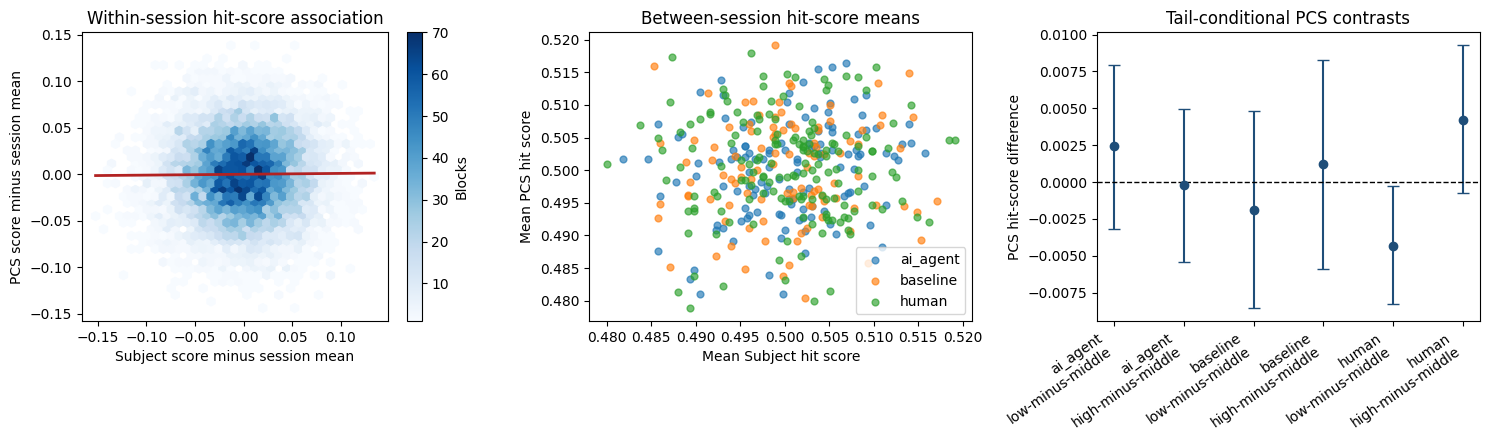


SUMMARY: Subject–PCS Association Diagnostics
Within-session hit-score r=+0.009298, p=0.3171
Within-session R/S Pearson r=+0.009795, p=0.3034
Within-session R/S Spearman rho=+0.008662, p=0.3562
Same-position raw-bit observed-minus-null=-0.000929, p=0.2082

Interpretation: These corrected analyses estimate specified linear,
rank-based, same-relative-position, and tail-conditional associations.
The within-session and session-mean results must be read separately.
Failure to detect an association does not prove statistical independence
or exclude nonlinear, lagged, provider-linked, session-level, or smaller
shared structure. These diagnostics cannot by themselves rule out every
shared artifact in later Subject–PCS differences.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Subject–PCS Association Diagnostics
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Estimate specified contemporaneous Subject–PCS associations while
#          preserving sessions and separating within- from between-session
#          structure. This is not a universal test of statistical independence.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

print("=" * 76)
print("Subject–PCS Association Diagnostics")
print("=" * 76)
print("Scope: specified linear, rank-based, same-position, and tail-conditional")
print("       associations; no practical-equivalence margin was prespecified.")

N_PERM_ASSOC = 10_000
N_BOOT_ASSOC = 10_000
ASSOC_SEED = 20260804
rng_assoc = np.random.default_rng(ASSOC_SEED)


def corr_safe(x, y, method="pearson"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    if method == "spearman":
        return float(stats.spearmanr(x, y).statistic)
    return float(np.corrcoef(x, y)[0, 1])


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    m = len(p_values)
    for rank, index in enumerate(order):
        running = max(running, (m - rank) * p_values[index])
        adjusted[index] = min(1.0, running)
    return adjusted


def within_session_correlation(data, x_col, y_col, method="pearson"):
    work = data[["session_id", x_col, y_col]].dropna().copy()
    if method == "spearman":
        work["_x"] = work.groupby("session_id")[x_col].rank(method="average")
        work["_y"] = work.groupby("session_id")[y_col].rank(method="average")
    else:
        work["_x"] = work[x_col]
        work["_y"] = work[y_col]
    work["_xc"] = work["_x"] - work.groupby("session_id")["_x"].transform("mean")
    work["_yc"] = work["_y"] - work.groupby("session_id")["_y"].transform("mean")

    parts = []
    null_total = np.zeros(N_PERM_ASSOC, dtype=float)
    for session_id, group in work.groupby("session_id", sort=False):
        x = group["_xc"].to_numpy(dtype=float)
        y = group["_yc"].to_numpy(dtype=float)
        if len(x) < 3 or np.sum(x*x) == 0 or np.sum(y*y) == 0:
            continue
        numerators = np.array([np.dot(x, np.roll(y, shift)) for shift in range(len(y))])
        # Nonzero circular shifts break the observed within-call alignment while
        # preserving each session's values and circular temporal arrangement.
        choices = rng_assoc.integers(1, len(y), size=N_PERM_ASSOC)
        null_total += numerators[choices]
        parts.append((session_id, numerators[0], np.sum(x*x), np.sum(y*y)))

    parts_df = pd.DataFrame(parts, columns=["session_id", "xy", "xx", "yy"])
    observed = parts_df["xy"].sum() / np.sqrt(parts_df["xx"].sum() * parts_df["yy"].sum())
    denominator = np.sqrt(parts_df["xx"].sum() * parts_df["yy"].sum())
    null = null_total / denominator
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (N_PERM_ASSOC + 1)

    draws = np.empty(N_BOOT_ASSOC, dtype=float)
    values = parts_df[["xy", "xx", "yy"]].to_numpy()
    for i in range(N_BOOT_ASSOC):
        sample = values[rng_assoc.integers(0, len(values), size=len(values))]
        draws[i] = sample[:, 0].sum() / np.sqrt(sample[:, 1].sum() * sample[:, 2].sum())
    ci = np.quantile(draws, [0.025, 0.975])
    null_ci = np.quantile(null, [0.025, 0.975])
    return observed, ci, null_ci, p_value, parts_df


def session_mean_correlations(data, x_col, y_col):
    session_means = data.groupby(["session_id", "condition"], as_index=False)[[x_col, y_col]].mean()
    rows = []
    for condition, group in session_means.groupby("condition", sort=True):
        pearson = stats.pearsonr(group[x_col], group[y_col])
        spearman = stats.spearmanr(group[x_col], group[y_col])
        rows.append({
            "condition": condition,
            "sessions": len(group),
            "pearson_r": pearson.statistic,
            "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic,
            "spearman_p": spearman.pvalue,
        })
    result = pd.DataFrame(rows)
    result["pearson_p_holm"] = holm_adjust(result["pearson_p"])
    result["spearman_p_holm"] = holm_adjust(result["spearman_p"])
    return session_means, result


# Verify that target-aligned scores and raw one-proportions are distinct but
# related exactly through each block's target bit.
raw_subject_one_rate = df["subject_bits"].map(lambda bits: np.mean(bits))
raw_pcs_one_rate = df["demon_bits"].map(lambda bits: np.mean(bits))
expected_subject_score = np.where(df["target_bit"].eq(1), raw_subject_one_rate, 1 - raw_subject_one_rate)
expected_pcs_score = np.where(df["target_bit"].eq(1), raw_pcs_one_rate, 1 - raw_pcs_one_rate)
assert np.allclose(expected_subject_score, df["rate_subject"])
assert np.allclose(expected_pcs_score, df["rate_pcs"])

print("\nRepresentations verified for every retained block:")
print("  rate_subject/rate_pcs: target-aligned hit scores")
print("  subject_bits/demon_bits: literal raw bits; position j is the same")
print("  relative offset within each sequential 150-bit half of one QRNG call")


# TEST 1: Target-aligned hit-score association.
hit_within = within_session_correlation(df, "rate_subject", "rate_pcs", "pearson")
hit_session_means, hit_between = session_mean_correlations(df, "rate_subject", "rate_pcs")

print("\n" + "-" * 76)
print("TEST 1: Target-aligned hit-score association")
print("-" * 76)
print(f"Within-session demeaned Pearson r: {hit_within[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hit_within[1][0]:+.6f}, {hit_within[1][1]:+.6f}]")
print(f"Circular-shift null 95% interval:  [{hit_within[2][0]:+.6f}, {hit_within[2][1]:+.6f}]")
print(f"Two-sided Monte Carlo p:           {hit_within[3]:.4f}")
print("\nBetween-session association of session means (Holm within metric):")
display(hit_between.round(6))


# TEST 2: Single-scale R/S association, Pearson and rank-based.
hurst_valid = df_hurst[["session_id", "condition", "hurst_subject", "hurst_pcs"]].dropna().copy()
hurst_within_p = within_session_correlation(hurst_valid, "hurst_subject", "hurst_pcs", "pearson")
hurst_within_s = within_session_correlation(hurst_valid, "hurst_subject", "hurst_pcs", "spearman")
hurst_session_means, hurst_between = session_mean_correlations(hurst_valid, "hurst_subject", "hurst_pcs")

print("\n" + "-" * 76)
print("TEST 2: Single-scale R/S association")
print("-" * 76)
print(f"Within-session Pearson r:          {hurst_within_p[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hurst_within_p[1][0]:+.6f}, {hurst_within_p[1][1]:+.6f}]")
print(f"Circular-shift p:                  {hurst_within_p[3]:.4f}")
print(f"Within-session Spearman rho:       {hurst_within_s[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hurst_within_s[1][0]:+.6f}, {hurst_within_s[1][1]:+.6f}]")
print(f"Circular-shift p:                  {hurst_within_s[3]:.4f}")
print("\nBetween-session association of session means (Holm within metric):")
display(hurst_between.round(6))


# TEST 3: Same-relative-position raw-bit correlation, all eligible blocks.
# Each block is calibrated against all 149 nonzero circular shifts of its PCS
# half, preserving both binary margins. Inference then uses sessions.
bit_rows = []
for _, row in df.iterrows():
    x = np.asarray(row["subject_bits"], dtype=float)
    y = np.asarray(row["demon_bits"], dtype=float)
    if len(x) != 150 or len(y) != 150 or np.std(x) == 0 or np.std(y) == 0:
        continue
    x = x - x.mean()
    y = y - y.mean()
    denominator = np.sqrt(np.dot(x, x) * np.dot(y, y))
    correlations = np.array([np.dot(x, np.roll(y, shift)) / denominator for shift in range(150)])
    bit_rows.append((row["session_id"], correlations[0], correlations[1:].mean()))

bit_df = pd.DataFrame(bit_rows, columns=["session_id", "observed_r", "shift_null_mean"])
bit_df["observed_minus_null"] = bit_df["observed_r"] - bit_df["shift_null_mean"]
bit_session = bit_df.groupby("session_id", as_index=False).agg(
    observed_r=("observed_r", "mean"),
    shift_null_mean=("shift_null_mean", "mean"),
    observed_minus_null=("observed_minus_null", "mean"),
)
bit_effect = bit_session["observed_minus_null"].mean()
bit_boot = np.empty(N_BOOT_ASSOC)
bit_values = bit_session["observed_minus_null"].to_numpy()
for i in range(N_BOOT_ASSOC):
    bit_boot[i] = rng_assoc.choice(bit_values, size=len(bit_values), replace=True).mean()
bit_ci = np.quantile(bit_boot, [0.025, 0.975])
signs = rng_assoc.choice((-1.0, 1.0), size=(N_PERM_ASSOC, len(bit_values)))
bit_null = (signs * bit_values).mean(axis=1)
bit_p = (np.sum(np.abs(bit_null) >= abs(bit_effect)) + 1) / (N_PERM_ASSOC + 1)

print("\n" + "-" * 76)
print("TEST 3: Same-relative-position raw-bit correlation")
print("-" * 76)
print(f"Eligible blocks:                    {len(bit_df):,}")
print(f"Observed mean same-position r:      {bit_df['observed_r'].mean():+.6f}")
print(f"Mean circular-shift null:           {bit_df['shift_null_mean'].mean():+.6f}")
print(f"Observed-minus-null:                {bit_effect:+.6f}")
print(f"Session-bootstrap 95% CI:           [{bit_ci[0]:+.6f}, {bit_ci[1]:+.6f}]")
print(f"Session sign-flip p:                {bit_p:.4f}")


# TEST 4: PCS score conditional on condition-specific Subject-score tails.
# Quantile ties are retained and achieved group sizes are reported.
tail_rows = []
tail_nulls = []
for condition, condition_df in df.groupby("condition", sort=True):
    work = condition_df.sort_values(["session_id", "block_idx"]).copy()
    low_cut = work["rate_subject"].quantile(0.05)
    high_cut = work["rate_subject"].quantile(0.95)
    work["tail_group"] = np.where(
        work["rate_subject"] <= low_cut, "low",
        np.where(work["rate_subject"] >= high_cut, "high", "middle")
    )
    means = work.groupby("tail_group")["rate_pcs"].mean()
    counts = work["tail_group"].value_counts()
    for tail in ["low", "high"]:
        observed = means[tail] - means["middle"]
        null = np.zeros(N_PERM_ASSOC)
        for _, group in work.groupby("session_id", sort=False):
            y = group["rate_pcs"].to_numpy(dtype=float)
            g = group["tail_group"].to_numpy()
            weights = np.where(g == tail, 1.0 / counts[tail], np.where(g == "middle", -1.0 / counts["middle"], 0.0))
            shifted = np.array([np.dot(weights, np.roll(y, shift)) for shift in range(len(y))])
            null += shifted[rng_assoc.integers(1, len(y), size=N_PERM_ASSOC)]
        p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (N_PERM_ASSOC + 1)

        # Resampling these session-level sums and counts is algebraically
        # identical to rebuilding every resampled block table, but much faster.
        session_components = []
        for _, group in work.groupby("session_id", sort=False):
            tail_values = group.loc[group["tail_group"].eq(tail), "rate_pcs"]
            middle_values = group.loc[group["tail_group"].eq("middle"), "rate_pcs"]
            session_components.append((
                tail_values.sum(), len(tail_values),
                middle_values.sum(), len(middle_values),
            ))
        components = np.asarray(session_components, dtype=float)
        sample_indices = rng_assoc.integers(
            0, len(components), size=(N_BOOT_ASSOC, len(components))
        )
        sampled = components[sample_indices].sum(axis=1)
        boot = sampled[:, 0] / sampled[:, 1] - sampled[:, 2] / sampled[:, 3]
        ci = np.quantile(boot, [0.025, 0.975])
        tail_rows.append({
            "condition": condition, "contrast": f"{tail}-minus-middle",
            "n_tail": int(counts[tail]), "n_middle": int(counts["middle"]),
            "estimate": observed, "ci_low": ci[0], "ci_high": ci[1], "p_perm": p_value,
        })

tail_results = pd.DataFrame(tail_rows)
tail_results["p_holm"] = holm_adjust(tail_results["p_perm"])

print("\n" + "-" * 76)
print("TEST 4: Tail-conditional PCS hit-score contrasts")
print("-" * 76)
print("Tails use condition-specific 5th/95th percentile cutoffs; ties retained.")
print("Holm adjustment covers the six displayed contrasts.")
display(tail_results.round(6))


# Visual summaries distinguish within-session residual association from
# between-session means; no y=x equality guide is used.
hit_plot = df[["session_id", "rate_subject", "rate_pcs"]].copy()
hit_plot["subject_within"] = hit_plot["rate_subject"] - hit_plot.groupby("session_id")["rate_subject"].transform("mean")
hit_plot["pcs_within"] = hit_plot["rate_pcs"] - hit_plot.groupby("session_id")["rate_pcs"].transform("mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
hb = axes[0].hexbin(hit_plot["subject_within"], hit_plot["pcs_within"], gridsize=35, mincnt=1, cmap="Blues")
coef = np.polyfit(hit_plot["subject_within"], hit_plot["pcs_within"], 1)
grid = np.linspace(hit_plot["subject_within"].min(), hit_plot["subject_within"].max(), 100)
axes[0].plot(grid, np.polyval(coef, grid), color="#b22222", linewidth=2)
axes[0].set(title="Within-session hit-score association", xlabel="Subject score minus session mean", ylabel="PCS score minus session mean")
fig.colorbar(hb, ax=axes[0], label="Blocks")

for condition, group in hit_session_means.groupby("condition", sort=True):
    axes[1].scatter(group["rate_subject"], group["rate_pcs"], alpha=.65, s=24, label=condition)
axes[1].set(title="Between-session hit-score means", xlabel="Mean Subject hit score", ylabel="Mean PCS hit score")
axes[1].legend()

axes[2].errorbar(
    np.arange(len(tail_results)), tail_results["estimate"],
    yerr=[tail_results["estimate"] - tail_results["ci_low"], tail_results["ci_high"] - tail_results["estimate"]],
    fmt="o", capsize=4, color="#1f4e79"
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xticks(np.arange(len(tail_results)))
axes[2].set_xticklabels(tail_results["condition"] + "\n" + tail_results["contrast"], rotation=35, ha="right")
axes[2].set(title="Tail-conditional PCS contrasts", ylabel="PCS hit-score difference")
plt.tight_layout()
plt.show()


print("\n" + "=" * 76)
print("SUMMARY: Subject–PCS Association Diagnostics")
print("=" * 76)
print(f"Within-session hit-score r={hit_within[0]:+.6f}, p={hit_within[3]:.4f}")
print(f"Within-session R/S Pearson r={hurst_within_p[0]:+.6f}, p={hurst_within_p[3]:.4f}")
print(f"Within-session R/S Spearman rho={hurst_within_s[0]:+.6f}, p={hurst_within_s[3]:.4f}")
print(f"Same-position raw-bit observed-minus-null={bit_effect:+.6f}, p={bit_p:.4f}")
print("\nInterpretation: These corrected analyses estimate specified linear,")
print("rank-based, same-relative-position, and tail-conditional associations.")
print("The within-session and session-mean results must be read separately.")
print("Failure to detect an association does not prove statistical independence")
print("or exclude nonlinear, lagged, provider-linked, session-level, or smaller")
print("shared structure. These diagnostics cannot by themselves rule out every")
print("shared artifact in later Subject–PCS differences.")


### Condition Comparisons of Subject–PCS Relationship Structure

This section supplies the corrected condition-comparison extension reported in Paper §3.2.5. It compares the block-level Subject–PCS single-scale R/S correlation, the joint two-dimensional R/S-score distribution, and the variance of session-mean paired R/S-score deltas.

Observed correlation and energy statistics retain the paper's block-level estimands, while condition-label permutations move whole session bundles. Energy distance is calculated exactly from session-pair aggregates rather than by treating blocks as independently exchangeable. The variance analysis uses one mean ΔH value per session and a Brown–Forsythe statistic. These are difference-detection analyses, not tests proving independence or equality. Collection-time and incompletely recorded provider structure remain unresolved.


In [10]:
from scipy.spatial.distance import cdist

RELATION_SEED = 20260805
RELATION_N_PERM = 9_999
ENERGY_N_PERM = 4_999
RELATION_PAIRS = (("human", "baseline"), ("ai_agent", "baseline"), ("human", "ai_agent"))

relationship_work = df_hurst[[
    "session_id", "condition", "hurst_subject", "hurst_pcs", "delta_hurst"
]].dropna().copy()

def session_sufficient_statistics(frame):
    return frame.groupby(["session_id", "condition"], as_index=False).agg(
        n=("hurst_subject", "size"),
        sx=("hurst_subject", "sum"), sy=("hurst_pcs", "sum"),
        sxx=("hurst_subject", lambda x: float(np.dot(x, x))),
        syy=("hurst_pcs", lambda y: float(np.dot(y, y))),
        sxy=("hurst_subject", lambda x: 0.0),
    )

relationship_sessions = []
for (session_id, condition), group in relationship_work.groupby(["session_id", "condition"], sort=False):
    x = group["hurst_subject"].to_numpy(float)
    y = group["hurst_pcs"].to_numpy(float)
    relationship_sessions.append({
        "session_id": session_id, "condition": condition, "n": len(group),
        "sx": x.sum(), "sy": y.sum(), "sxx": np.dot(x, x),
        "syy": np.dot(y, y), "sxy": np.dot(x, y),
        "mean_delta_hurst": group["delta_hurst"].mean(),
        "points": np.column_stack([x, y]),
    })
relationship_sessions = pd.DataFrame(relationship_sessions)

def corr_from_bundle_rows(rows):
    n = rows["n"].sum()
    sx, sy = rows["sx"].sum(), rows["sy"].sum()
    numerator = rows["sxy"].sum() - sx * sy / n
    denominator = np.sqrt((rows["sxx"].sum() - sx * sx / n) * (rows["syy"].sum() - sy * sy / n))
    return float(numerator / denominator)

def fisher_difference_test(condition_a, condition_b, seed):
    bundles = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])].reset_index(drop=True)
    labels = bundles["condition"].to_numpy()
    mask_a = labels == condition_a
    r_a = corr_from_bundle_rows(bundles.loc[mask_a])
    r_b = corr_from_bundle_rows(bundles.loc[~mask_a])
    observed = np.arctanh(np.clip(r_a, -.999999, .999999)) - np.arctanh(np.clip(r_b, -.999999, .999999))
    rng = default_rng(seed)
    null = np.empty(RELATION_N_PERM)
    n_a = int(mask_a.sum())
    for i in range(RELATION_N_PERM):
        perm_a = np.zeros(len(bundles), dtype=bool)
        perm_a[rng.choice(len(bundles), n_a, replace=False)] = True
        rp_a = corr_from_bundle_rows(bundles.loc[perm_a])
        rp_b = corr_from_bundle_rows(bundles.loc[~perm_a])
        null[i] = np.arctanh(np.clip(rp_a, -.999999, .999999)) - np.arctanh(np.clip(rp_b, -.999999, .999999))
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (RELATION_N_PERM + 1)
    return r_a, r_b, observed, p_value, int(mask_a.sum()), int((~mask_a).sum())

fisher_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    r_a, r_b, z_difference, p_value, n_a, n_b = fisher_difference_test(
        condition_a, condition_b, RELATION_SEED + index
    )
    fisher_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}",
        "r_a": r_a, "r_b": r_b, "fisher_z_difference": z_difference,
        "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
    })
fisher_condition_results = pd.DataFrame(fisher_rows)
fisher_condition_results["p_holm_3"] = nb1_holm(fisher_condition_results["p_session_permutation"])

def energy_distance_test(condition_a, condition_b, seed):
    bundles = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])].reset_index(drop=True)
    labels = bundles["condition"].to_numpy()
    n_sessions = len(bundles)
    distance_sums = np.empty((n_sessions, n_sessions), dtype=float)
    pair_counts = np.empty((n_sessions, n_sessions), dtype=float)
    for i in range(n_sessions):
        xi = bundles.at[i, "points"]
        for j in range(i, n_sessions):
            xj = bundles.at[j, "points"]
            value = cdist(xi, xj, metric="euclidean").sum()
            distance_sums[i, j] = distance_sums[j, i] = value
            pair_counts[i, j] = pair_counts[j, i] = len(xi) * len(xj)
    def statistic(mask_a):
        mask_b = ~mask_a
        cross = distance_sums[np.ix_(mask_a, mask_b)].sum() / pair_counts[np.ix_(mask_a, mask_b)].sum()
        within_a = distance_sums[np.ix_(mask_a, mask_a)].sum() / pair_counts[np.ix_(mask_a, mask_a)].sum()
        within_b = distance_sums[np.ix_(mask_b, mask_b)].sum() / pair_counts[np.ix_(mask_b, mask_b)].sum()
        return 2.0 * cross - within_a - within_b
    observed_mask = labels == condition_a
    observed = statistic(observed_mask)
    rng = default_rng(seed)
    null = np.empty(ENERGY_N_PERM)
    n_a = int(observed_mask.sum())
    for i in range(ENERGY_N_PERM):
        perm_a = np.zeros(n_sessions, dtype=bool)
        perm_a[rng.choice(n_sessions, n_a, replace=False)] = True
        null[i] = statistic(perm_a)
    p_value = (np.count_nonzero(null >= observed) + 1) / (ENERGY_N_PERM + 1)
    return observed, p_value, n_a, n_sessions - n_a

energy_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    estimate, p_value, n_a, n_b = energy_distance_test(
        condition_a, condition_b, RELATION_SEED + 100 + index
    )
    energy_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}", "energy_distance": estimate,
        "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
    })
energy_condition_results = pd.DataFrame(energy_rows)
energy_condition_results["p_holm_3"] = nb1_holm(energy_condition_results["p_session_permutation"])

def brown_forsythe_session_test(condition_a, condition_b, seed):
    work = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])]
    a = work.loc[work["condition"].eq(condition_a), "mean_delta_hurst"].to_numpy(float)
    b = work.loc[work["condition"].eq(condition_b), "mean_delta_hurst"].to_numpy(float)
    observed = stats.levene(a, b, center="median").statistic
    ratio = np.var(a, ddof=1) / np.var(b, ddof=1)
    pooled = np.concatenate([a, b])
    rng = default_rng(seed)
    null = np.empty(RELATION_N_PERM)
    for i in range(RELATION_N_PERM):
        perm = rng.permutation(pooled)
        null[i] = stats.levene(perm[:len(a)], perm[len(a):], center="median").statistic
    p_value = (np.count_nonzero(null >= observed) + 1) / (RELATION_N_PERM + 1)
    return ratio, observed, p_value, len(a), len(b)

variance_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    ratio, statistic, p_value, n_a, n_b = brown_forsythe_session_test(
        condition_a, condition_b, RELATION_SEED + 200 + index
    )
    variance_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}",
        "session_mean_delta_hurst_variance_ratio_a_over_b": ratio,
        "brown_forsythe_W": statistic, "p_session_permutation": p_value,
        "sessions_a": n_a, "sessions_b": n_b,
    })
delta_hurst_variance_condition_results = pd.DataFrame(variance_rows)
delta_hurst_variance_condition_results["p_holm_3"] = nb1_holm(
    delta_hurst_variance_condition_results["p_session_permutation"]
)

print(f"Fisher/Brown-Forsythe whole-session permutations: {RELATION_N_PERM:,}")
print(f"Energy-distance whole-session permutations: {ENERGY_N_PERM:,}")
print("\nFisher-z transformed block-correlation differences")
display(fisher_condition_results.round(6))
print("\nTwo-dimensional block-level energy-distance comparisons")
display(energy_condition_results.round(6))
print("\nBrown-Forsythe comparisons of session-mean paired R/S-score deltas")
display(delta_hurst_variance_condition_results.round(6))
print("Interpretation: these analyses test specified condition differences while preserving")
print("session bundles. Nondetection does not prove equal distributions, equal variances,")
print("general independence, hardware cleanliness, or absence of provider confounding.")


Fisher/Brown-Forsythe whole-session permutations: 9,999
Energy-distance whole-session permutations: 4,999

Fisher-z transformed block-correlation differences


,contrast,r_a,r_b,fisher_z_difference,p_session_permutation,sessions_a,sessions_b,p_holm_3
0,human-versus-baseline,0.010950,0.003729,0.007222,0.7489,158,103,1.0
1,ai_agent-versus-baseline,0.009875,0.003729,0.006146,0.7881,126,103,1.0
2,human-versus-ai_agent,0.010950,0.009875,0.001076,0.9607,158,126,1.0



Two-dimensional block-level energy-distance comparisons


,contrast,energy_distance,p_session_permutation,sessions_a,sessions_b,p_holm_3
0,human-versus-baseline,0.000057,0.2082,158,103,0.6246
1,ai_agent-versus-baseline,0.000046,0.4020,126,103,0.8040
2,human-versus-ai_agent,0.000026,0.6688,158,126,0.8040



Brown-Forsythe comparisons of session-mean paired R/S-score deltas


,contrast,session_mean_delta_hurst_variance_ratio_a_over_b,brown_forsythe_W,p_session_permutation,sessions_a,sessions_b,p_holm_3
0,human-versus-baseline,1.198547,0.397620,0.5329,158,103,1.0
1,ai_agent-versus-baseline,1.236846,0.424099,0.5160,126,103,1.0
2,human-versus-ai_agent,0.969035,0.003687,0.9470,158,126,1.0


Interpretation: these analyses test specified condition differences while preserving
session bundles. Nondetection does not prove equal distributions, equal variances,
general independence, hardware cleanliness, or absence of provider confounding.


### Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance

**Paper section: 3.5 (Mean-Level Hit-Rate Results)**

This section reports two distinct features of the realized data: the covariance contribution and variance cost created by subtracting the paired streams, and full-sample mean hit-rate contrasts. The primary frequentist estimands are the Human paired delta relative to zero and the Human-minus-Baseline difference in paired deltas. Other condition/stream comparisons are secondary calibration diagnostics.

Point estimates remain block-weighted. Session-cluster bootstraps preserve all blocks from a selected session and provide the primary uncertainty analysis. Conventional block-level t tests are retained only as transparent reference calculations for the originally declared block-level analysis; they do not support population generalization by themselves. Human participant-cluster sensitivity is reported where stable repeated participant identifiers are available.


Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance
Primary estimands:
  1. Human paired delta versus zero
  2. Human minus Baseline paired-delta contrast
Secondary analyses: other stream/condition mean contrasts and centering checks.

------------------------------------------------------------------------------
PART 1: Observed covariance contribution to paired-delta variance
------------------------------------------------------------------------------
Subject variance:                         0.001670894
PCS variance:                             0.001656497
Subject-PCS covariance:                   +0.000018785
Subject-PCS correlation:                  +0.011291
Independent-halves variance benchmark:    0.003327391
Observed paired-delta variance:           0.003289821
Below sum-of-variances benchmark:         1.129%
Var(delta) / Var(Subject):                1.968899
Var(delta) / Var(PCS):                    1.986011
SD(delta) / SD(Subject):                  1.403175


,metric,comparison,estimate,ci_low,ci_high,session_boot_p,block_welch_p_reference,sessions_a,sessions_b
0,Subject,AI - Baseline,0.000105,-0.001717,0.001965,0.912454,0.915858,126,103
1,Subject,Human - Baseline,0.000207,-0.001581,0.001998,0.813459,0.827163,158,103
2,Subject,Human - AI,0.000102,-0.001572,0.001770,0.900355,0.909167,158,126
3,PCS,AI - Baseline,0.000082,-0.001934,0.002079,0.928254,0.934806,126,103
4,PCS,Human - Baseline,0.000607,-0.001347,0.002513,0.545973,0.520715,158,103
5,PCS,Human - AI,0.000525,-0.001245,0.002322,0.558672,0.552422,158,126
6,Paired delta,AI - Baseline,0.000023,-0.002503,0.002598,0.985951,0.986729,126,103
7,Paired delta,Human - Baseline,-0.000400,-0.002964,0.002221,0.765962,0.762454,158,103
8,Paired delta,Human - AI,-0.000424,-0.002721,0.001899,0.716664,0.734851,158,126



The block-level Welch p-values are reference calculations only. They treat
blocks as independent and are not the basis for population-level inference.
The nine secondary/primary entries are related estimands, not a PASS/FAIL battery.

------------------------------------------------------------------------------
PART 3: PCS mean contrasts — bounded calibration statement
------------------------------------------------------------------------------


,comparison,estimate,ci_low,ci_high,session_boot_p
3,AI - Baseline,0.000082,-0.001934,0.002079,0.928254
4,Human - Baseline,0.000607,-0.001347,0.002513,0.545973
5,Human - AI,0.000525,-0.001245,0.002322,0.558672


No condition difference in mean PCS hit rate was detected at the resolution
of this session-aware analysis. This is one calibration check; it does not
prove condition equivalence or exclude distributional, temporal, provider-
linked, or smaller differences. See the dedicated PCS calibration sections.

------------------------------------------------------------------------------
PART 4: Separate within-condition centering checks
------------------------------------------------------------------------------
Subject hit rate versus 0.5 and paired delta versus 0 test different nulls.
Their significance labels must not be compared as a test of design merit.


,condition,estimand,estimate,ci_low,ci_high,session_boot_p,block_t_p_reference,sessions
0,human,Subject mean minus 0.5,0.000386,-0.000739,0.001529,0.498875,0.515600,158
1,human,Paired delta minus 0,-0.000200,-0.001869,0.001475,0.817259,0.808022,158
2,ai_agent,Subject mean minus 0.5,0.000284,-0.000940,0.001508,0.648668,0.669427,126
3,ai_agent,Paired delta minus 0,0.000224,-0.001379,0.001794,0.785561,0.812294,126
4,baseline,Subject mean minus 0.5,0.000179,-0.001184,0.001566,0.806160,0.808019,103
5,baseline,Paired delta minus 0,0.000201,-0.001817,0.002190,0.851957,0.846849,103



Human participant-cluster sensitivity:
  Stable Human participant identifiers: 121
  Human delta: -0.000200, 95% CI [-0.001878, +0.001426], p=0.8129
  Human - Baseline delta: -0.000400, 95% CI [-0.003035, +0.002181], p=0.7560
  Human participants and Baseline sessions were resampled separately because
  Baseline identifiers are not interpreted as independently sampled people.


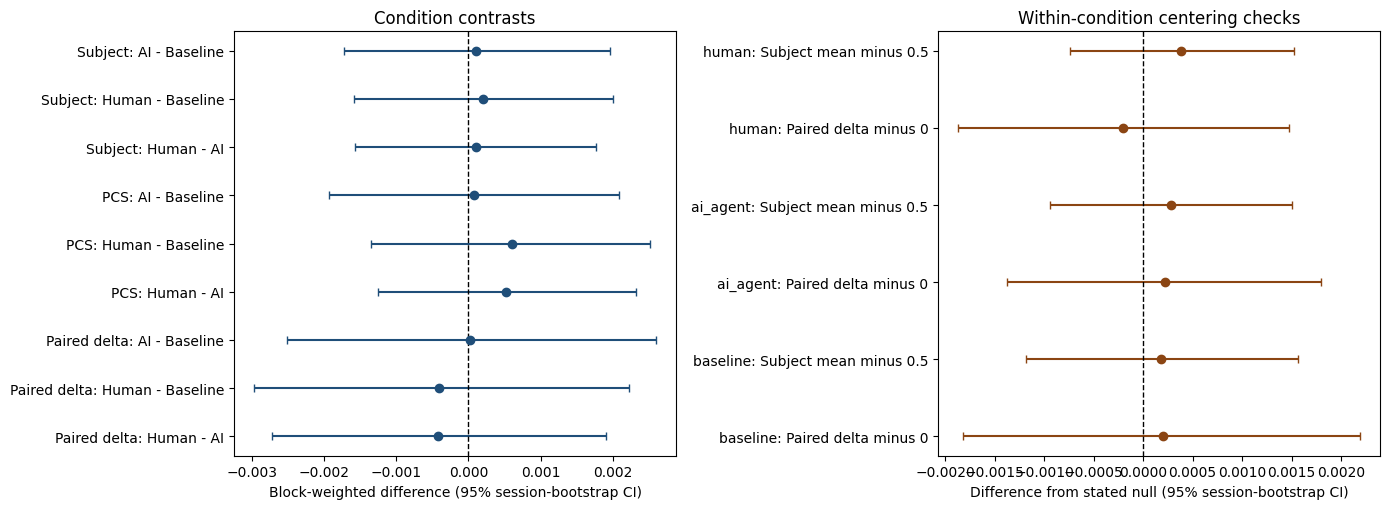


SUMMARY: Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance
Human paired delta vs zero: -0.000200, 
  95% session-bootstrap CI [-0.001869, +0.001475], p=0.8173
Human - Baseline paired delta: -0.000400, 
  95% session-bootstrap CI [-0.002964, +0.002221], p=0.7660

No full-sample mean contrast was detected at this analysis's estimated
resolution. This does not distinguish an exact null from an effect smaller
than the detectable range and does not justify subgroup search. Any subgroup
analyses are separately labeled post hoc and exploratory.

The observed mean contrasts do not by themselves establish design merit or
PCS invariance. Architecture tradeoffs are evaluated by the covariance/variance
diagnostic above and the dedicated artifact-injection/recovery simulations.

Reproducibility: seed=20260804; bootstrap replicates=20,000; 
Python=3.12.13; NumPy=2.0.2; pandas=2.2.2; SciPy=1.16.3


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: (1) quantify the observed covariance contribution and variance cost
#          of paired subtraction; (2) estimate full-sample paired-delta and
#          condition mean contrasts with session-aware uncertainty.
# ═══════════════════════════════════════════════════════════════════════════

import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats

print("=" * 78)
print("Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance")
print("=" * 78)
print("Primary estimands:")
print("  1. Human paired delta versus zero")
print("  2. Human minus Baseline paired-delta contrast")
print("Secondary analyses: other stream/condition mean contrasts and centering checks.")

N_BOOT_C6 = 20_000
C6_SEED = 20260804
rng_c6 = np.random.default_rng(C6_SEED)


def two_sided_boot_p(draws, null=0.0):
    """Equal-tail bootstrap p-value with a plus-one Monte Carlo correction."""
    draws = np.asarray(draws, dtype=float)
    lower = (np.sum(draws <= null) + 1) / (len(draws) + 1)
    upper = (np.sum(draws >= null) + 1) / (len(draws) + 1)
    return min(1.0, 2.0 * min(lower, upper))


def cluster_components(data, metric, cluster_col):
    """Return cluster sums and counts so the block-weighted estimand is preserved."""
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col, as_index=False)[metric]
        .agg(["sum", "count"])[["sum", "count"]]
        .to_numpy(dtype=float)
    )


def bootstrap_block_weighted_mean(data, metric, cluster_col="session_id", n_boot=N_BOOT_C6):
    components = cluster_components(data, metric, cluster_col)
    observed = components[:, 0].sum() / components[:, 1].sum()
    indices = rng_c6.integers(0, len(components), size=(n_boot, len(components)))
    sampled = components[indices].sum(axis=1)
    draws = sampled[:, 0] / sampled[:, 1]
    return observed, draws, len(components)


def bootstrap_condition_contrast(data, metric, cond_a, cond_b, cluster_col="session_id"):
    a = data.loc[data["condition"].eq(cond_a)]
    b = data.loc[data["condition"].eq(cond_b)]
    est_a, draw_a, n_a = bootstrap_block_weighted_mean(a, metric, cluster_col)
    est_b, draw_b, n_b = bootstrap_block_weighted_mean(b, metric, cluster_col)
    return est_a - est_b, draw_a - draw_b, n_a, n_b


def summarize_draws(estimate, draws):
    ci = np.quantile(draws, [0.025, 0.975])
    return float(ci[0]), float(ci[1]), float(two_sided_boot_p(draws))


# ──────────────────────────────────────────────────────────────────────────
# PART 1: Observed covariance contribution to paired-delta variance
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 1: Observed covariance contribution to paired-delta variance")
print("-" * 78)

var_subject = df["rate_subject"].var(ddof=1)
var_pcs = df["rate_pcs"].var(ddof=1)
var_delta = df["delta_rate"].var(ddof=1)
cov_subject_pcs = df[["rate_subject", "rate_pcs"]].cov().iloc[0, 1]
corr_subject_pcs = df[["rate_subject", "rate_pcs"]].corr().iloc[0, 1]
independent_sum = var_subject + var_pcs
covariance_contribution = 100 * (1 - var_delta / independent_sum)
ratio_subject = var_delta / var_subject
ratio_pcs = var_delta / var_pcs
sd_ratio_subject = np.sqrt(ratio_subject)

print(f"Subject variance:                         {var_subject:.9f}")
print(f"PCS variance:                             {var_pcs:.9f}")
print(f"Subject-PCS covariance:                   {cov_subject_pcs:+.9f}")
print(f"Subject-PCS correlation:                  {corr_subject_pcs:+.6f}")
print(f"Independent-halves variance benchmark:    {independent_sum:.9f}")
print(f"Observed paired-delta variance:           {var_delta:.9f}")
print(f"Below sum-of-variances benchmark:         {covariance_contribution:.3f}%")
print(f"Var(delta) / Var(Subject):                {ratio_subject:.6f}")
print(f"Var(delta) / Var(PCS):                    {ratio_pcs:.6f}")
print(f"SD(delta) / SD(Subject):                  {sd_ratio_subject:.6f}")
print("\nInterpretation: the percentage relative to the sum-of-variances benchmark")
print("is a covariance/common-mode diagnostic, not a precision gain over using one")
print("stream. Relative to either stream, subtraction produced approximately twice")
print("the variance, the expected cost when two streams are nearly independent.")


# ──────────────────────────────────────────────────────────────────────────
# PART 2: Condition contrasts with session-cluster uncertainty
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 2: Session-clustered condition mean contrasts")
print("-" * 78)
print(f"Block-weighted estimates; {N_BOOT_C6:,} session-cluster bootstrap replicates.")
print("Bootstrap p-values are equal-tail, two-sided, and unadjusted.")

comparisons = [
    ("ai_agent", "baseline", "AI - Baseline"),
    ("human", "baseline", "Human - Baseline"),
    ("human", "ai_agent", "Human - AI"),
]
metrics = [
    ("rate_subject", "Subject"),
    ("rate_pcs", "PCS"),
    ("delta_rate", "Paired delta"),
]

contrast_rows = []
contrast_draws = {}
for metric, metric_label in metrics:
    for cond_a, cond_b, comparison_label in comparisons:
        estimate, draws, n_a, n_b = bootstrap_condition_contrast(
            df, metric, cond_a, cond_b, cluster_col="session_id"
        )
        ci_low, ci_high, p_boot = summarize_draws(estimate, draws)
        values_a = df.loc[df["condition"].eq(cond_a), metric].dropna()
        values_b = df.loc[df["condition"].eq(cond_b), metric].dropna()
        welch = stats.ttest_ind(values_a, values_b, equal_var=False)
        key = (metric, cond_a, cond_b)
        contrast_draws[key] = draws
        contrast_rows.append({
            "metric": metric_label,
            "comparison": comparison_label,
            "estimate": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "session_boot_p": p_boot,
            "block_welch_p_reference": welch.pvalue,
            "sessions_a": n_a,
            "sessions_b": n_b,
        })

contrast_results = pd.DataFrame(contrast_rows)
display(contrast_results.round(6))
print("\nThe block-level Welch p-values are reference calculations only. They treat")
print("blocks as independent and are not the basis for population-level inference.")
print("The nine secondary/primary entries are related estimands, not a PASS/FAIL battery.")


# ──────────────────────────────────────────────────────────────────────────
# PART 3: PCS mean calibration boundary
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 3: PCS mean contrasts — bounded calibration statement")
print("-" * 78)
pcs_rows = contrast_results.loc[contrast_results["metric"].eq("PCS")]
display(pcs_rows[["comparison", "estimate", "ci_low", "ci_high", "session_boot_p"]].round(6))
print("No condition difference in mean PCS hit rate was detected at the resolution")
print("of this session-aware analysis. This is one calibration check; it does not")
print("prove condition equivalence or exclude distributional, temporal, provider-")
print("linked, or smaller differences. See the dedicated PCS calibration sections.")


# ──────────────────────────────────────────────────────────────────────────
# PART 4: Separate within-condition centering checks
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 4: Separate within-condition centering checks")
print("-" * 78)
print("Subject hit rate versus 0.5 and paired delta versus 0 test different nulls.")
print("Their significance labels must not be compared as a test of design merit.")

centering_rows = []
centering_draws = {}
for condition in ["human", "ai_agent", "baseline"]:
    condition_df = df.loc[df["condition"].eq(condition)]
    for metric, label, null in [
        ("rate_subject", "Subject mean minus 0.5", 0.5),
        ("delta_rate", "Paired delta minus 0", 0.0),
    ]:
        observed_mean, draws, n_sessions = bootstrap_block_weighted_mean(
            condition_df, metric, cluster_col="session_id"
        )
        estimate = observed_mean - null
        centered_draws = draws - null
        ci_low, ci_high, p_boot = summarize_draws(estimate, centered_draws)
        block_test = stats.ttest_1samp(condition_df[metric].dropna(), null)
        centering_draws[(condition, metric)] = centered_draws
        centering_rows.append({
            "condition": condition,
            "estimand": label,
            "estimate": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "session_boot_p": p_boot,
            "block_t_p_reference": block_test.pvalue,
            "sessions": n_sessions,
        })

centering_results = pd.DataFrame(centering_rows)
display(centering_results.round(6))


# Human participant-cluster sensitivity for the two primary questions.
human_participants = df.loc[df["condition"].eq("human"), "participant_id"].nunique()
human_est, human_part_draws, _ = bootstrap_block_weighted_mean(
    df.loc[df["condition"].eq("human")], "delta_rate", cluster_col="participant_id"
)
human_part_ci = np.quantile(human_part_draws, [0.025, 0.975])
human_part_p = two_sided_boot_p(human_part_draws)

# For the Human-minus-Baseline sensitivity, resample Human participants and
# Baseline sessions independently; Baseline identifiers are not interpreted as people.
baseline_est, baseline_session_draws, baseline_sessions = bootstrap_block_weighted_mean(
    df.loc[df["condition"].eq("baseline")], "delta_rate", cluster_col="session_id"
)
hb_part_draws = human_part_draws - baseline_session_draws
hb_part_est = human_est - baseline_est
hb_part_ci = np.quantile(hb_part_draws, [0.025, 0.975])
hb_part_p = two_sided_boot_p(hb_part_draws)

print("\nHuman participant-cluster sensitivity:")
print(f"  Stable Human participant identifiers: {human_participants}")
print(f"  Human delta: {human_est:+.6f}, 95% CI [{human_part_ci[0]:+.6f}, {human_part_ci[1]:+.6f}], p={human_part_p:.4f}")
print(f"  Human - Baseline delta: {hb_part_est:+.6f}, 95% CI [{hb_part_ci[0]:+.6f}, {hb_part_ci[1]:+.6f}], p={hb_part_p:.4f}")
print("  Human participants and Baseline sessions were resampled separately because")
print("  Baseline identifiers are not interpreted as independently sampled people.")


# ──────────────────────────────────────────────────────────────────────────
# Visualization: estimates already fitted above are reused; no tests rerun.
# ──────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

plot_contrasts = contrast_results.copy()
y = np.arange(len(plot_contrasts))
axes[0].errorbar(
    plot_contrasts["estimate"], y,
    xerr=[plot_contrasts["estimate"] - plot_contrasts["ci_low"],
          plot_contrasts["ci_high"] - plot_contrasts["estimate"]],
    fmt="o", capsize=3, color="#1f4e79"
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_contrasts["metric"] + ": " + plot_contrasts["comparison"])
axes[0].invert_yaxis()
axes[0].set(title="Condition contrasts", xlabel="Block-weighted difference (95% session-bootstrap CI)")

plot_center = centering_results.copy()
y2 = np.arange(len(plot_center))
axes[1].errorbar(
    plot_center["estimate"], y2,
    xerr=[plot_center["estimate"] - plot_center["ci_low"],
          plot_center["ci_high"] - plot_center["estimate"]],
    fmt="o", capsize=3, color="#8b4513"
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_yticks(y2)
axes[1].set_yticklabels(plot_center["condition"] + ": " + plot_center["estimand"])
axes[1].invert_yaxis()
axes[1].set(title="Within-condition centering checks", xlabel="Difference from stated null (95% session-bootstrap CI)")
plt.tight_layout()
plt.show()


primary_human = centering_results.loc[
    centering_results["condition"].eq("human") &
    centering_results["estimand"].eq("Paired delta minus 0")
].iloc[0]
primary_hb = contrast_results.loc[
    contrast_results["metric"].eq("Paired delta") &
    contrast_results["comparison"].eq("Human - Baseline")
].iloc[0]

print("\n" + "=" * 78)
print("SUMMARY: Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance")
print("=" * 78)
print(f"Human paired delta vs zero: {primary_human['estimate']:+.6f}, ")
print(f"  95% session-bootstrap CI [{primary_human['ci_low']:+.6f}, {primary_human['ci_high']:+.6f}], p={primary_human['session_boot_p']:.4f}")
print(f"Human - Baseline paired delta: {primary_hb['estimate']:+.6f}, ")
print(f"  95% session-bootstrap CI [{primary_hb['ci_low']:+.6f}, {primary_hb['ci_high']:+.6f}], p={primary_hb['session_boot_p']:.4f}")
print("\nNo full-sample mean contrast was detected at this analysis's estimated")
print("resolution. This does not distinguish an exact null from an effect smaller")
print("than the detectable range and does not justify subgroup search. Any subgroup")
print("analyses are separately labeled post hoc and exploratory.")
print("\nThe observed mean contrasts do not by themselves establish design merit or")
print("PCS invariance. Architecture tradeoffs are evaluated by the covariance/variance")
print("diagnostic above and the dedicated artifact-injection/recovery simulations.")
print(f"\nReproducibility: seed={C6_SEED}; bootstrap replicates={N_BOOT_C6:,}; ")
print(f"Python={platform.python_version()}; NumPy={np.__version__}; pandas={pd.__version__}; SciPy={scipy.__version__}")


### Hit-Rate Paired-Delta Sensitivity and Minimum Detectable Effect

**Paper section: 5.6 (Statistical resolution limits)**

Reports the observed Human-minus-Baseline difference in mean paired hit-rate deltas, then describes
the effect magnitudes associated with 80% and 95% rejection probability under two explicitly
different operating models: a block-independent Welch approximation and a session-cluster bootstrap
location-shift approximation. A Human-participant sensitivity is also shown.

This is a power/sensitivity analysis, not a clustering-robustness analysis and not a confidence bound
on the true effect. The observed-effect inference is reported separately in Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance.


HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE

Estimand
  Mean Human paired hit-rate delta minus mean Baseline paired hit-rate delta
  Human blocks/sessions:    4,737 / 158
  Baseline blocks/sessions: 3,090 / 103
  Human participant IDs:    121
  Observed contrast:         -0.00040049
  Session-bootstrap 95% CI:  [-0.00300254, +0.00220592]
  Participant-sensitivity CI:[-0.00297363, +0.00216946]


,operating model,SE / bootstrap SD,two-sided alpha,MDE at 80% power,MDE at 95% power
0,Block-independent Welch normal approximation,0.001325,0.05,0.003712,0.004776
1,Session-cluster bootstrap location shift,0.001323,0.05,0.003720,0.004770
2,Human-participant / Baseline-session sensitivity,0.001317,0.05,0.003680,0.004740



Interpretation boundary
  The bootstrap critical value is the rejection cutoff under the centered
  session-bootstrap null: ±0.00260399 at alpha=0.05.
  It is not the 80%-power MDE. An MDE is the assumed true effect magnitude
  associated with a target rejection probability across repeated studies
  under the named operating model. It is not a confidence bound, an upper
  bound on the true effect, or a retrospective guarantee.

  This cell evaluates power/sensitivity; it is not a clustering-robustness analysis.
  Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance supplies the observed-effect inference and clustered uncertainty.

Idealized binomial bit-level resolution under complete bit independence
  80%-power MDE: 0.00264481 (2644.81 ppm)
  95%-power MDE: 0.00340310 (3403.10 ppm)
  This theoretical calculation ignores halves within blocks, blocks within
  sessions, and repeated contributors. It is not interchangeable with the
  block-level or clustered MDE.

Historic

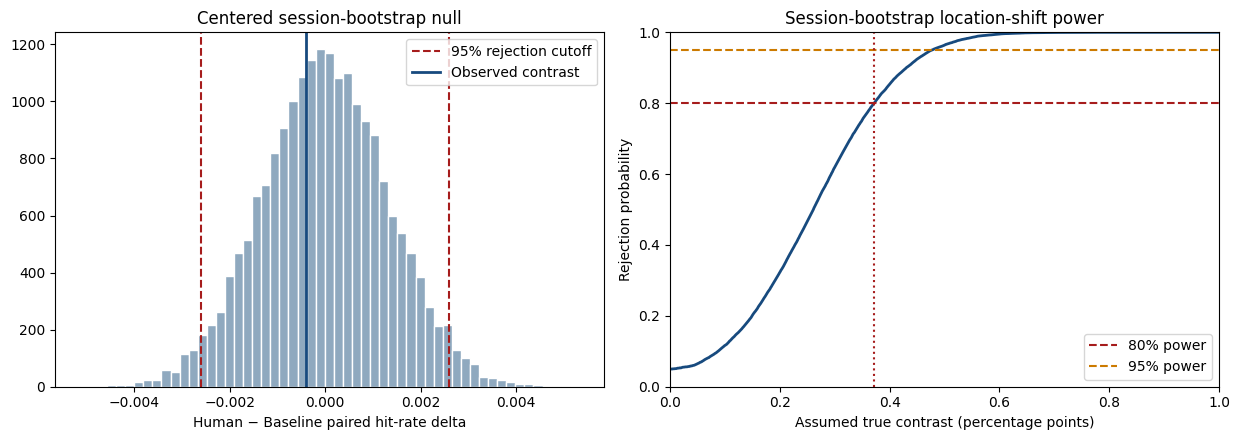


SUMMARY: HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE
Observed Human-minus-Baseline paired hit-rate delta: -0.00040049
Block-independent Welch MDE80: 0.00371192 (0.3712 percentage points)
Session-cluster bootstrap MDE80: 0.00372000 (0.3720 percentage points)
Participant-sensitivity MDE80: 0.00368000 (0.3680 percentage points)
Reproducibility: seed=20260805; bootstrap replicates=20,000; Python=3.12.13; NumPy=2.0.2; pandas=2.2.2; SciPy=1.16.3


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Hit-Rate Paired-Delta Sensitivity and Minimum Detectable Effect
# ═══════════════════════════════════════════════════════════════════════════
# Estimand: mean Human paired hit-rate delta minus mean Baseline paired
#           hit-rate delta, where delta_rate = rate_subject - rate_pcs.
# ═══════════════════════════════════════════════════════════════════════════

import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats

print("=" * 78)
print("HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE")
print("=" * 78)

ALPHA_C7 = 0.05
N_BOOT_C7 = 20_000
C7_SEED = 20260805
rng_c7 = np.random.default_rng(C7_SEED)
z_alpha_c7 = stats.norm.ppf(1 - ALPHA_C7 / 2)


def c7_cluster_components(data, metric, cluster_col):
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col)[metric].agg(["sum", "count"])
        .to_numpy(dtype=float)
    )


def c7_boot_mean(data, metric, cluster_col, n_boot=N_BOOT_C7):
    comp = c7_cluster_components(data, metric, cluster_col)
    estimate = comp[:, 0].sum() / comp[:, 1].sum()
    idx = rng_c7.integers(0, len(comp), size=(n_boot, len(comp)))
    sampled = comp[idx].sum(axis=1)
    return estimate, sampled[:, 0] / sampled[:, 1], len(comp)


def c7_shift_power(null_draws, effects, critical):
    null_draws = np.asarray(null_draws, dtype=float)
    return np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in effects])


def c7_empirical_mde(null_draws, target_power, critical, upper=0.02):
    grid = np.linspace(0, upper, 4001)
    powers = c7_shift_power(null_draws, grid, critical)
    reached = np.flatnonzero(powers >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), grid, powers


human_c7 = df.loc[df["condition"].eq("human")].copy()
baseline_c7 = df.loc[df["condition"].eq("baseline")].copy()
n_human_c7 = human_c7["delta_rate"].notna().sum()
n_baseline_c7 = baseline_c7["delta_rate"].notna().sum()

mean_human_hit_delta_c7 = human_c7["delta_rate"].mean()
mean_baseline_hit_delta_c7 = baseline_c7["delta_rate"].mean()
obs_hit_delta_hb_c7 = mean_human_hit_delta_c7 - mean_baseline_hit_delta_c7

# Block-independent Welch approximation: descriptive operating model only.
sd_human_hit_delta_c7 = human_c7["delta_rate"].std(ddof=1)
sd_baseline_hit_delta_c7 = baseline_c7["delta_rate"].std(ddof=1)
se_hit_delta_hb_block_c7 = np.sqrt(
    sd_human_hit_delta_c7**2 / n_human_c7
    + sd_baseline_hit_delta_c7**2 / n_baseline_c7
)
mde80_hit_delta_hb_block_c7 = (
    z_alpha_c7 + stats.norm.ppf(0.80)
) * se_hit_delta_hb_block_c7
mde95_hit_delta_hb_block_c7 = (
    z_alpha_c7 + stats.norm.ppf(0.95)
) * se_hit_delta_hb_block_c7

# Session-cluster bootstrap sampling distribution for the same block-weighted contrast.
human_hit_est_c7, human_hit_draws_c7, n_human_sessions_c7 = c7_boot_mean(
    human_c7, "delta_rate", "session_id"
)
baseline_hit_est_c7, baseline_hit_draws_c7, n_baseline_sessions_c7 = c7_boot_mean(
    baseline_c7, "delta_rate", "session_id"
)
hit_contrast_draws_c7 = human_hit_draws_c7 - baseline_hit_draws_c7
hit_null_session_c7 = hit_contrast_draws_c7 - hit_contrast_draws_c7.mean()
crit95_hit_session_c7 = np.quantile(np.abs(hit_null_session_c7), 0.95)
se_hit_delta_hb_session_c7 = hit_contrast_draws_c7.std(ddof=1)
mde80_hit_delta_hb_session_c7, hit_effect_grid_c7, hit_power_session_c7 = c7_empirical_mde(
    hit_null_session_c7, 0.80, crit95_hit_session_c7
)
mde95_hit_delta_hb_session_c7, _, _ = c7_empirical_mde(
    hit_null_session_c7, 0.95, crit95_hit_session_c7
)
hit_session_ci_c7 = np.quantile(hit_contrast_draws_c7, [0.025, 0.975])

# Human participant sensitivity; Baseline remains session-resampled because its IDs
# are not interpreted as independently sampled people.
human_hit_part_est_c7, human_hit_part_draws_c7, n_human_participants_c7 = c7_boot_mean(
    human_c7, "delta_rate", "participant_id"
)
hit_part_contrast_draws_c7 = human_hit_part_draws_c7 - baseline_hit_draws_c7
hit_part_ci_c7 = np.quantile(hit_part_contrast_draws_c7, [0.025, 0.975])
hit_null_part_c7 = hit_part_contrast_draws_c7 - hit_part_contrast_draws_c7.mean()
crit95_hit_part_c7 = np.quantile(np.abs(hit_null_part_c7), 0.95)
mde80_hit_delta_hb_part_c7, _, _ = c7_empirical_mde(
    hit_null_part_c7, 0.80, crit95_hit_part_c7
)
mde95_hit_delta_hb_part_c7, _, _ = c7_empirical_mde(
    hit_null_part_c7, 0.95, crit95_hit_part_c7
)

print("\nEstimand")
print("  Mean Human paired hit-rate delta minus mean Baseline paired hit-rate delta")
print(f"  Human blocks/sessions:    {n_human_c7:,} / {n_human_sessions_c7}")
print(f"  Baseline blocks/sessions: {n_baseline_c7:,} / {n_baseline_sessions_c7}")
print(f"  Human participant IDs:    {n_human_participants_c7}")
print(f"  Observed contrast:         {obs_hit_delta_hb_c7:+.8f}")
print(f"  Session-bootstrap 95% CI:  [{hit_session_ci_c7[0]:+.8f}, {hit_session_ci_c7[1]:+.8f}]")
print(f"  Participant-sensitivity CI:[{hit_part_ci_c7[0]:+.8f}, {hit_part_ci_c7[1]:+.8f}]")

hit_mde_table_c7 = pd.DataFrame([
    {
        "operating model": "Block-independent Welch normal approximation",
        "SE / bootstrap SD": se_hit_delta_hb_block_c7,
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_block_c7,
        "MDE at 95% power": mde95_hit_delta_hb_block_c7,
    },
    {
        "operating model": "Session-cluster bootstrap location shift",
        "SE / bootstrap SD": se_hit_delta_hb_session_c7,
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_session_c7,
        "MDE at 95% power": mde95_hit_delta_hb_session_c7,
    },
    {
        "operating model": "Human-participant / Baseline-session sensitivity",
        "SE / bootstrap SD": hit_part_contrast_draws_c7.std(ddof=1),
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_part_c7,
        "MDE at 95% power": mde95_hit_delta_hb_part_c7,
    },
])
display(hit_mde_table_c7.round(8))

print("\nInterpretation boundary")
print("  The bootstrap critical value is the rejection cutoff under the centered")
print(f"  session-bootstrap null: ±{crit95_hit_session_c7:.8f} at alpha={ALPHA_C7:.2f}.")
print("  It is not the 80%-power MDE. An MDE is the assumed true effect magnitude")
print("  associated with a target rejection probability across repeated studies")
print("  under the named operating model. It is not a confidence bound, an upper")
print("  bound on the true effect, or a retrospective guarantee.")
print("\n  This cell evaluates power/sensitivity; it is not a clustering-robustness analysis.")
print("  Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance supplies the observed-effect inference and clustered uncertainty.")

# Idealized bit-level calculation retained only as theoretical scale context.
bits_per_block_c7 = 150
total_bits_human_c7 = n_human_c7 * bits_per_block_c7
total_bits_baseline_c7 = n_baseline_c7 * bits_per_block_c7
se_bit_ideal_c7 = np.sqrt(
    0.5 * 0.5 / total_bits_human_c7 + 0.5 * 0.5 / total_bits_baseline_c7
)
mde80_bit_ideal_c7 = (z_alpha_c7 + stats.norm.ppf(0.80)) * se_bit_ideal_c7
mde95_bit_ideal_c7 = (z_alpha_c7 + stats.norm.ppf(0.95)) * se_bit_ideal_c7
print("\nIdealized binomial bit-level resolution under complete bit independence")
print(f"  80%-power MDE: {mde80_bit_ideal_c7:.8f} ({mde80_bit_ideal_c7*1e6:.2f} ppm)")
print(f"  95%-power MDE: {mde95_bit_ideal_c7:.8f} ({mde95_bit_ideal_c7*1e6:.2f} ppm)")
print("  This theoretical calculation ignores halves within blocks, blocks within")
print("  sessions, and repeated contributors. It is not interchangeable with the")
print("  block-level or clustered MDE.")

print("\nHistorical scale context")
print("  A historical absolute hit-probability shift near 0.0002 is numerically")
print("  smaller than these MDEs. The comparison is approximate because historical")
print("  absolute hit-rate effects and this Human-minus-Baseline paired-delta")
print("  contrast are not the same estimand.")
print("  Larger subgroup effects may be detectable, but subgroup-specific power")
print("  depends on subgroup sample size and variance and must be calculated separately.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].hist(hit_null_session_c7, bins=55, color="#8fa9bf", edgecolor="white")
axes[0].axvline(-crit95_hit_session_c7, color="#a61c1c", linestyle="--")
axes[0].axvline(crit95_hit_session_c7, color="#a61c1c", linestyle="--",
                label="95% rejection cutoff")
axes[0].axvline(obs_hit_delta_hb_c7, color="#174a7e", linewidth=2,
                label="Observed contrast")
axes[0].set(title="Centered session-bootstrap null", xlabel="Human − Baseline paired hit-rate delta")
axes[0].legend()

axes[1].plot(hit_effect_grid_c7 * 100, hit_power_session_c7, color="#174a7e", linewidth=2)
axes[1].axhline(0.80, color="#a61c1c", linestyle="--", label="80% power")
axes[1].axhline(0.95, color="#cc7a00", linestyle="--", label="95% power")
axes[1].axvline(mde80_hit_delta_hb_session_c7 * 100, color="#a61c1c", linestyle=":")
axes[1].set(title="Session-bootstrap location-shift power",
            xlabel="Assumed true contrast (percentage points)", ylabel="Rejection probability",
            xlim=(0, 1.0), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 78)
print("SUMMARY: HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE")
print("=" * 78)
print(f"Observed Human-minus-Baseline paired hit-rate delta: {obs_hit_delta_hb_c7:+.8f}")
print(f"Block-independent Welch MDE80: {mde80_hit_delta_hb_block_c7:.8f} "
      f"({mde80_hit_delta_hb_block_c7*100:.4f} percentage points)")
print(f"Session-cluster bootstrap MDE80: {mde80_hit_delta_hb_session_c7:.8f} "
      f"({mde80_hit_delta_hb_session_c7*100:.4f} percentage points)")
print(f"Participant-sensitivity MDE80: {mde80_hit_delta_hb_part_c7:.8f} "
      f"({mde80_hit_delta_hb_part_c7*100:.4f} percentage points)")
print(f"Reproducibility: seed={C7_SEED}; bootstrap replicates={N_BOOT_C7:,}; "
      f"Python={platform.python_version()}; NumPy={np.__version__}; "
      f"pandas={pd.__version__}; SciPy={scipy.__version__}")


### Minimum Detectable Effect — Block-Level Paired R/S-Score Delta

**Paper section: 5.6 (Statistical resolution limits)**

Reports the observed Human-minus-Baseline difference in mean block-level paired R/S-score deltas and
its session-cluster uncertainty. It then estimates 80% and 95% power MDEs using the observed,
group-specific R/S-score-delta variances under a block-independent Welch approximation and using
session-cluster and Human-participant bootstrap location-shift approximations.

Results are reported in single-scale R/S-score units. The MDE is an operating characteristic under the named model;
it is not an interval for the observed effect and is not evidence that smaller effects are absent.


PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE

Observed estimand
  Mean Human paired R/S-score delta minus mean Baseline paired R/S-score delta
  Human blocks/sessions:    4,737 / 158
  Baseline blocks/sessions: 3,090 / 103
  Human participant IDs:    121
  Human mean R/S-score delta:    +0.00112785 R/S-score units
  Baseline mean R/S-score delta: -0.00174082 R/S-score units
  Observed contrast:         +0.00286867 R/S-score units
  Session-bootstrap 95% CI:  [+0.00001886, +0.00570694], p=0.0491
  Participant-sensitivity CI:[+0.00006060, +0.00558855], p=0.0458
  Naive block-level Welch reference: t=1.9397, p=0.0525


,operating model,SE / bootstrap SD,two-sided alpha,MDE at 80% power (R/S-score units),MDE at 95% power (R/S-score units)
0,Block-independent Welch normal approximation,0.001479,0.05,0.004143,0.005331
1,Session-cluster bootstrap location shift,0.001442,0.05,0.004050,0.005220
2,Human-participant / Baseline-session sensitivity,0.001404,0.05,0.003935,0.005065



Scale and interpretation
  Block-independent MDE80: 0.00414323 R/S-score units (0.4143 percentage points on the 0–1 score scale)
  Session-cluster MDE80:   0.00405000 R/S-score units (0.4050 percentage points on the 0–1 score scale)
  These are not relative percentages and are not comparable numerically with
  hit-probability percentage points as though the estimands shared units.
  The MDE describes repeated-study rejection probability under the named
  location-shift model; it is separate from the observed effect and its CI.
  Here the two bootstrap intervals only narrowly exclude zero, whereas the
  naive block-level Welch p-value is slightly above .05. This is a borderline,
  analysis-method-sensitive result, not a categorical positive or null finding.


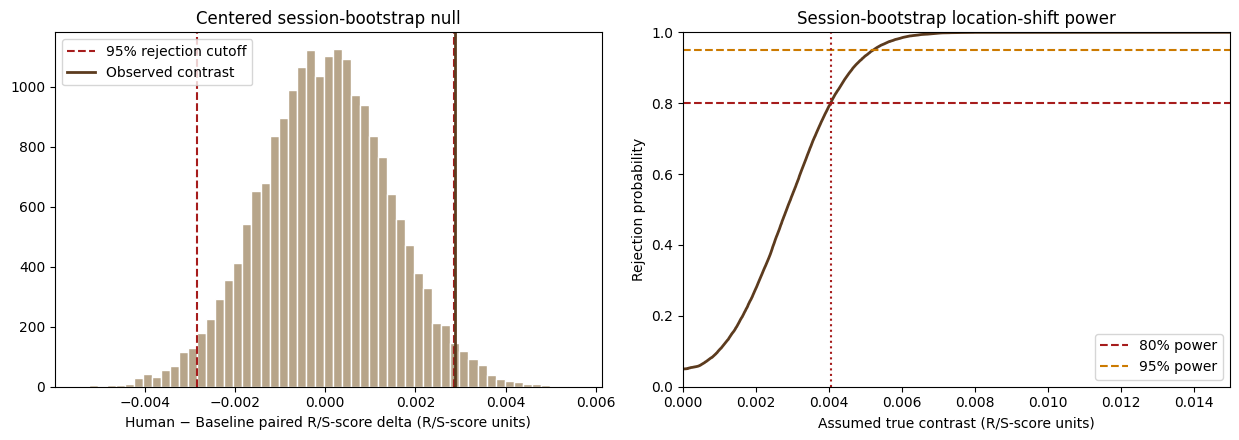


SUMMARY: PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE
Observed Human-minus-Baseline paired R/S-score delta: +0.00286867 R/S-score units
Session-bootstrap 95% CI: [+0.00001886, +0.00570694], p=0.0491
Participant-sensitivity 95% CI: [+0.00006060, +0.00558855], p=0.0458
Block-independent Welch MDE80: 0.00414323 R/S-score units
Session-cluster bootstrap MDE80: 0.00405000 R/S-score units
Participant-sensitivity MDE80: 0.00393500 R/S-score units
Reproducibility: seed=20260806; bootstrap replicates=20,000; Python=3.12.13; NumPy=2.0.2; pandas=2.2.2; SciPy=1.16.3


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Minimum Detectable Effect — Block-Level Paired R/S-Score Delta
# ═══════════════════════════════════════════════════════════════════════════
# Estimand: mean Human (hurst_subject - hurst_pcs) minus mean Baseline
#           (hurst_subject - hurst_pcs), using eligible block-level estimates.
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 78)
print("PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE")
print("=" * 78)

ALPHA_C8 = 0.05
N_BOOT_C8 = 20_000
C8_SEED = 20260806
rng_c8 = np.random.default_rng(C8_SEED)
z_alpha_c8 = stats.norm.ppf(1 - ALPHA_C8 / 2)


def c8_cluster_components(data, metric, cluster_col):
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col)[metric].agg(["sum", "count"])
        .to_numpy(dtype=float)
    )


def c8_boot_mean(data, metric, cluster_col, n_boot=N_BOOT_C8):
    comp = c8_cluster_components(data, metric, cluster_col)
    estimate = comp[:, 0].sum() / comp[:, 1].sum()
    idx = rng_c8.integers(0, len(comp), size=(n_boot, len(comp)))
    sampled = comp[idx].sum(axis=1)
    return estimate, sampled[:, 0] / sampled[:, 1], len(comp)


def c8_shift_power(null_draws, effects, critical):
    null_draws = np.asarray(null_draws, dtype=float)
    return np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in effects])


def c8_empirical_mde(null_draws, target_power, critical, upper=0.03):
    grid = np.linspace(0, upper, 6001)
    powers = c8_shift_power(null_draws, grid, critical)
    reached = np.flatnonzero(powers >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), grid, powers


hurst_c8 = df_hurst.dropna(subset=["hurst_subject", "hurst_pcs"]).copy()
hurst_c8["hurst_delta_c8"] = hurst_c8["hurst_subject"] - hurst_c8["hurst_pcs"]
human_hurst_c8 = hurst_c8.loc[hurst_c8["condition"].eq("human")].copy()
baseline_hurst_c8 = hurst_c8.loc[hurst_c8["condition"].eq("baseline")].copy()
n_human_hurst_c8 = len(human_hurst_c8)
n_baseline_hurst_c8 = len(baseline_hurst_c8)

mean_human_hurst_delta_c8 = human_hurst_c8["hurst_delta_c8"].mean()
mean_baseline_hurst_delta_c8 = baseline_hurst_c8["hurst_delta_c8"].mean()
obs_hurst_delta_hb_c8 = mean_human_hurst_delta_c8 - mean_baseline_hurst_delta_c8

# Observed group-specific variances; no external null constant and no forced sqrt(2).
sd_human_hurst_delta_c8 = human_hurst_c8["hurst_delta_c8"].std(ddof=1)
sd_baseline_hurst_delta_c8 = baseline_hurst_c8["hurst_delta_c8"].std(ddof=1)
se_hurst_delta_hb_block_c8 = np.sqrt(
    sd_human_hurst_delta_c8**2 / n_human_hurst_c8
    + sd_baseline_hurst_delta_c8**2 / n_baseline_hurst_c8
)
mde80_hurst_delta_hb_block_c8 = (
    z_alpha_c8 + stats.norm.ppf(0.80)
) * se_hurst_delta_hb_block_c8
mde95_hurst_delta_hb_block_c8 = (
    z_alpha_c8 + stats.norm.ppf(0.95)
) * se_hurst_delta_hb_block_c8
welch_hurst_c8 = stats.ttest_ind(
    human_hurst_c8["hurst_delta_c8"], baseline_hurst_c8["hurst_delta_c8"],
    equal_var=False
)

# Session-aware sampling distribution for the block-weighted contrast.
human_hurst_est_c8, human_hurst_draws_c8, n_human_hurst_sessions_c8 = c8_boot_mean(
    human_hurst_c8, "hurst_delta_c8", "session_id"
)
baseline_hurst_est_c8, baseline_hurst_draws_c8, n_baseline_hurst_sessions_c8 = c8_boot_mean(
    baseline_hurst_c8, "hurst_delta_c8", "session_id"
)
hurst_contrast_draws_c8 = human_hurst_draws_c8 - baseline_hurst_draws_c8
hurst_session_ci_c8 = np.quantile(hurst_contrast_draws_c8, [0.025, 0.975])
hurst_session_p_c8 = min(
    1.0,
    2 * min(
        (np.sum(hurst_contrast_draws_c8 <= 0) + 1) / (N_BOOT_C8 + 1),
        (np.sum(hurst_contrast_draws_c8 >= 0) + 1) / (N_BOOT_C8 + 1),
    ),
)
hurst_null_session_c8 = hurst_contrast_draws_c8 - hurst_contrast_draws_c8.mean()
crit95_hurst_session_c8 = np.quantile(np.abs(hurst_null_session_c8), 0.95)
se_hurst_delta_hb_session_c8 = hurst_contrast_draws_c8.std(ddof=1)
mde80_hurst_delta_hb_session_c8, hurst_effect_grid_c8, hurst_power_session_c8 = c8_empirical_mde(
    hurst_null_session_c8, 0.80, crit95_hurst_session_c8
)
mde95_hurst_delta_hb_session_c8, _, _ = c8_empirical_mde(
    hurst_null_session_c8, 0.95, crit95_hurst_session_c8
)

# Human participant sensitivity; Baseline stays clustered by session.
human_hurst_part_est_c8, human_hurst_part_draws_c8, n_human_hurst_participants_c8 = c8_boot_mean(
    human_hurst_c8, "hurst_delta_c8", "participant_id"
)
hurst_part_contrast_draws_c8 = human_hurst_part_draws_c8 - baseline_hurst_draws_c8
hurst_part_ci_c8 = np.quantile(hurst_part_contrast_draws_c8, [0.025, 0.975])
hurst_part_p_c8 = min(
    1.0,
    2 * min(
        (np.sum(hurst_part_contrast_draws_c8 <= 0) + 1) / (N_BOOT_C8 + 1),
        (np.sum(hurst_part_contrast_draws_c8 >= 0) + 1) / (N_BOOT_C8 + 1),
    ),
)
hurst_null_part_c8 = hurst_part_contrast_draws_c8 - hurst_part_contrast_draws_c8.mean()
crit95_hurst_part_c8 = np.quantile(np.abs(hurst_null_part_c8), 0.95)
mde80_hurst_delta_hb_part_c8, _, _ = c8_empirical_mde(
    hurst_null_part_c8, 0.80, crit95_hurst_part_c8
)
mde95_hurst_delta_hb_part_c8, _, _ = c8_empirical_mde(
    hurst_null_part_c8, 0.95, crit95_hurst_part_c8
)

print("\nObserved estimand")
print("  Mean Human paired R/S-score delta minus mean Baseline paired R/S-score delta")
print(f"  Human blocks/sessions:    {n_human_hurst_c8:,} / {n_human_hurst_sessions_c8}")
print(f"  Baseline blocks/sessions: {n_baseline_hurst_c8:,} / {n_baseline_hurst_sessions_c8}")
print(f"  Human participant IDs:    {n_human_hurst_participants_c8}")
print(f"  Human mean R/S-score delta:    {mean_human_hurst_delta_c8:+.8f} R/S-score units")
print(f"  Baseline mean R/S-score delta: {mean_baseline_hurst_delta_c8:+.8f} R/S-score units")
print(f"  Observed contrast:         {obs_hurst_delta_hb_c8:+.8f} R/S-score units")
print(f"  Session-bootstrap 95% CI:  [{hurst_session_ci_c8[0]:+.8f}, {hurst_session_ci_c8[1]:+.8f}], p={hurst_session_p_c8:.4f}")
print(f"  Participant-sensitivity CI:[{hurst_part_ci_c8[0]:+.8f}, {hurst_part_ci_c8[1]:+.8f}], p={hurst_part_p_c8:.4f}")
print(f"  Naive block-level Welch reference: t={welch_hurst_c8.statistic:.4f}, p={welch_hurst_c8.pvalue:.4f}")

hurst_mde_table_c8 = pd.DataFrame([
    {
        "operating model": "Block-independent Welch normal approximation",
        "SE / bootstrap SD": se_hurst_delta_hb_block_c8,
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_block_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_block_c8,
    },
    {
        "operating model": "Session-cluster bootstrap location shift",
        "SE / bootstrap SD": se_hurst_delta_hb_session_c8,
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_session_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_session_c8,
    },
    {
        "operating model": "Human-participant / Baseline-session sensitivity",
        "SE / bootstrap SD": hurst_part_contrast_draws_c8.std(ddof=1),
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_part_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_part_c8,
    },
])
display(hurst_mde_table_c8.round(8))

print("\nScale and interpretation")
print(f"  Block-independent MDE80: {mde80_hurst_delta_hb_block_c8:.8f} R/S-score units "
      f"({mde80_hurst_delta_hb_block_c8*100:.4f} percentage points on the 0–1 score scale)")
print(f"  Session-cluster MDE80:   {mde80_hurst_delta_hb_session_c8:.8f} R/S-score units "
      f"({mde80_hurst_delta_hb_session_c8*100:.4f} percentage points on the 0–1 score scale)")
print("  These are not relative percentages and are not comparable numerically with")
print("  hit-probability percentage points as though the estimands shared units.")
print("  The MDE describes repeated-study rejection probability under the named")
print("  location-shift model; it is separate from the observed effect and its CI.")
print("  Here the two bootstrap intervals only narrowly exclude zero, whereas the")
print("  naive block-level Welch p-value is slightly above .05. This is a borderline,")
print("  analysis-method-sensitive result, not a categorical positive or null finding.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].hist(hurst_null_session_c8, bins=55, color="#b7a58a", edgecolor="white")
axes[0].axvline(-crit95_hurst_session_c8, color="#a61c1c", linestyle="--")
axes[0].axvline(crit95_hurst_session_c8, color="#a61c1c", linestyle="--",
                label="95% rejection cutoff")
axes[0].axvline(obs_hurst_delta_hb_c8, color="#5c3b1e", linewidth=2,
                label="Observed contrast")
axes[0].set(title="Centered session-bootstrap null", xlabel="Human − Baseline paired R/S-score delta (R/S-score units)")
axes[0].legend()

axes[1].plot(hurst_effect_grid_c8, hurst_power_session_c8, color="#5c3b1e", linewidth=2)
axes[1].axhline(0.80, color="#a61c1c", linestyle="--", label="80% power")
axes[1].axhline(0.95, color="#cc7a00", linestyle="--", label="95% power")
axes[1].axvline(mde80_hurst_delta_hb_session_c8, color="#a61c1c", linestyle=":")
axes[1].set(title="Session-bootstrap location-shift power",
            xlabel="Assumed true contrast (R/S-score units)", ylabel="Rejection probability",
            xlim=(0, 0.015), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 78)
print("SUMMARY: PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE")
print("=" * 78)
print(f"Observed Human-minus-Baseline paired R/S-score delta: {obs_hurst_delta_hb_c8:+.8f} R/S-score units")
print(f"Session-bootstrap 95% CI: [{hurst_session_ci_c8[0]:+.8f}, {hurst_session_ci_c8[1]:+.8f}], p={hurst_session_p_c8:.4f}")
print(f"Participant-sensitivity 95% CI: [{hurst_part_ci_c8[0]:+.8f}, {hurst_part_ci_c8[1]:+.8f}], p={hurst_part_p_c8:.4f}")
print(f"Block-independent Welch MDE80: {mde80_hurst_delta_hb_block_c8:.8f} R/S-score units")
print(f"Session-cluster bootstrap MDE80: {mde80_hurst_delta_hb_session_c8:.8f} R/S-score units")
print(f"Participant-sensitivity MDE80: {mde80_hurst_delta_hb_part_c8:.8f} R/S-score units")
print(f"Reproducibility: seed={C8_SEED}; bootstrap replicates={N_BOOT_C8:,}; "
      f"Python={platform.python_version()}; NumPy={np.__version__}; "
      f"pandas={pd.__version__}; SciPy={scipy.__version__}")


### Baseline Raw-Call Positional and Assignment-Bit Diagnostics

This cell estimates a prespecified family of seven diagnostics in the retained Baseline raw calls:

1. assignment-bit prevalence minus 0.5;
2. physical-half A minus B literal-one fraction;
3. physical-half A minus B single-scale R/S ordering score;
4. within-session associations of bit 0 with each half's literal-one fraction and ordering score.

Point estimates are block-weighted. Confidence intervals resample whole sessions, and null tests use
whole-session sign flips. Holm adjustment controls the seven-test primary family. Detectable-effect
values are simulation-based location-shift approximations under the observed Baseline session geometry.

Baseline is the primary cohort. Condition- and provider-stratified estimates are descriptive
sensitivities: provider may be confounded with date, software, session, or acquisition regime, and
sparse provider recording cannot establish provider invariance.

These are selected diagnostics of recorded calls, not proof of physical-hardware identity or exclusion
of every positional artifact. Position-wise, boundary, cross-lag, nonlinear, and time-varying structure
requires separately calibrated analyses rather than an open-ended search in this cell.


In [14]:
# Baseline Raw-Call Positional and Assignment-Bit Diagnostics
print("=" * 84)
print("BASELINE RAW-CALL POSITIONAL AND ASSIGNMENT-BIT DIAGNOSTICS")
print("=" * 84)

N_BOOT_C9 = 20_000
N_PERM_C9 = 20_000
C9_SEED = 20260809
ALPHA_C9 = 0.05
rng_c9 = np.random.default_rng(C9_SEED)

# The authoritative loader has already validated all 301-bit strings, hashes, key
# cardinality, retained-call coverage, and Subject/PCS reconstruction. Reassert the
# Cell-9 cohort boundary without reopening or independently filtering the raw artifact.
baseline_c9 = baseline_raw_calls.merge(
    df[["session_id", "block_idx", "condition"]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one",
    suffixes=("_raw", "_analysis")
).copy()
assert len(baseline_c9) == len(base_df) == 3090
assert baseline_c9["session_id"].nunique() == base_df["session_id"].nunique()
assert baseline_c9["condition_analysis"].eq("baseline").all()
assert not baseline_c9.duplicated(["session_id", "block_idx"]).any()

baseline_c9["one_A"] = baseline_c9["halfA"].apply(np.mean)
baseline_c9["one_B"] = baseline_c9["halfB"].apply(np.mean)
baseline_c9["rs_A"] = baseline_c9["halfA"].apply(hurstApprox)
baseline_c9["rs_B"] = baseline_c9["halfB"].apply(hurstApprox)
baseline_c9["bit0_centered"] = baseline_c9["bit0"] - 0.5
baseline_c9["one_A_minus_B"] = baseline_c9["one_A"] - baseline_c9["one_B"]
baseline_c9["rs_A_minus_B"] = baseline_c9["rs_A"] - baseline_c9["rs_B"]

def c9_cluster_location(data, value_col, n_boot=N_BOOT_C9, n_perm=N_PERM_C9):
    """Block-weighted mean; whole-session bootstrap CI and sign-flip null."""
    comp = (data[["session_id", value_col]].dropna()
            .groupby("session_id")[value_col].agg(["sum", "count"]))
    sums = comp["sum"].to_numpy(float)
    counts = comp["count"].to_numpy(float)
    estimate = sums.sum() / counts.sum()
    idx = rng_c9.integers(0, len(comp), size=(n_boot, len(comp)))
    draws = sums[idx].sum(axis=1) / counts[idx].sum(axis=1)
    signs = rng_c9.choice((-1.0, 1.0), size=(n_perm, len(comp)))
    null = (signs * sums).sum(axis=1) / counts.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(estimate)) + 1) / (n_perm + 1)
    return estimate, np.quantile(draws, [0.025, 0.975]), p, null, len(comp)

def c9_within_session_slope(data, outcome_col, n_boot=N_BOOT_C9, n_perm=N_PERM_C9):
    """Within-session bit0 coefficient with session bootstrap and score sign flip."""
    work = data[["session_id", "bit0", outcome_col]].dropna().copy()
    work["x"] = work["bit0"] - work.groupby("session_id")["bit0"].transform("mean")
    work["y"] = work[outcome_col] - work.groupby("session_id")[outcome_col].transform("mean")
    work["num"] = work["x"] * work["y"]
    work["den"] = work["x"] ** 2
    comp = work.groupby("session_id")[["num", "den"]].sum()
    comp = comp.loc[comp["den"] > 0]
    nums, dens = comp["num"].to_numpy(float), comp["den"].to_numpy(float)
    estimate = nums.sum() / dens.sum()
    idx = rng_c9.integers(0, len(comp), size=(n_boot, len(comp)))
    draws = nums[idx].sum(axis=1) / dens[idx].sum(axis=1)
    signs = rng_c9.choice((-1.0, 1.0), size=(n_perm, len(comp)))
    null = (signs * nums).sum(axis=1) / dens.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(estimate)) + 1) / (n_perm + 1)
    return estimate, np.quantile(draws, [0.025, 0.975]), p, null, len(comp)

def c9_holm(pvalues):
    pvalues = np.asarray(pvalues, float)
    order = np.argsort(pvalues)
    adjusted_sorted = np.maximum.accumulate((len(pvalues) - np.arange(len(pvalues))) * pvalues[order])
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

def c9_shift_mde(null_draws, target_power=0.80):
    """Smallest positive location shift reaching target two-sided rejection power."""
    null_draws = np.asarray(null_draws, float)
    critical = np.quantile(np.abs(null_draws), 1 - ALPHA_C9)
    upper = max(critical * 6, 1e-6)
    grid = np.linspace(0, upper, 4001)
    power = np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in grid])
    reached = np.flatnonzero(power >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), critical

primary_specs_c9 = [
    ("Assignment P(bit0=1) - 0.5", "location", "bit0_centered", "probability"),
    ("Half A - B literal-one fraction", "location", "one_A_minus_B", "probability"),
    ("Half A - B R/S ordering score", "location", "rs_A_minus_B", "H-scale score"),
    ("bit0 association: half A one fraction", "slope", "one_A", "probability"),
    ("bit0 association: half B one fraction", "slope", "one_B", "probability"),
    ("bit0 association: half A R/S score", "slope", "rs_A", "H-scale score"),
    ("bit0 association: half B R/S score", "slope", "rs_B", "H-scale score"),
]

rows_c9 = []
for label, method, column, units in primary_specs_c9:
    result = (c9_cluster_location(baseline_c9, column) if method == "location"
              else c9_within_session_slope(baseline_c9, column))
    estimate, ci, p_raw, null, n_sessions = result
    mde80, critical = c9_shift_mde(null)
    rows_c9.append({
        "estimand": label, "estimate": estimate, "ci_low": ci[0], "ci_high": ci[1],
        "raw_p": p_raw, "MDE80": mde80, "units": units,
        "sessions": n_sessions, "null_critical_95": critical,
    })

primary_c9 = pd.DataFrame(rows_c9)
primary_c9["holm_p"] = c9_holm(primary_c9["raw_p"])
primary_c9["clear_after_holm"] = primary_c9["holm_p"] < ALPHA_C9

print(f"\nRetained Baseline raw calls: {len(baseline_c9):,} blocks in "
      f"{baseline_c9['session_id'].nunique()} sessions")
print("All retained calls were reconciled and reconstructed by the authoritative setup.")
print("\nPrimary family (seven tests; Holm family-wise adjustment)")
display(primary_c9[["estimand", "estimate", "ci_low", "ci_high", "raw_p", "holm_p",
                    "MDE80", "units", "sessions", "clear_after_holm"]].round(8))

# Provider provenance: require within-session consistency and report sparse strata
# descriptively. This does not identify a provider effect or provider invariance.
provider_lookup_c9 = df_blocks_norm[["session_id", "block_idx", "qrng_source"]].copy()
baseline_provider_c9 = baseline_c9.merge(
    provider_lookup_c9, on=["session_id", "block_idx"], how="left", validate="one_to_one"
)
provider_consistency_c9 = baseline_provider_c9.groupby("session_id")["qrng_source"].nunique(dropna=True)
assert (provider_consistency_c9 <= 1).all(), "qrng_source changes within a Baseline session"
baseline_provider_c9["createdAt_dt"] = pd.to_datetime(baseline_provider_c9["createdAt"], errors="coerce", utc=True)

provider_rows_c9 = []
for provider, sub in baseline_provider_c9.groupby("qrng_source", dropna=False):
    provider_rows_c9.append({
        "provider": "missing" if pd.isna(provider) else str(provider),
        "blocks": len(sub), "sessions": sub["session_id"].nunique(),
        "first_session": sub["createdAt_dt"].min(), "last_session": sub["createdAt_dt"].max(),
        "assignment_deviation": sub["bit0_centered"].mean(),
        "A_minus_B_one_fraction": sub["one_A_minus_B"].mean(),
        "A_minus_B_RS_score": sub["rs_A_minus_B"].mean(),
    })
provider_table_c9 = pd.DataFrame(provider_rows_c9)
print("\nProvider-stratified descriptive sensitivity")
display(provider_table_c9)
print("Provider comparisons are not inferential here: strata with few sessions are poorly resolved,")
print("and provider can be confounded with date, software, session, and acquisition regime.")

# All-condition descriptive sensitivity using the same physical-position metrics.
all_c9 = df_raw_calls_with_session.merge(
    df[["session_id", "block_idx", "condition"]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one",
    suffixes=("_raw", "_analysis")
).copy()
all_c9["one_A_minus_B"] = all_c9["halfA"].apply(np.mean) - all_c9["halfB"].apply(np.mean)
all_c9["rs_A_minus_B"] = all_c9["halfA"].apply(hurstApprox) - all_c9["halfB"].apply(hurstApprox)
all_c9["bit0_centered"] = all_c9["bit0"] - 0.5
condition_rows_c9 = []
for condition, sub in all_c9.groupby("condition_analysis"):
    for label, column in [
        ("assignment deviation", "bit0_centered"),
        ("A-B one fraction", "one_A_minus_B"),
        ("A-B R/S score", "rs_A_minus_B"),
    ]:
        est, ci, _, _, n_sessions = c9_cluster_location(sub, column)
        condition_rows_c9.append({"condition": condition, "estimand": label,
                                  "estimate": est, "ci_low": ci[0], "ci_high": ci[1],
                                  "blocks": len(sub), "sessions": n_sessions})
condition_sensitivity_c9 = pd.DataFrame(condition_rows_c9)
print("\nAll-condition descriptive sensitivity (session-bootstrap intervals; no new test family)")
display(condition_sensitivity_c9.round(8))

print("\nInterpretation boundary")
if primary_c9["clear_after_holm"].any():
    print("At least one selected diagnostic remained clear after Holm adjustment; inspect the table.")
else:
    print("No selected primary diagnostic was clear after Holm adjustment at alpha=.05.")
print("This is not an equivalence result and does not prove zero asymmetry.")
print("MDE80 values are approximate location shifts yielding 80% rejection probability under")
print("the observed session-preserving null geometry; they are not confidence bounds.")
print("Untested here: position-wise maxima, half-boundary transitions, cross-lag/nonlinear")
print("dependence, and time-varying positional effects. Those require prespecified calibration.")
print(f"Reproducibility: seed={C9_SEED}; bootstrap={N_BOOT_C9:,}; permutations={N_PERM_C9:,}")


BASELINE RAW-CALL POSITIONAL AND ASSIGNMENT-BIT DIAGNOSTICS

Retained Baseline raw calls: 3,090 blocks in 103 sessions
All retained calls were reconciled and reconstructed by the authoritative setup.

Primary family (seven tests; Holm family-wise adjustment)


,estimand,estimate,ci_low,ci_high,raw_p,holm_p,MDE80,units,sessions,clear_after_holm
0,Assignment P(bit0=1) - 0.5,0.013592,-0.005178,0.032686,0.176841,1.0,0.027845,probability,103,False
1,Half A - B literal-one fraction,-0.000705,-0.002529,0.001109,0.458127,1.0,0.002633,probability,103,False
2,Half A - B R/S ordering score,-0.000682,-0.003008,0.001722,0.576071,1.0,0.003393,H-scale score,103,False
3,bit0 association: half A one fraction,-0.000102,-0.003010,0.002814,0.944103,1.0,0.004191,probability,103,False
4,bit0 association: half B one fraction,0.000016,-0.002638,0.002714,0.989251,1.0,0.003819,probability,103,False
5,bit0 association: half A R/S score,-0.001427,-0.004368,0.001490,0.341283,1.0,0.004187,H-scale score,103,False
6,bit0 association: half B R/S score,0.001907,-0.001096,0.004949,0.227639,1.0,0.004384,H-scale score,103,False



Provider-stratified descriptive sensitivity


,provider,blocks,sessions,first_session,last_session,assignment_deviation,A_minus_B_one_fraction,A_minus_B_RS_score
0,lfdr,330,11,2025-12-23 22:27:08.373000+00:00,2025-12-23 22:49:59.030000+00:00,0.045455,-0.002990,-0.006754
1,qrng-race,2760,92,2025-10-17 22:53:10.844000+00:00,2026-01-29 20:03:44.578000+00:00,0.009783,-0.000432,0.000045


Provider comparisons are not inferential here: strata with few sessions are poorly resolved,
and provider can be confounded with date, software, session, and acquisition regime.

All-condition descriptive sensitivity (session-bootstrap intervals; no new test family)


,condition,estimand,estimate,ci_low,ci_high,blocks,sessions
0,ai_agent,assignment deviation,0.007937,-0.010317,0.026455,3780,126
1,ai_agent,A-B one fraction,-0.000111,-0.001825,0.001610,3780,126
2,ai_agent,A-B R/S score,0.000251,-0.001625,0.002148,3780,126
3,baseline,assignment deviation,0.013592,-0.005502,0.032362,3090,103
4,baseline,A-B one fraction,-0.000705,-0.002550,0.001107,3090,103
5,baseline,A-B R/S score,-0.000682,-0.003071,0.001707,3090,103
6,human,assignment deviation,-0.004539,-0.018683,0.009705,4737,158
7,human,A-B one fraction,0.000518,-0.001203,0.002219,4737,158
8,human,A-B R/S score,0.001439,-0.000356,0.003288,4737,158



Interpretation boundary
No selected primary diagnostic was clear after Holm adjustment at alpha=.05.
This is not an equivalence result and does not prove zero asymmetry.
MDE80 values are approximate location shifts yielding 80% rejection probability under
the observed session-preserving null geometry; they are not confidence bounds.
Untested here: position-wise maxima, half-boundary transitions, cross-lag/nonlinear
dependence, and time-varying positional effects. Those require prespecified calibration.
Reproducibility: seed=20260809; bootstrap=20,000; permutations=20,000


### Hit-Count Dispersion and Discrete-Tail Diagnostics

**Paper section: 3.1 (bounded PCS calibration diagnostics)**

This section describes PCS hit counts under the retained acquisition regime and compares them with a Binomial(150, 0.5) reference. The binomial model is a reference conditional on 150 trials, hit probability 0.5, and within-block independence; it is not a general test of randomness or hardware validity.

Point estimates are block weighted. Uncertainty is obtained by resampling whole sessions. Tail events are defined on integer hit counts so the observed and reference events are identical. Condition summaries are descriptive; no block-independent Levene or chi-square test is used.


HIT-COUNT DISPERSION AND DISCRETE-TAIL DIAGNOSTICS
Blocks / sessions: 11,607 / 387
Observed hit-count variance: 37.27118
Binomial(150, .5) reference variance: 37.50000
Dispersion ratio: 0.99390
Whole-session bootstrap 95% CI: [0.96973, 1.01834]

Selected discrete tail events (whole-session bootstrap intervals)


,event,observed,ci_low,ci_high,binomial_reference,observed_count
0,hits <= 60,0.008702,0.007065,0.010425,0.008799,101
1,hits >= 90,0.008874,0.007237,0.010594,0.008799,103
2,hits <= 60 or >= 90,0.017576,0.015336,0.019902,0.017598,204



Condition summaries (descriptive; no independent-block variance test)


,condition,blocks,sessions,mean_hits,variance_hits,dispersion_ratio
0,ai_agent,3780,126,75.00899,37.52942,1.00078
1,baseline,3090,103,74.99676,38.39882,1.02397
2,human,4737,158,75.08782,36.34110,0.96910


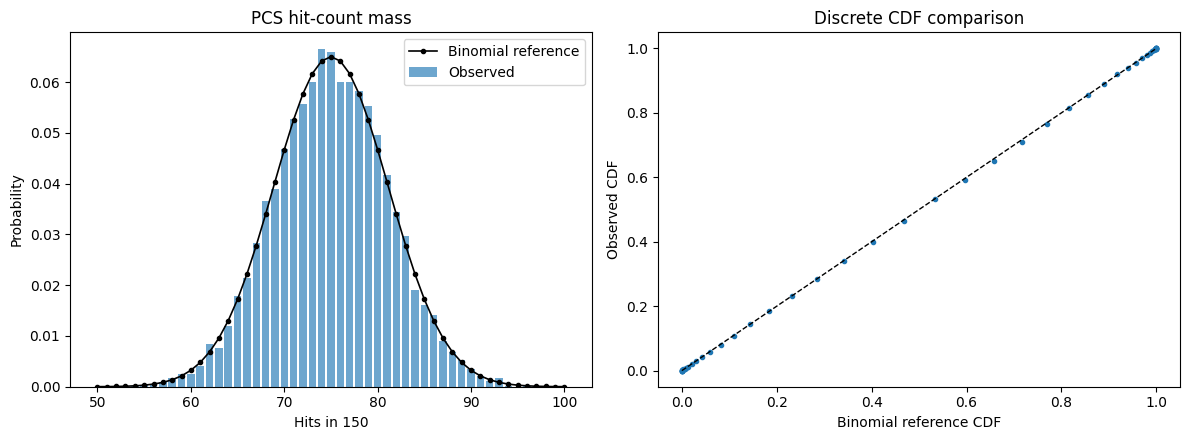


Interpretation boundary
The dispersion interval and selected tail summaries quantify agreement with a
specific Binomial(150, .5) reference. They do not establish within-block
independence, normality, universal tail behavior, or hardware validity.
Reproducibility: seed=20260812; bootstrap replicates=10,000


In [15]:
# HIT-COUNT DISPERSION AND DISCRETE-TAIL DIAGNOSTICS
from scipy import stats
import matplotlib.pyplot as plt

print("=" * 78)
print("HIT-COUNT DISPERSION AND DISCRETE-TAIL DIAGNOSTICS")
print("=" * 78)

N_TRIALS_C12 = 150
P_REF_C12 = 0.5
N_BOOT_C12 = 10_000
C12_SEED = 20260812
rng_c12 = np.random.default_rng(C12_SEED)

c12 = df[["session_id", "condition", "pcs_hit_rate"]].dropna().copy()
c12["pcs_hits"] = np.rint(c12["pcs_hit_rate"] * N_TRIALS_C12).astype(int)
assert ((c12["pcs_hits"] >= 0) & (c12["pcs_hits"] <= N_TRIALS_C12)).all()
assert np.allclose(c12["pcs_hits"] / N_TRIALS_C12, c12["pcs_hit_rate"])

ref_var_hits_c12 = N_TRIALS_C12 * P_REF_C12 * (1 - P_REF_C12)
obs_var_hits_c12 = c12["pcs_hits"].var(ddof=1)
dispersion_c12 = obs_var_hits_c12 / ref_var_hits_c12

session_arrays_c12 = [g["pcs_hits"].to_numpy() for _, g in c12.groupby("session_id")]
boot_disp_c12 = np.empty(N_BOOT_C12)
for b in range(N_BOOT_C12):
    idx = rng_c12.integers(0, len(session_arrays_c12), len(session_arrays_c12))
    vals = np.concatenate([session_arrays_c12[i] for i in idx])
    boot_disp_c12[b] = vals.var(ddof=1) / ref_var_hits_c12
disp_ci_c12 = np.quantile(boot_disp_c12, [0.025, 0.975])

print(f"Blocks / sessions: {len(c12):,} / {c12['session_id'].nunique()}")
print(f"Observed hit-count variance: {obs_var_hits_c12:.5f}")
print(f"Binomial(150, .5) reference variance: {ref_var_hits_c12:.5f}")
print(f"Dispersion ratio: {dispersion_c12:.5f}")
print(f"Whole-session bootstrap 95% CI: [{disp_ci_c12[0]:.5f}, {disp_ci_c12[1]:.5f}]")

# Integer-count tail events. These are prespecified descriptive cutoffs, not an omnibus tail test.
tail_specs_c12 = [
    ("hits <= 60", lambda x: x <= 60, stats.binom.cdf(60, N_TRIALS_C12, P_REF_C12)),
    ("hits >= 90", lambda x: x >= 90, stats.binom.sf(89, N_TRIALS_C12, P_REF_C12)),
    ("hits <= 60 or >= 90", lambda x: (x <= 60) | (x >= 90),
     stats.binom.cdf(60, N_TRIALS_C12, P_REF_C12) + stats.binom.sf(89, N_TRIALS_C12, P_REF_C12)),
]
tail_rows_c12 = []
for label, event, p_ref in tail_specs_c12:
    c12["event_tmp"] = event(c12["pcs_hits"].to_numpy()).astype(float)
    obs = c12["event_tmp"].mean()
    by_session = [g["event_tmp"].to_numpy() for _, g in c12.groupby("session_id")]
    draws = np.empty(N_BOOT_C12)
    for b in range(N_BOOT_C12):
        idx = rng_c12.integers(0, len(by_session), len(by_session))
        vals = np.concatenate([by_session[i] for i in idx])
        draws[b] = vals.mean()
    lo, hi = np.quantile(draws, [0.025, 0.975])
    tail_rows_c12.append({"event": label, "observed": obs, "ci_low": lo,
                          "ci_high": hi, "binomial_reference": p_ref,
                          "observed_count": int(c12["event_tmp"].sum())})
c12.drop(columns="event_tmp", inplace=True)
tail_table_c12 = pd.DataFrame(tail_rows_c12)
print("\nSelected discrete tail events (whole-session bootstrap intervals)")
display(tail_table_c12.round(7))

condition_disp_c12 = []
for condition, sub in c12.groupby("condition"):
    condition_disp_c12.append({
        "condition": condition, "blocks": len(sub),
        "sessions": sub["session_id"].nunique(),
        "mean_hits": sub["pcs_hits"].mean(),
        "variance_hits": sub["pcs_hits"].var(ddof=1),
        "dispersion_ratio": sub["pcs_hits"].var(ddof=1) / ref_var_hits_c12,
    })
condition_disp_c12 = pd.DataFrame(condition_disp_c12)
print("\nCondition summaries (descriptive; no independent-block variance test)")
display(condition_disp_c12.round(5))

# Discrete observed-versus-reference diagnostics.
support_c12 = np.arange(N_TRIALS_C12 + 1)
obs_counts_c12 = np.bincount(c12["pcs_hits"], minlength=N_TRIALS_C12 + 1)
obs_prob_c12 = obs_counts_c12 / obs_counts_c12.sum()
ref_prob_c12 = stats.binom.pmf(support_c12, N_TRIALS_C12, P_REF_C12)
obs_cdf_c12 = np.cumsum(obs_prob_c12)
ref_cdf_c12 = stats.binom.cdf(support_c12, N_TRIALS_C12, P_REF_C12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mask = (support_c12 >= 50) & (support_c12 <= 100)
axes[0].bar(support_c12[mask], obs_prob_c12[mask], alpha=.65, label="Observed")
axes[0].plot(support_c12[mask], ref_prob_c12[mask], color="black", marker="o",
             markersize=3, linewidth=1.2, label="Binomial reference")
axes[0].set(title="PCS hit-count mass", xlabel="Hits in 150", ylabel="Probability")
axes[0].legend()
axes[1].plot(ref_cdf_c12[mask], obs_cdf_c12[mask], marker=".", linestyle="none")
lo = min(ref_cdf_c12[mask].min(), obs_cdf_c12[mask].min())
hi = max(ref_cdf_c12[mask].max(), obs_cdf_c12[mask].max())
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set(title="Discrete CDF comparison", xlabel="Binomial reference CDF", ylabel="Observed CDF")
plt.tight_layout(); plt.show()

print("\nInterpretation boundary")
print("The dispersion interval and selected tail summaries quantify agreement with a")
print("specific Binomial(150, .5) reference. They do not establish within-block")
print("independence, normality, universal tail behavior, or hardware validity.")
print(f"Reproducibility: seed={C12_SEED}; bootstrap replicates={N_BOOT_C12:,}")


### Same-Position Bit-Level Coupling Diagnostics

**Paper section: 3.2.5 (bounded observed-data coupling analysis)**

This section asks whether the reconstructed Subject and PCS bits show excess **same-position** plug-in mutual information. The alignment is position 1 with position 1 through position 150 with position 150 within the same retained call; it does not cover cross-lag, nonlinear, cross-call, or assignment-bit coupling.

Finite-sample and marginal-composition bias are calibrated within each block by circularly shifting the PCS sequence through all nonzero offsets. This preserves each stream's bits and circular autocorrelation while breaking the recorded same-position alignment. Session-level sign flips and whole-session bootstrap intervals preserve the acquisition hierarchy. Entropy is reported only as context, not as an independent confirmation of coupling.


SAME-POSITION BIT-LEVEL COUPLING DIAGNOSTICS
Blocks / sessions: 11,607 / 387
Mean Subject entropy: 0.995163 bits
Mean PCS entropy: 0.995205 bits
Mean same-position plug-in MI: 0.004672 bits
Mean within-block circular-shift reference: 0.004856 bits
Mean excess same-position MI: -0.000184 bits
Whole-session bootstrap 95% CI: [-0.000299, -0.000069]
Whole-session sign-flip p-value: 0.0018

Condition summaries (descriptive; no condition-effect test)


,condition,blocks,sessions,mean_observed_mi,mean_shift_reference,mean_excess_mi
0,ai_agent,3780,126,0.004731,0.004849,-0.000118
1,baseline,3090,103,0.004716,0.004859,-0.000143
2,human,4737,158,0.004597,0.004860,-0.000262


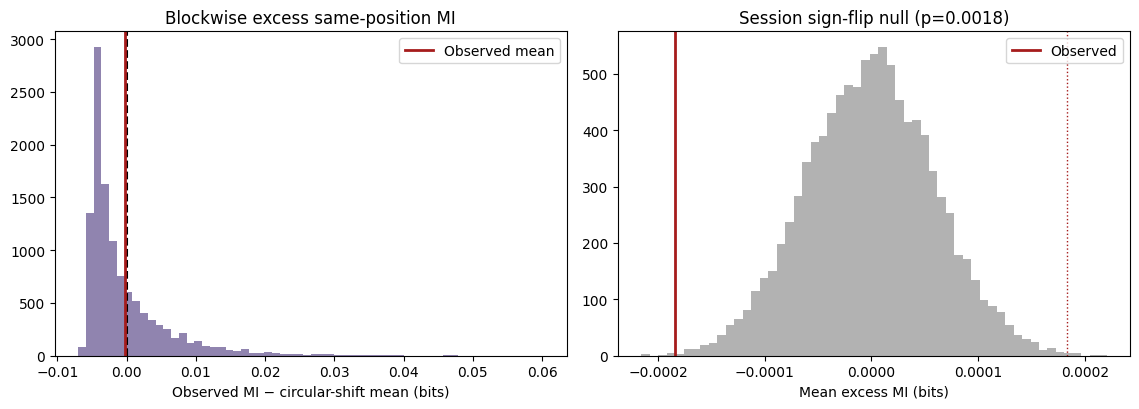


Interpretation boundary
This analysis estimates excess same-position plug-in MI relative to a
within-block circular-shift reference. It does not establish complete
informational independence or exclude cross-lag, nonlinear, cross-call,
assignment-bit, or weak effects below this analysis's resolution.
Reproducibility: seed=20260813; permutations=10,000; bootstrap=10,000


In [16]:
# SAME-POSITION BIT-LEVEL COUPLING DIAGNOSTICS
import matplotlib.pyplot as plt

print("=" * 78)
print("SAME-POSITION BIT-LEVEL COUPLING DIAGNOSTICS")
print("=" * 78)

N_PERM_C13 = 10_000
N_BOOT_C13 = 10_000
C13_SEED = 20260813
rng_c13 = np.random.default_rng(C13_SEED)

bits_subject_c13 = np.stack(df["subject_bits"].map(lambda x: np.asarray(x, dtype=np.int8)))
pcs_col_c13 = "pcs_bits" if "pcs_bits" in df.columns else "demon_bits"
bits_pcs_c13 = np.stack(df[pcs_col_c13].map(lambda x: np.asarray(x, dtype=np.int8)))
assert bits_subject_c13.shape == bits_pcs_c13.shape
assert bits_subject_c13.shape[1] == 150

def c13_binary_entropy_prob(p):
    p = np.asarray(p, float)
    out = np.zeros_like(p)
    valid = (p > 0) & (p < 1)
    out[valid] = -(p[valid] * np.log2(p[valid]) +
                   (1 - p[valid]) * np.log2(1 - p[valid]))
    return out

def c13_mi_from_n11(n11, n1x, nx1, n):
    n11 = np.asarray(n11, float)
    cells = np.stack([n - n1x - nx1 + n11, nx1 - n11, n1x - n11, n11], axis=-1) / n
    px = np.stack([1 - n1x / n, n1x / n], axis=-1)
    py = np.stack([1 - nx1 / n, nx1 / n], axis=-1)
    expected = np.stack([px[..., 0] * py[..., 0], px[..., 0] * py[..., 1],
                         px[..., 1] * py[..., 0], px[..., 1] * py[..., 1]], axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(cells > 0, cells * np.log2(cells / expected), 0.0)
    return terms.sum(axis=-1)

n_c13 = bits_subject_c13.shape[1]
n1x_c13 = bits_subject_c13.sum(axis=1)
nx1_c13 = bits_pcs_c13.sum(axis=1)
n11_obs_c13 = (bits_subject_c13 * bits_pcs_c13).sum(axis=1)
mi_obs_c13 = c13_mi_from_n11(n11_obs_c13, n1x_c13, nx1_c13, n_c13)

# Enumerate all nonzero circular offsets efficiently. Each row's shift-null mean
# calibrates its own margins and circular temporal structure.
mi_shift_c13 = np.empty((len(df), n_c13 - 1), dtype=np.float32)
for shift in range(1, n_c13):
    n11 = (bits_subject_c13 * np.roll(bits_pcs_c13, shift, axis=1)).sum(axis=1)
    mi_shift_c13[:, shift - 1] = c13_mi_from_n11(n11, n1x_c13, nx1_c13, n_c13)
mi_null_mean_c13 = mi_shift_c13.mean(axis=1)
mi_excess_c13 = mi_obs_c13 - mi_null_mean_c13

c13 = df[["session_id", "condition"]].copy()
c13["subject_entropy"] = c13_binary_entropy_prob(n1x_c13 / n_c13)
c13["pcs_entropy"] = c13_binary_entropy_prob(nx1_c13 / n_c13)
c13["mi_observed"] = mi_obs_c13
c13["mi_shift_reference"] = mi_null_mean_c13
c13["mi_excess"] = mi_excess_c13

session_c13 = c13.groupby("session_id", as_index=False).agg(
    mi_excess_sum=("mi_excess", "sum"), n_blocks=("mi_excess", "size"))
estimate_c13 = session_c13["mi_excess_sum"].sum() / session_c13["n_blocks"].sum()
signs = rng_c13.choice((-1.0, 1.0), size=(N_PERM_C13, len(session_c13)))
null_c13 = (signs * session_c13["mi_excess_sum"].to_numpy()).sum(axis=1) / session_c13["n_blocks"].sum()
p_c13 = (np.count_nonzero(np.abs(null_c13) >= abs(estimate_c13)) + 1) / (N_PERM_C13 + 1)
idx = rng_c13.integers(0, len(session_c13), size=(N_BOOT_C13, len(session_c13)))
boot_num = session_c13["mi_excess_sum"].to_numpy()[idx].sum(axis=1)
boot_den = session_c13["n_blocks"].to_numpy()[idx].sum(axis=1)
boot_c13 = boot_num / boot_den
ci_c13 = np.quantile(boot_c13, [0.025, 0.975])

print(f"Blocks / sessions: {len(c13):,} / {len(session_c13)}")
print(f"Mean Subject entropy: {c13['subject_entropy'].mean():.6f} bits")
print(f"Mean PCS entropy: {c13['pcs_entropy'].mean():.6f} bits")
print(f"Mean same-position plug-in MI: {c13['mi_observed'].mean():.6f} bits")
print(f"Mean within-block circular-shift reference: {c13['mi_shift_reference'].mean():.6f} bits")
print(f"Mean excess same-position MI: {estimate_c13:+.6f} bits")
print(f"Whole-session bootstrap 95% CI: [{ci_c13[0]:+.6f}, {ci_c13[1]:+.6f}]")
print(f"Whole-session sign-flip p-value: {p_c13:.4f}")

condition_c13 = c13.groupby("condition", as_index=False).agg(
    blocks=("mi_excess", "size"), sessions=("session_id", "nunique"),
    mean_observed_mi=("mi_observed", "mean"),
    mean_shift_reference=("mi_shift_reference", "mean"),
    mean_excess_mi=("mi_excess", "mean"))
print("\nCondition summaries (descriptive; no condition-effect test)")
display(condition_c13.round(7))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(c13["mi_excess"], bins=60, color="#6b5b95", alpha=.75)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].axvline(estimate_c13, color="#a61c1c", linewidth=2, label="Observed mean")
axes[0].set(title="Blockwise excess same-position MI", xlabel="Observed MI − circular-shift mean (bits)")
axes[0].legend()
axes[1].hist(null_c13, bins=55, color="#999999", alpha=.75)
axes[1].axvline(estimate_c13, color="#a61c1c", linewidth=2, label="Observed")
axes[1].axvline(-estimate_c13, color="#a61c1c", linewidth=1, linestyle=":")
axes[1].set(title=f"Session sign-flip null (p={p_c13:.4f})", xlabel="Mean excess MI (bits)")
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nInterpretation boundary")
print("This analysis estimates excess same-position plug-in MI relative to a")
print("within-block circular-shift reference. It does not establish complete")
print("informational independence or exclude cross-lag, nonlinear, cross-call,")
print("assignment-bit, or weak effects below this analysis's resolution.")
print(f"Reproducibility: seed={C13_SEED}; permutations={N_PERM_C13:,}; bootstrap={N_BOOT_C13:,}")


### Finite-Sample Calibration of Entropy and Same-Position Mutual Information

This simulation calibrates the estimators used in the preceding diagnostic. It is not an observed-data coupling test and does not validate latent Hurst-parameter correlations.

Binary Markov persistence is varied as a nuisance structure. Cross-stream coupling is introduced by copying the first stream's contemporaneous bit with a prespecified probability; otherwise the second stream follows an independent Markov draw. Results are reported separately by mechanism with Monte Carlo uncertainty. The calibration grid is illustrative and does not exhaust nonlinear, lagged, or nonstationary dependence.


In [17]:
# FINITE-SAMPLE CALIBRATION OF ENTROPY AND SAME-POSITION MI
import numpy as np

print("=" * 82)
print("FINITE-SAMPLE CALIBRATION OF ENTROPY AND SAME-POSITION MUTUAL INFORMATION")
print("=" * 82)

C13B_SEED = 20260814
N_REPS_C13B = 4_000
N_C13B = 150
rng_c13b = np.random.default_rng(C13B_SEED)

def c13b_markov_batch(n, p_stay, reps, rng):
    out = np.empty((reps, n), np.int8)
    out[:, 0] = rng.integers(0, 2, reps)
    stay = rng.random((reps, n - 1)) < p_stay
    for j in range(1, n):
        out[:, j] = np.where(stay[:, j - 1], out[:, j - 1], 1 - out[:, j - 1])
    return out

def c13b_plugin_mi(x, y):
    n = x.shape[1]
    n1x = x.sum(axis=1); nx1 = y.sum(axis=1); n11 = (x * y).sum(axis=1)
    return c13_mi_from_n11(n11, n1x, nx1, n)

P_STAY_C13B = [0.50, 0.60, 0.70]
COPY_PROB_C13B = [0.00, 0.05, 0.10, 0.20]
rows_c13b = []
for p_stay in P_STAY_C13B:
    x = c13b_markov_batch(N_C13B, p_stay, N_REPS_C13B, rng_c13b)
    independent_y = c13b_markov_batch(N_C13B, p_stay, N_REPS_C13B, rng_c13b)
    for copy_prob in COPY_PROB_C13B:
        copy_mask = rng_c13b.random((N_REPS_C13B, N_C13B)) < copy_prob
        y = np.where(copy_mask, x, independent_y).astype(np.int8)
        mi = c13b_plugin_mi(x, y)
        # One independent nonzero circular offset per replication provides the
        # same finite-sample reference used conceptually in the observed analysis.
        shifts = rng_c13b.integers(1, N_C13B, N_REPS_C13B)
        y_shift = np.empty_like(y)
        for i, shift in enumerate(shifts):
            y_shift[i] = np.roll(y[i], shift)
        mi_shift = c13b_plugin_mi(x, y_shift)
        excess = mi - mi_shift
        rows_c13b.append({
            "p_stay": p_stay, "copy_probability": copy_prob,
            "mean_plugin_mi": mi.mean(),
            "mcse_plugin_mi": mi.std(ddof=1) / np.sqrt(N_REPS_C13B),
            "mean_shift_reference": mi_shift.mean(),
            "mean_excess_mi": excess.mean(),
            "mcse_excess_mi": excess.std(ddof=1) / np.sqrt(N_REPS_C13B),
            "sd_excess_mi": excess.std(ddof=1),
        })
calibration_c13b = pd.DataFrame(rows_c13b)
display(calibration_c13b.round(7))

print("\nInterpretation boundary")
print("At copy_probability=0, residual excess MI quantifies calibration under the")
print("modeled independent Markov streams. Positive-copy rows show mechanism-specific")
print("sensitivity, not a universal power or detection threshold. Persistence, coupling")
print("strength, and finite length all affect the plug-in estimator and its shift reference.")
print("These simulations do not establish that a null observed result makes estimator")
print("drift irrelevant, and they do not validate complete stream independence.")
print(f"Reproducibility: seed={C13B_SEED}; replications per row={N_REPS_C13B:,}")


FINITE-SAMPLE CALIBRATION OF ENTROPY AND SAME-POSITION MUTUAL INFORMATION


,p_stay,copy_probability,mean_plugin_mi,mcse_plugin_mi,mean_shift_reference,mean_excess_mi,mcse_excess_mi,sd_excess_mi
0,0.5,0.00,0.004930,0.000108,0.004623,0.000307,0.000151,0.009582
1,0.5,0.05,0.006884,0.000150,0.004855,0.002030,0.000188,0.011912
2,0.5,0.10,0.012112,0.000219,0.004855,0.007258,0.000247,0.015596
3,0.5,0.20,0.033954,0.000395,0.004791,0.029163,0.000411,0.026015
4,0.6,0.00,0.005317,0.000117,0.005348,-0.000031,0.000168,0.010592
5,0.6,0.05,0.007243,0.000154,0.005378,0.001865,0.000196,0.012418
6,0.6,0.10,0.012906,0.000231,0.005283,0.007624,0.000258,0.016324
7,0.6,0.20,0.035090,0.000397,0.005000,0.030090,0.000413,0.026126
8,0.7,0.00,0.006416,0.000144,0.006674,-0.000258,0.000208,0.013187
9,0.7,0.05,0.007999,0.000175,0.006515,0.001484,0.000227,0.014339



Interpretation boundary
At copy_probability=0, residual excess MI quantifies calibration under the
modeled independent Markov streams. Positive-copy rows show mechanism-specific
sensitivity, not a universal power or detection threshold. Persistence, coupling
strength, and finite length all affect the plug-in estimator and its shift reference.
These simulations do not establish that a null observed result makes estimator
drift irrelevant, and they do not validate complete stream independence.
Reproducibility: seed=20260814; replications per row=4,000


# Baseline Empirical Paired-Delta Reference Distribution

**Paper section: 3.2 (Relational Structure Between Streams and the empirical Baseline reference)**

This section characterizes the observed Subject–PCS relationship and paired-delta distribution in retained Baseline sessions. Baseline is an empirical hardware-and-software reference under the observed acquisition regime; it is not a universal null distribution.

Inference treats the session as the resampling unit. Same-call pairings are broken only within sessions, whole sessions are resampled for confidence intervals, and conditions are analyzed separately rather than pooled.


### Cohort and resampling specification

The section uses local views of the canonical cohort created in the setup cell. It does not reload data or overwrite shared dataframes.


In [18]:
print("=" * 84)
print("BASELINE EMPIRICAL PAIRED-DELTA REFERENCE DISTRIBUTION")
print("=" * 84)

N_BOOT_C10 = 10_000
N_PERM_C10 = 10_000
C10_SEED = 20260810

c10_data = df[[
    "session_id", "condition", "hurst_subject", "hurst_pcs", "delta_hurst",
    "subject_hit_rate", "pcs_hit_rate", "delta_hit"
]].copy()
c10_baseline = c10_data.loc[c10_data["condition"].eq("baseline")].copy()

assert len(c10_baseline) == len(base_df)
assert c10_baseline["session_id"].nunique() == base_df["session_id"].nunique()
assert not c10_baseline.duplicated(["session_id"]).all()

cohort_c10 = (
    c10_data.groupby("condition", as_index=False)
    .agg(blocks=("session_id", "size"), sessions=("session_id", "nunique"))
)
display(cohort_c10)
print(f"Resampling: {N_BOOT_C10:,} whole-session bootstrap draws and "
      f"{N_PERM_C10:,} within-session permutations; seed={C10_SEED}")


BASELINE EMPIRICAL PAIRED-DELTA REFERENCE DISTRIBUTION


,condition,blocks,sessions
0,ai_agent,3780,126
1,baseline,3090,103
2,human,4737,158


Resampling: 10,000 whole-session bootstrap draws and 10,000 within-session permutations; seed=20260810


### Analysis 1 — Same-call association diagnostic

Pearson and Spearman coefficients describe the same-call association between Subject and PCS values. Confidence intervals resample whole sessions. The permutation test breaks Subject–PCS pairing within each session while preserving session membership and each stream's within-session marginal values. A non-significant result is reported as no detected linear or rank association at the available resolution, not as proof of independence.


,condition,metric,blocks,sessions,pearson_r,pearson_ci_low,pearson_ci_high,pearson_perm_p,spearman_rho,spearman_ci_low,spearman_ci_high,spearman_perm_p
0,ai_agent,hurst_subject,3780,126,0.009875,-0.019790,0.040026,0.542646,0.014750,-0.016444,0.045877,0.361364
1,ai_agent,subject_hit_rate,3780,126,-0.006807,-0.038710,0.025040,0.693031,0.000220,-0.031894,0.031950,0.991101
2,baseline,hurst_subject,3090,103,0.003729,-0.030584,0.037118,0.835716,0.002683,-0.033017,0.037462,0.879112
3,baseline,subject_hit_rate,3090,103,0.014864,-0.024801,0.055063,0.396560,0.014267,-0.024331,0.053014,0.416758
4,human,hurst_subject,4737,158,0.010950,-0.017850,0.040607,0.441256,0.014515,-0.013488,0.043396,0.309369
5,human,subject_hit_rate,4737,158,0.023557,-0.004163,0.051480,0.094091,0.021640,-0.005833,0.048764,0.126987


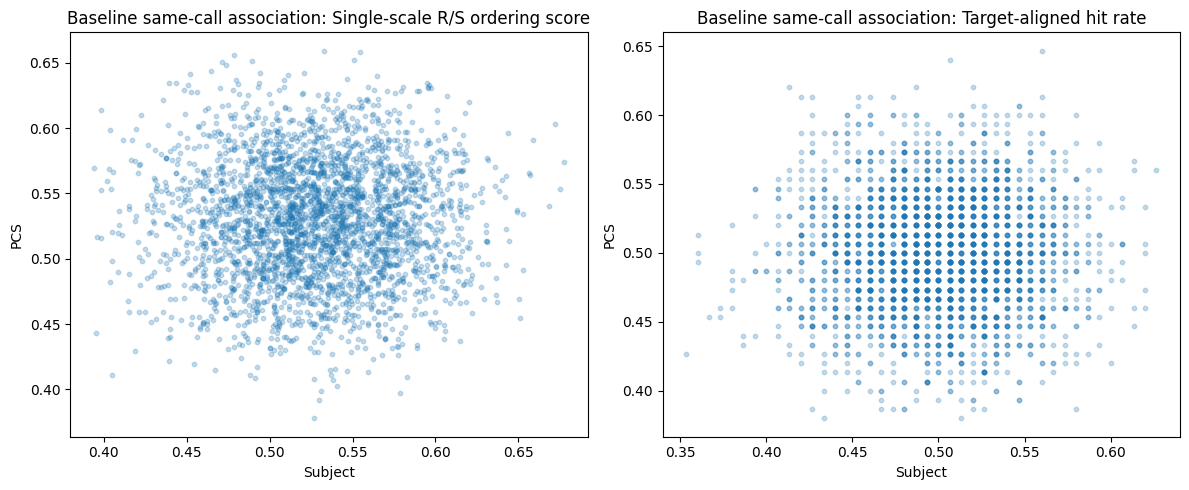

Bounded interpretation: inspect the session-bootstrap intervals and within-session
permutation p-values above. A result that does not resolve an association supports only
'no same-call linear or rank association detected at the available resolution.'


In [19]:
def c10_corr_stat(x, y, method):
    if method == "pearson":
        return stats.pearsonr(x, y).statistic
    if method == "spearman":
        return stats.spearmanr(x, y).statistic
    raise ValueError(method)

def c10_clustered_correlation(data, x_col, y_col, label, seed):
    work = data[["session_id", x_col, y_col]].dropna().copy()
    groups = [group[[x_col, y_col]].to_numpy(float)
              for _, group in work.groupby("session_id", sort=True)]
    if len(groups) < 2 or sum(len(group) for group in groups) < 10:
        return {"condition": label, "metric": x_col, "blocks": len(work),
                "sessions": len(groups), "pearson_r": np.nan,
                "pearson_ci_low": np.nan, "pearson_ci_high": np.nan,
                "pearson_perm_p": np.nan, "spearman_rho": np.nan,
                "spearman_ci_low": np.nan, "spearman_ci_high": np.nan,
                "spearman_perm_p": np.nan}

    x = work[x_col].to_numpy(float)
    y = work[y_col].to_numpy(float)
    observed = {method: c10_corr_stat(x, y, method)
                for method in ("pearson", "spearman")}
    rng_local = default_rng(seed)
    boot = {"pearson": np.empty(N_BOOT_C10), "spearman": np.empty(N_BOOT_C10)}
    for draw in range(N_BOOT_C10):
        sampled = rng_local.integers(0, len(groups), size=len(groups))
        stacked = np.concatenate([groups[index] for index in sampled], axis=0)
        for method in boot:
            boot[method][draw] = c10_corr_stat(stacked[:, 0], stacked[:, 1], method)

    perm = {"pearson": np.empty(N_PERM_C10), "spearman": np.empty(N_PERM_C10)}
    for draw in range(N_PERM_C10):
        shuffled = []
        for group in groups:
            permuted = group.copy()
            permuted[:, 1] = rng_local.permutation(permuted[:, 1])
            shuffled.append(permuted)
        stacked = np.concatenate(shuffled, axis=0)
        for method in perm:
            perm[method][draw] = c10_corr_stat(stacked[:, 0], stacked[:, 1], method)

    pearson_ci = np.quantile(boot["pearson"], [0.025, 0.975])
    spearman_ci = np.quantile(boot["spearman"], [0.025, 0.975])
    pearson_p = ((np.count_nonzero(np.abs(perm["pearson"]) >= abs(observed["pearson"])) + 1)
                 / (N_PERM_C10 + 1))
    spearman_p = ((np.count_nonzero(np.abs(perm["spearman"]) >= abs(observed["spearman"])) + 1)
                  / (N_PERM_C10 + 1))
    return {
        "condition": label, "metric": x_col, "blocks": len(work), "sessions": len(groups),
        "pearson_r": observed["pearson"], "pearson_ci_low": pearson_ci[0],
        "pearson_ci_high": pearson_ci[1], "pearson_perm_p": pearson_p,
        "spearman_rho": observed["spearman"], "spearman_ci_low": spearman_ci[0],
        "spearman_ci_high": spearman_ci[1], "spearman_perm_p": spearman_p,
    }

association_rows_c10 = []
for condition_index, (condition, subset) in enumerate(c10_data.groupby("condition", sort=True)):
    association_rows_c10.append(c10_clustered_correlation(
        subset, "hurst_subject", "hurst_pcs", condition,
        C10_SEED + 100 * condition_index + 1
    ))
    association_rows_c10.append(c10_clustered_correlation(
        subset, "subject_hit_rate", "pcs_hit_rate", condition,
        C10_SEED + 100 * condition_index + 2
    ))

association_c10 = pd.DataFrame(association_rows_c10)
display(association_c10.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, x_col, y_col, title in [
    (axes[0], "hurst_subject", "hurst_pcs", "Single-scale R/S ordering score"),
    (axes[1], "subject_hit_rate", "pcs_hit_rate", "Target-aligned hit rate"),
]:
    plot_data = c10_baseline[[x_col, y_col]].dropna()
    ax.scatter(plot_data[x_col], plot_data[y_col], alpha=0.25, s=10)
    ax.set(title=f"Baseline same-call association: {title}", xlabel="Subject", ylabel="PCS")
plt.tight_layout()
plt.show()

print("Bounded interpretation: inspect the session-bootstrap intervals and within-session")
print("permutation p-values above. A result that does not resolve an association supports only")
print("'no same-call linear or rank association detected at the available resolution.'")


### Analysis 2 — Paired-delta location and shape

The observed Baseline distributions are summarized by their mean, SD, quantiles, skewness, and excess kurtosis. Whole-session bootstrap intervals quantify uncertainty in the block-weighted mean. Histograms and Q–Q plots describe shape; no normality test is converted into a “normal” decision. Compatibility of a confidence interval with zero is not an equivalence claim because no scientifically meaningful equivalence margin has been specified.


,metric,blocks,sessions,mean,mean_ci_low,mean_ci_high,sd,skewness,excess_kurtosis,q025,q25,median,q75,q975
0,Baseline delta H,3090,103,-0.001741,-0.003941,0.000440,0.064154,-0.054594,-0.111011,-0.129206,-0.045704,-0.000579,0.041533,0.123813
1,Baseline delta hit rate,3090,103,0.000201,-0.001793,0.002207,0.057743,-0.041540,-0.015416,-0.113333,-0.040000,0.000000,0.040000,0.113333


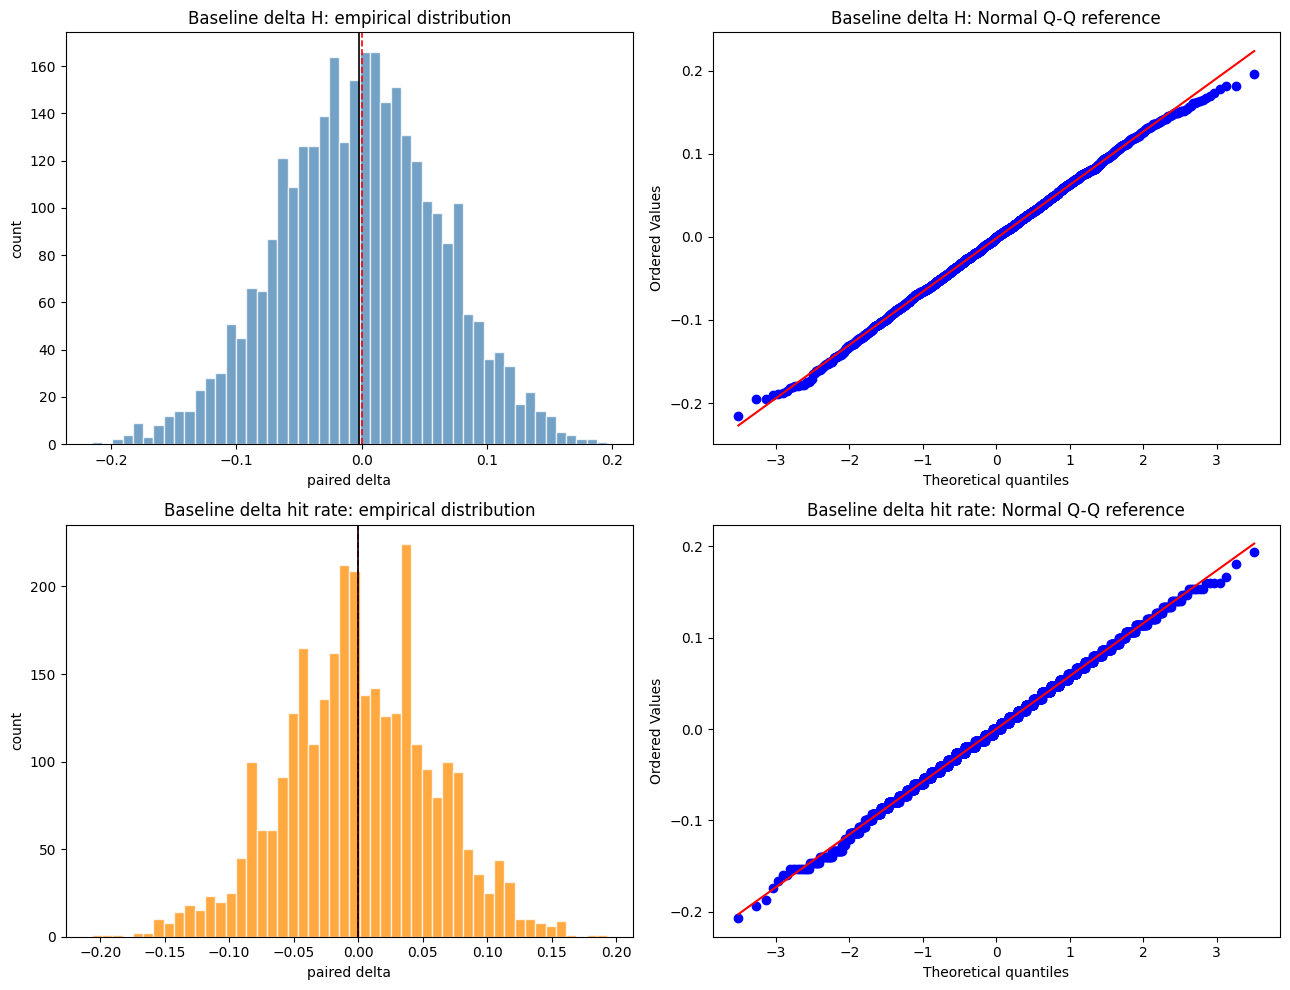

Bounded interpretation: these are empirical Baseline reference distributions.
The mean intervals describe session-aware uncertainty; they do not establish exact
centering, normality, or equivalence to zero.


In [20]:
def c10_delta_summary(data, value_col, label, seed):
    work = data[["session_id", value_col]].dropna().copy()
    grouped = work.groupby("session_id")[value_col].agg(["sum", "count"])
    sums = grouped["sum"].to_numpy(float)
    counts = grouped["count"].to_numpy(float)
    rng_local = default_rng(seed)
    indices = rng_local.integers(0, len(grouped), size=(N_BOOT_C10, len(grouped)))
    draws = sums[indices].sum(axis=1) / counts[indices].sum(axis=1)
    values = work[value_col].to_numpy(float)
    quantiles = np.quantile(values, [0.025, 0.25, 0.50, 0.75, 0.975])
    return {
        "metric": label, "blocks": len(work), "sessions": len(grouped),
        "mean": values.mean(), "mean_ci_low": np.quantile(draws, 0.025),
        "mean_ci_high": np.quantile(draws, 0.975), "sd": values.std(ddof=1),
        "skewness": stats.skew(values, bias=False),
        "excess_kurtosis": stats.kurtosis(values, fisher=True, bias=False),
        "q025": quantiles[0], "q25": quantiles[1], "median": quantiles[2],
        "q75": quantiles[3], "q975": quantiles[4], "values": values,
    }

delta_hurst_c10 = c10_delta_summary(c10_baseline, "delta_hurst", "Baseline delta H", C10_SEED + 11)
delta_hit_c10 = c10_delta_summary(c10_baseline, "delta_hit", "Baseline delta hit rate", C10_SEED + 12)
delta_summary_c10 = pd.DataFrame([
    {key: value for key, value in result.items() if key != "values"}
    for result in (delta_hurst_c10, delta_hit_c10)
])
display(delta_summary_c10.round(8))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, result, color in [
    (0, delta_hurst_c10, "steelblue"),
    (1, delta_hit_c10, "darkorange"),
]:
    values = result["values"]
    axes[row, 0].hist(values, bins=50, color=color, alpha=0.75, edgecolor="white")
    axes[row, 0].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[row, 0].axvline(result["mean"], color="black", linewidth=1.2)
    axes[row, 0].set(title=f'{result["metric"]}: empirical distribution', xlabel="paired delta", ylabel="count")
    stats.probplot(values, dist="norm", plot=axes[row, 1])
    axes[row, 1].set_title(f'{result["metric"]}: Normal Q-Q reference')
plt.tight_layout()
plt.show()

print("Bounded interpretation: these are empirical Baseline reference distributions.")
print("The mean intervals describe session-aware uncertainty; they do not establish exact")
print("centering, normality, or equivalence to zero.")


### Analysis 3 — Covariance contribution to paired-delta variance

For each metric, the observed decomposition is

\[
\operatorname{Var}(S-P)=\operatorname{Var}(S)+\operatorname{Var}(P)-2\operatorname{Cov}(S,P).
\]

The within-session permutation reference produces one covariance and one paired-delta variance statistic per permutation. It does not concatenate permutation-level deltas into a pseudo-sample. The covariance contribution is reported directly as `−2 × covariance`; `1 − variance ratio` is not labeled as a correlation.


In [21]:
def c10_variance_decomposition(data, subject_col, pcs_col, metric, seed):
    work = data[["session_id", subject_col, pcs_col]].dropna().copy()
    subject = work[subject_col].to_numpy(float)
    pcs = work[pcs_col].to_numpy(float)
    groups = [group[[subject_col, pcs_col]].to_numpy(float)
              for _, group in work.groupby("session_id", sort=True)]

    var_subject = np.var(subject, ddof=1)
    var_pcs = np.var(pcs, ddof=1)
    covariance = np.cov(subject, pcs, ddof=1)[0, 1]
    correlation = stats.pearsonr(subject, pcs).statistic
    delta_variance = np.var(subject - pcs, ddof=1)
    variance_sum = var_subject + var_pcs
    variance_ratio = delta_variance / variance_sum
    covariance_contribution = -2.0 * covariance
    sd_delta_over_subject = np.sqrt(delta_variance) / np.sqrt(var_subject)
    identity_error = delta_variance - (variance_sum + covariance_contribution)

    rng_local = default_rng(seed)
    perm_covariance = np.empty(N_PERM_C10)
    perm_delta_variance = np.empty(N_PERM_C10)
    perm_variance_ratio = np.empty(N_PERM_C10)
    for draw in range(N_PERM_C10):
        shuffled = []
        for group in groups:
            permuted = group.copy()
            permuted[:, 1] = rng_local.permutation(permuted[:, 1])
            shuffled.append(permuted)
        stacked = np.concatenate(shuffled, axis=0)
        s_perm, p_perm = stacked[:, 0], stacked[:, 1]
        perm_covariance[draw] = np.cov(s_perm, p_perm, ddof=1)[0, 1]
        perm_delta_variance[draw] = np.var(s_perm - p_perm, ddof=1)
        perm_variance_ratio[draw] = perm_delta_variance[draw] / variance_sum

    covariance_p = ((np.count_nonzero(np.abs(perm_covariance) >= abs(covariance)) + 1)
                    / (N_PERM_C10 + 1))
    return {
        "metric": metric, "blocks": len(work), "sessions": len(groups),
        "subject_variance": var_subject, "pcs_variance": var_pcs,
        "covariance": covariance, "pearson_r": correlation,
        "delta_variance": delta_variance, "variance_sum_benchmark": variance_sum,
        "variance_ratio": variance_ratio,
        "covariance_contribution_minus_2cov": covariance_contribution,
        "sd_delta_over_sd_subject": sd_delta_over_subject,
        "identity_error": identity_error, "within_session_perm_p_covariance": covariance_p,
        "perm_delta_variance_q025": np.quantile(perm_delta_variance, 0.025),
        "perm_delta_variance_q975": np.quantile(perm_delta_variance, 0.975),
        "perm_variance_ratio_q025": np.quantile(perm_variance_ratio, 0.025),
        "perm_variance_ratio_q975": np.quantile(perm_variance_ratio, 0.975),
    }

variance_c10 = pd.DataFrame([
    c10_variance_decomposition(
        c10_baseline, "hurst_subject", "hurst_pcs", "Baseline single-scale R/S ordering score", C10_SEED + 21
    ),
    c10_variance_decomposition(
        c10_baseline, "subject_hit_rate", "pcs_hit_rate", "Baseline target-aligned hit rate", C10_SEED + 22
    ),
])
assert np.all(np.abs(variance_c10["identity_error"]) < 1e-12)
display(variance_c10.round(8))

print("Bounded interpretation: the covariance term quantifies how much observed same-call")
print("covariance contributes to paired-delta variance in this Baseline cohort. Small or")
print("unresolved covariance does not prove independence or show that pairing is universally inert.")


,metric,blocks,sessions,subject_variance,pcs_variance,covariance,pearson_r,delta_variance,variance_sum_benchmark,variance_ratio,covariance_contribution_minus_2cov,sd_delta_over_sd_subject,identity_error,within_session_perm_p_covariance,perm_delta_variance_q025,perm_delta_variance_q975,perm_variance_ratio_q025,perm_variance_ratio_q975
0,Baseline single-scale R/S ordering score,3090,103,0.002114,0.002017,0.000008,0.003729,0.004116,0.004131,0.996272,-0.000015,1.395149,0.0,0.829417,0.003976,0.004264,0.962444,1.032056
1,Baseline target-aligned hit rate,3090,103,0.001678,0.001707,0.000025,0.014864,0.003334,0.003385,0.985136,-0.000050,1.409637,-0.0,0.399860,0.003267,0.003500,0.965257,1.034125


Bounded interpretation: the covariance term quantifies how much observed same-call
covariance contributes to paired-delta variance in this Baseline cohort. Small or
unresolved covariance does not prove independence or show that pairing is universally inert.


### Empirical physical-half calibration for Paper §3.3.4

This synthesis uses the already-computed Baseline physical-half and same-call results at the protocol's actual 150-bit half length. It replaces the former 150–2,400-bit split-length calibration, whose comparison arms were mathematically identical. No new test family is introduced here.

The physical A-minus-B contrast addresses marginal asymmetry before Subject/PCS assignment. The same-call association and paired-delta variance ratio address detectable linear dependence after the recorded assignment. Together they can support a bounded statement of **no detected asymmetry or linear dependence at 150 bits**; they cannot establish exact equivalence, complete independence, or absence of every boundary, cross-lag, nonlinear, or time-varying effect.


In [22]:
# PAPER §3.3.4 SYNTHESIS — reuse finalized results; do not recompute
half_rs_c334 = primary_c9.loc[primary_c9["estimand"].eq("Half A - B R/S ordering score")].iloc[0]
assoc_rs_c334 = association_c10.loc[
    association_c10["condition"].eq("baseline")
    & association_c10["metric"].eq("hurst_subject")
].iloc[0]
variance_rs_c334 = variance_c10.loc[
    variance_c10["metric"].eq("Baseline single-scale R/S ordering score")
].iloc[0]

assert int(half_rs_c334["sessions"]) == int(assoc_rs_c334["sessions"]) == 103
assert int(assoc_rs_c334["blocks"]) == int(variance_rs_c334["blocks"]) == 3090

print("PAPER §3.3.4 — EMPIRICAL PHYSICAL-HALF CALIBRATION")
print(f"Protocol length: 150 bits per physical half; Baseline calls: {int(assoc_rs_c334['blocks']):,}; sessions: {int(assoc_rs_c334['sessions'])}")
print(f"Physical A-B R/S-score difference: {half_rs_c334['estimate']:+.6f}")
print(f"Whole-session bootstrap 95% CI: [{half_rs_c334['ci_low']:+.6f}, {half_rs_c334['ci_high']:+.6f}]")
print(f"Same-call Pearson r: {assoc_rs_c334['pearson_r']:+.4f}")
print(f"Whole-session bootstrap 95% CI: [{assoc_rs_c334['pearson_ci_low']:+.4f}, {assoc_rs_c334['pearson_ci_high']:+.4f}]")
print(f"Within-session permutation p: {assoc_rs_c334['pearson_perm_p']:.4f}")
print(f"Paired-delta variance / sum-of-variances benchmark: {variance_rs_c334['variance_ratio']:.6f}")
print(f"Permutation reference range: [{variance_rs_c334['perm_variance_ratio_q025']:.6f}, {variance_rs_c334['perm_variance_ratio_q975']:.6f}]")
print("Bounded conclusion: no systematic marginal R/S-score asymmetry or detectable")
print("same-call linear association was found at 150 bits. This is not an equivalence")
print("result and does not exclude every boundary, nonlinear, cross-lag, or weak effect.")


PAPER §3.3.4 — EMPIRICAL PHYSICAL-HALF CALIBRATION
Protocol length: 150 bits per physical half; Baseline calls: 3,090; sessions: 103
Physical A-B R/S-score difference: -0.000682
Whole-session bootstrap 95% CI: [-0.003008, +0.001722]
Same-call Pearson r: +0.0037
Whole-session bootstrap 95% CI: [-0.0306, +0.0371]
Within-session permutation p: 0.8357
Paired-delta variance / sum-of-variances benchmark: 0.996272
Permutation reference range: [0.962444, 1.032056]
Bounded conclusion: no systematic marginal R/S-score asymmetry or detectable
same-call linear association was found at 150 bits. This is not an equivalence
result and does not exclude every boundary, nonlinear, cross-lag, or weak effect.


### Baseline empirical paired-delta interpretation boundary

This section supplies an empirical Baseline reference for the two prespecified paired metrics. It permits descriptive statements about observed association, distribution shape, mean uncertainty, and covariance contribution under the retained acquisition regime.

It does **not** establish universal independence, exact zero centering, normality, equivalence, or protection from every shared artifact. Assignment-bit and physical-half diagnostics are handled in **Baseline Raw-Call Positional and Assignment-Bit Diagnostics**; the upstream perturbation checks begin in **Upstream Artifact-Injection Validation**.


# Upstream Artifact-Injection Validation

This positive-control section perturbs the raw 150-bit physical halves **before** Subject/PCS label assignment and metric computation. It then reruns the recorded assignment, target scoring, single-scale R/S-score computation, and paired subtraction.

Each nonzero dose is simulated with multiple independent artifact realizations. Two equal-strength shared-mechanism models are kept distinct: **synchronized**, where both physical halves receive the same affected-position mask, and **independent-position**, where they receive independently realized masks at the same dose. These are bounded tests of specified literal-bit bias and persistence mechanisms—not proof of protection against every hardware artifact. The recorded assignment bit is held fixed, so assignment-bit-altering or assignment-bit-interacting artifacts remain untested.


### Prepare the retained Baseline raw-call cohort

The cohort is joined one-to-one to the canonical retained Baseline blocks. Clean reconstructed scores must equal the frozen scores row by row before any perturbation is applied.


In [23]:
# Retained Baseline calls, joined one-to-one to canonical targets and outcomes
injection_base = baseline_raw_calls.merge(
    base_df[[
        "session_id", "block_idx", "target_bit", "subject_hit_rate", "pcs_hit_rate",
        "hurst_subject", "hurst_pcs", "delta_hit", "delta_hurst"
    ]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one"
).sort_values(["session_id", "block_idx"]).reset_index(drop=True)

assert len(injection_base) == len(base_df) == 3090

physical_A = np.stack(injection_base["halfA"].to_numpy()).astype(np.int8)
physical_B = np.stack(injection_base["halfB"].to_numpy()).astype(np.int8)
assignment = injection_base["bit0"].to_numpy(dtype=np.int8)
targets = injection_base["target_bit"].to_numpy(dtype=np.int8)
injection_sessions = injection_base["session_id"].to_numpy()

def assign_physical_halves(half_a, half_b, assignment_bits):
    """Apply the recorded bit-0 labeling rule after a raw-half perturbation."""
    subject = np.where(assignment_bits[:, None] == 1, half_a, half_b)
    pcs = np.where(assignment_bits[:, None] == 1, half_b, half_a)
    return subject.astype(np.int8), pcs.astype(np.int8)

def score_target_matrix(bit_matrix, target_vector):
    return (bit_matrix == target_vector[:, None]).mean(axis=1)

def hurst_matrix(bit_matrix):
    return np.fromiter((hurstApprox(row) for row in bit_matrix), dtype=float, count=len(bit_matrix))

clean_subject_bits, clean_pcs_bits = assign_physical_halves(physical_A, physical_B, assignment)
clean_subject_hit = score_target_matrix(clean_subject_bits, targets)
clean_pcs_hit = score_target_matrix(clean_pcs_bits, targets)
clean_subject_hurst = hurst_matrix(clean_subject_bits)
clean_pcs_hurst = hurst_matrix(clean_pcs_bits)

assert np.allclose(clean_subject_hit, injection_base["subject_hit_rate"])
assert np.allclose(clean_pcs_hit, injection_base["pcs_hit_rate"])
assert np.allclose(clean_subject_hurst, injection_base["hurst_subject"], equal_nan=True)
assert np.allclose(clean_pcs_hurst, injection_base["hurst_pcs"], equal_nan=True)

clean_delta_hit = clean_subject_hit - clean_pcs_hit
clean_delta_hurst = clean_subject_hurst - clean_pcs_hurst

print(f"Baseline raw calls validated row by row: {len(injection_base):,}")
print("Target counts:", dict(zip(*np.unique(targets, return_counts=True))))
print("Clean reconstruction mismatches: 0")


Baseline raw calls validated row by row: 3,090
Target counts: {np.int8(0): np.int64(1540), np.int8(1): np.int64(1550)}
Clean reconstruction mismatches: 0


### Prespecified perturbations, recovery estimands, and uncertainty

- **Shared literal-bit bias:** a call-level direction pushes both physical halves toward literal 0 or 1. Target-0 and target-1 rows are scored against their actual targets and also reported separately.
- **Shared persistence:** selected positions repeat the preceding bit before Hurst is recomputed.
- **Synchronized masks:** both halves receive the same affected-position mask.
- **Independent-position masks:** both halves receive independent masks drawn at the same dose.
- **Stream-specific control:** a target-relative perturbation is applied to the labeled Subject stream only.
- **Unequal-half failure case:** persistence is stronger in physical half A than half B.

For each realization, the row-wise recovery error is `delta_artifact - delta_clean`. Across-realization SD and quantiles describe injection randomness. Separately, a whole-session bootstrap interval is computed from the row-wise mean recovery error across realizations; this describes session-sampling uncertainty for the simulation-average effect. Signed mean and RMS are reported without KS ratios or “percent cancellation.”


In [24]:
INJECTION_SEED = 20260804
BOOTSTRAP_SEED = 20260805
N_ARTIFACT_REALIZATIONS = 50
N_SESSION_BOOTSTRAPS = 3000
BIAS_DOSES = [0.00, 0.02, 0.05, 0.10, 0.20]
PERSISTENCE_DOSES = [0.00, 0.05, 0.10, 0.20, 0.35]

def apply_literal_bias(bits, direction, dose, uniforms):
    out = bits.copy()
    chosen = uniforms < dose
    out[chosen] = np.broadcast_to(direction[:, None], bits.shape)[chosen]
    return out

def apply_persistence(bits, dose, uniforms):
    out = bits.copy()
    selected = uniforms[:, 1:] < dose
    for position in range(1, bits.shape[1]):
        mask = selected[:, position - 1]
        out[mask, position] = out[mask, position - 1]
    return out

def apply_target_relative_subject(bits, target_vector, dose, uniforms):
    out = bits.copy()
    chosen = uniforms < dose
    target_matrix = np.broadcast_to(target_vector[:, None], bits.shape)
    out[chosen] = target_matrix[chosen]
    return out

def session_bootstrap_mean(change, n_boot=N_SESSION_BOOTSTRAPS, seed=BOOTSTRAP_SEED):
    frame = pd.DataFrame({"session_id": injection_sessions, "change": change}).dropna()
    grouped = frame.groupby("session_id")["change"].agg(["sum", "count"])
    sums, counts = grouped["sum"].to_numpy(), grouped["count"].to_numpy()
    rng = default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng.integers(0, len(grouped), size=len(grouped))
        draws[i] = sums[sampled].sum() / counts[sampled].sum()
    return np.quantile(draws, [0.025, 0.975])

def summarize_realizations(model, metric, dose, errors, subject_changes, pcs_changes,
                           target_group="all"):
    errors = np.asarray(errors, dtype=float)
    subject_changes = np.asarray(subject_changes, dtype=float)
    pcs_changes = np.asarray(pcs_changes, dtype=float)
    if target_group == "all":
        keep = np.ones(len(targets), dtype=bool)
    else:
        keep = targets == int(target_group)
    e = errors[:, keep]
    s = subject_changes[:, keep]
    p = pcs_changes[:, keep]
    realization_means = np.nanmean(e, axis=1)
    mean_row_error = np.nanmean(errors, axis=0)
    ci_low, ci_high = session_bootstrap_mean(
        mean_row_error[keep],
        seed=BOOTSTRAP_SEED + int(dose * 10000) + (0 if target_group == "all" else 100 + int(target_group))
    ) if target_group == "all" else session_bootstrap_mean_for_subset(mean_row_error, keep, dose, target_group)
    return {
        "model": model, "metric": metric, "dose": dose, "target_group": str(target_group),
        "n_realizations": errors.shape[0],
        "subject_change_rms": np.sqrt(np.nanmean(np.square(s))),
        "pcs_change_rms": np.sqrt(np.nanmean(np.square(p))),
        "recovery_error_mean": np.nanmean(e),
        "session_ci_low": ci_low, "session_ci_high": ci_high,
        "realization_mean_sd": np.nanstd(realization_means, ddof=1) if len(realization_means) > 1 else 0.0,
        "realization_q025": np.nanquantile(realization_means, 0.025),
        "realization_q975": np.nanquantile(realization_means, 0.975),
        "recovery_error_rms": np.sqrt(np.nanmean(np.square(e))),
    }

def session_bootstrap_mean_for_subset(change, keep, dose, target_group):
    frame = pd.DataFrame({
        "session_id": injection_sessions[keep], "change": change[keep]
    }).dropna()
    grouped = frame.groupby("session_id")["change"].agg(["sum", "count"])
    sums, counts = grouped["sum"].to_numpy(), grouped["count"].to_numpy()
    rng = default_rng(BOOTSTRAP_SEED + int(dose * 10000) + 100 + int(target_group))
    draws = np.empty(N_SESSION_BOOTSTRAPS)
    for i in range(N_SESSION_BOOTSTRAPS):
        sampled = rng.integers(0, len(grouped), size=len(grouped))
        draws[i] = sums[sampled].sum() / counts[sampled].sum()
    return np.quantile(draws, [0.025, 0.975])

def simulate_equal_half_model(kind, dose, synchronized, realization_seed):
    rng = default_rng(realization_seed)
    if kind == "literal bias":
        direction = rng.integers(0, 2, size=len(physical_A), dtype=np.int8)
        u_a = rng.random(physical_A.shape)
        u_b = u_a if synchronized else rng.random(physical_B.shape)
        a_art = apply_literal_bias(physical_A, direction, dose, u_a)
        b_art = apply_literal_bias(physical_B, direction, dose, u_b)
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = score_target_matrix(subj_bits, targets), score_target_matrix(pcs_bits, targets)
        clean_subj, clean_p = clean_subject_hit, clean_pcs_hit
    else:
        u_a = rng.random(physical_A.shape)
        u_b = u_a if synchronized else rng.random(physical_B.shape)
        a_art = apply_persistence(physical_A, dose, u_a)
        b_art = apply_persistence(physical_B, dose, u_b)
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = hurst_matrix(subj_bits), hurst_matrix(pcs_bits)
        clean_subj, clean_p = clean_subject_hurst, clean_pcs_hurst
    return (subj - pcs) - (clean_subj - clean_p), subj - clean_subj, pcs - clean_p

print(f"Artifact realizations per nonzero dose: {N_ARTIFACT_REALIZATIONS}")
print(f"Whole-session bootstrap draws: {N_SESSION_BOOTSTRAPS}")


Artifact realizations per nonzero dose: 50
Whole-session bootstrap draws: 3000


### Shared literal-bit bias: synchronized versus independent-position masks

This tests a raw composition artifact, not generic “hit-rate drift.” Its target-aligned consequences can reverse with the target, so target-0 and target-1 diagnostics are included. The two mask models distinguish synchronized common-mode disturbance from equal-strength disturbance with independently affected positions.


In [25]:
bias_rows = []
for synchronized in [True, False]:
    mask_label = "synchronized mask" if synchronized else "independent-position masks"
    for dose in BIAS_DOSES:
        n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
        simulated = [simulate_equal_half_model(
            "literal bias", dose, synchronized,
            INJECTION_SEED + 100000 * int(not synchronized) + int(dose * 10000) + r
        ) for r in range(n_rep)]
        errors, subject_changes, pcs_changes = map(np.stack, zip(*simulated))
        for target_group in ["all", 0, 1]:
            bias_rows.append(summarize_realizations(
                f"shared literal bias — {mask_label}", "target-aligned hit rate", dose,
                errors, subject_changes, pcs_changes, target_group
            ))

bias_results = pd.DataFrame(bias_rows)
print(bias_results[[
    "model", "dose", "target_group", "recovery_error_mean", "session_ci_low",
    "session_ci_high", "realization_mean_sd", "realization_q025",
    "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
assert np.all(bias_results.loc[bias_results["dose"].eq(0), "recovery_error_rms"] == 0)


                                           model     dose target_group  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared literal bias — synchronized mask 0.000000          all             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.000000            0             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.000000            1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.020000          all            -0.000031       -0.000088         0.000024             0.000146         -0.000263          0.000220           

### Shared persistence: synchronized versus independent-position masks

Persistence is applied upstream to each physical half and the single-scale R/S ordering score is recomputed. Synchronized masks test a tightly shared position-level disturbance; independent-position masks test equal dose and mechanism without identical affected positions. Neither model alters the recorded assignment bit.


In [26]:
persistence_rows = []
for synchronized in [True, False]:
    mask_label = "synchronized mask" if synchronized else "independent-position masks"
    for dose in PERSISTENCE_DOSES:
        n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
        simulated = [simulate_equal_half_model(
            "persistence", dose, synchronized,
            INJECTION_SEED + 500000 + 100000 * int(not synchronized) + int(dose * 10000) + r
        ) for r in range(n_rep)]
        errors, subject_changes, pcs_changes = map(np.stack, zip(*simulated))
        persistence_rows.append(summarize_realizations(
            f"shared persistence — {mask_label}", "single-scale R/S ordering score", dose,
            errors, subject_changes, pcs_changes
        ))

persistence_results = pd.DataFrame(persistence_rows)
print(persistence_results[[
    "model", "dose", "subject_change_rms", "pcs_change_rms", "recovery_error_mean",
    "session_ci_low", "session_ci_high", "realization_mean_sd", "realization_q025",
    "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
assert np.all(persistence_results.loc[persistence_results["dose"].eq(0), "recovery_error_rms"] == 0)


                                          model     dose  subject_change_rms  pcs_change_rms  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared persistence — synchronized mask 0.000000            0.000000        0.000000             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared persistence — synchronized mask 0.050000            0.024737        0.024553             0.000238       -0.000147         0.000616             0.000569         -0.000753          0.001327            0.031930
         shared persistence — synchronized mask 0.100000            0.036053        0.035642             0.000422       -0.000234         0.001082             0.000643         -0.000738          0.001549            0.043243
         shared persistence — synchronized mask 0.200000            0.054905        0.054331            

### Stream-specific control and unequal-half failure case

These controls use multiple realizations too. The labeled Subject-only intervention checks that a stream-specific hit-rate change survives subtraction. Unequal-half persistence checks the expected limitation that a disturbance of different strength in the two physical halves is not common-mode.


In [27]:
control_rows, unequal_rows = [], []
for dose in BIAS_DOSES:
    n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
    sims = []
    for r in range(n_rep):
        rng = default_rng(INJECTION_SEED + 900000 + int(dose * 10000) + r)
        subject_art_bits = apply_target_relative_subject(
            clean_subject_bits, targets, dose, rng.random(clean_subject_bits.shape)
        )
        subject_art = score_target_matrix(subject_art_bits, targets)
        error = subject_art - clean_subject_hit
        sims.append((error, error, np.zeros_like(error)))
    errors, subject_changes, pcs_changes = map(np.stack, zip(*sims))
    control_rows.append(summarize_realizations(
        "labeled Subject-only target shift", "target-aligned hit rate", dose,
        errors, subject_changes, pcs_changes
    ))

for dose in PERSISTENCE_DOSES:
    n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
    sims = []
    for r in range(n_rep):
        rng = default_rng(INJECTION_SEED + 1200000 + int(dose * 10000) + r)
        a_art = apply_persistence(physical_A, dose, rng.random(physical_A.shape))
        b_art = apply_persistence(physical_B, dose / 2.0, rng.random(physical_B.shape))
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = hurst_matrix(subj_bits), hurst_matrix(pcs_bits)
        sims.append(((subj - pcs) - clean_delta_hurst,
                     subj - clean_subject_hurst, pcs - clean_pcs_hurst))
    errors, subject_changes, pcs_changes = map(np.stack, zip(*sims))
    unequal_rows.append(summarize_realizations(
        "unequal-half persistence (A=1.0x, B=0.5x)", "single-scale R/S ordering score", dose,
        errors, subject_changes, pcs_changes
    ))

control_results = pd.DataFrame(control_rows)
unequal_results = pd.DataFrame(unequal_rows)
print("Subject-only control")
print(control_results[["dose", "recovery_error_mean", "session_ci_low", "session_ci_high", "realization_mean_sd", "recovery_error_rms"]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nUnequal-half failure case")
print(unequal_results[["dose", "recovery_error_mean", "session_ci_low", "session_ci_high", "realization_mean_sd", "recovery_error_rms"]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))


Subject-only control
    dose  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  recovery_error_rms
0.000000             0.000000        0.000000         0.000000             0.000000            0.000000
0.020000             0.010019        0.009968         0.010068             0.000129            0.012912
0.050000             0.024949        0.024859         0.025041             0.000245            0.028020
0.100000             0.050043        0.049881         0.050199             0.000287            0.053122
0.200000             0.099961        0.099652         0.100261             0.000345            0.102921

Unequal-half failure case
    dose  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  recovery_error_rms
0.000000             0.000000        0.000000         0.000000             0.000000            0.000000
0.050000             0.000308       -0.000111         0.000723             0.000476            0.028784
0.100000        

### Dose-response plots and combined recovery table

Plots use the simulation-average RMS. Tables retain two separate uncertainty descriptions: whole-session bootstrap intervals for the across-realization mean row effect, and across-realization SD/quantiles for injection randomness.


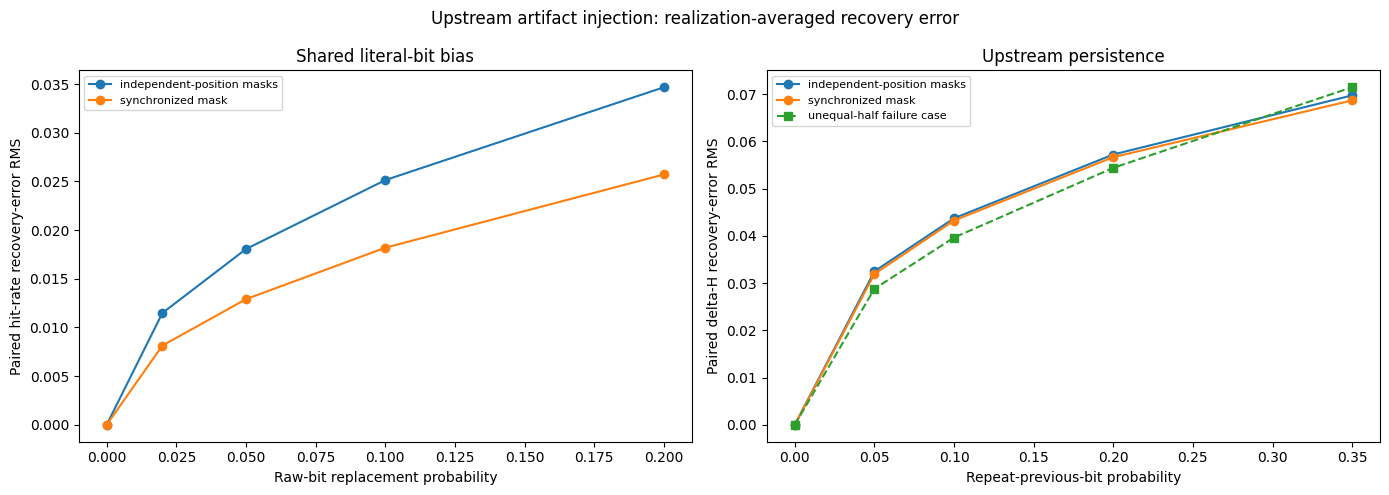


Combined recovery table
                                           model                          metric     dose target_group  n_realizations  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000          all               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000            0               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000            1               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.00

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bias_plot = bias_results[bias_results["target_group"].eq("all")]
for model, group in bias_plot.groupby("model"):
    axes[0].plot(group["dose"], group["recovery_error_rms"], "o-", label=model.split("—")[-1].strip())
axes[0].set(title="Shared literal-bit bias", xlabel="Raw-bit replacement probability", ylabel="Paired hit-rate recovery-error RMS")
axes[0].legend(fontsize=8)

for model, group in persistence_results.groupby("model"):
    axes[1].plot(group["dose"], group["recovery_error_rms"], "o-", label=model.split("—")[-1].strip())
axes[1].plot(unequal_results["dose"], unequal_results["recovery_error_rms"], "s--", label="unequal-half failure case")
axes[1].set(title="Upstream persistence", xlabel="Repeat-previous-bit probability", ylabel="Paired delta-H recovery-error RMS")
axes[1].legend(fontsize=8)

fig.suptitle("Upstream artifact injection: realization-averaged recovery error")
plt.tight_layout()
plt.show()

architecture_injection_results = pd.concat(
    [bias_results, persistence_results, control_results, unequal_results], ignore_index=True
)
print("\nCombined recovery table")
print(architecture_injection_results[[
    "model", "metric", "dose", "target_group", "n_realizations",
    "recovery_error_mean", "session_ci_low", "session_ci_high",
    "realization_mean_sd", "realization_q025", "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))


### Bounded interpretation of the injection validation

The code below distinguishes synchronized common-mode recovery from equal-strength independently positioned disturbance. It also keeps injection randomness separate from session-sampling uncertainty. No null result is converted into universal validation.


In [29]:
print("=" * 76)
print("UPSTREAM INJECTION VALIDATION — BOUNDED INTERPRETATION")
print("=" * 76)
print(f"""
The raw-call pipeline was exercised on {len(injection_base):,} retained Baseline blocks from
{injection_base['session_id'].nunique()} sessions. Every clean reconstruction matched the frozen
Subject/PCS scores before perturbation.

Literal-bit composition bias and within-half persistence were each tested under two mechanisms:
(1) synchronized affected-position masks in both physical halves and (2) independently realized
affected positions at the same dose. Every nonzero dose used {N_ARTIFACT_REALIZATIONS} independent
artifact realizations. Across-realization variation is reported separately from whole-session
bootstrap uncertainty. Literal-bias results are also shown separately for target-0 and target-1
blocks because literal composition and target-aligned hit rate are not interchangeable.

The Subject-only control checks sensitivity to a labeled-stream intervention. The unequal-half
persistence case demonstrates that a disturbance of different strength in the two physical halves
is not common-mode and need not cancel.

These simulations validate implementation only for the specified mechanisms, doses, and retained
Baseline calls. They do not prove independence, exact cancellation, universal hardware cleanliness,
or protection against target-dependent, cross-call, unequal-half, or unmodeled artifacts. The
recorded assignment bit is held fixed throughout; artifacts that alter or interact with that bit
remain explicitly untested.
""")


UPSTREAM INJECTION VALIDATION — BOUNDED INTERPRETATION

The raw-call pipeline was exercised on 3,090 retained Baseline blocks from
103 sessions. Every clean reconstruction matched the frozen
Subject/PCS scores before perturbation.

Literal-bit composition bias and within-half persistence were each tested under two mechanisms:
(1) synchronized affected-position masks in both physical halves and (2) independently realized
affected positions at the same dose. Every nonzero dose used 50 independent
artifact realizations. Across-realization variation is reported separately from whole-session
bootstrap uncertainty. Literal-bias results are also shown separately for target-0 and target-1
blocks because literal composition and target-aligned hit rate are not interchangeable.

The Subject-only control checks sensitivity to a labeled-stream intervention. The unequal-half
persistence case demonstrates that a disturbance of different strength in the two physical halves
is not common-mode and need 

# Latent-H Difference and Estimator Calibration

This simulation is separate from upstream artifact cancellation. It asks whether the notebook's
actual single-scale 150-bit R/S estimator responds to a known difference in the latent H parameter of
two generated binary streams.

The generator uses thresholded fractional Gaussian noise (fGn). The stated H values are therefore
parameters of the latent Gaussian process. Thresholding preserves the long-memory exponent
asymptotically, but a 150-bit binary sequence does not possess an exactly observable finite-sample
“true H.” Results must be described as generator- and estimator-specific calibration, not as a
universal property of all binary long-memory processes.


In [30]:
# Prespecified latent-H grid and exact vectorized implementation of hurstApprox
HURST_CALIBRATION_SEED = 20260806
HURST_CALIBRATION_N = 10000
HURST_CALIBRATION_BATCH = 500
HURST_CALIBRATION_LENGTH = 150
HURST_BASE_VALUES = [0.50, 0.60, 0.70, 0.80]
HURST_EFFECT_SIZES = [0.02, 0.05, 0.10]

def fgn_covariance_matrix(h_value, n=HURST_CALIBRATION_LENGTH):
    # Unit-variance fractional Gaussian noise autocovariance.
    lag = np.arange(n, dtype=float)
    gamma = 0.5 * (
        np.power(lag + 1.0, 2.0 * h_value)
        - 2.0 * np.power(lag, 2.0 * h_value)
        + np.power(np.abs(lag - 1.0), 2.0 * h_value)
    )
    distance = np.abs(np.subtract.outer(np.arange(n), np.arange(n)))
    covariance = gamma[distance]
    # Small diagonal jitter protects Cholesky from floating-point roundoff.
    return covariance + np.eye(n) * 1e-12

def hurst_approx_matrix(bit_matrix):
    # Algebraically identical to hurstApprox, evaluated rowwise.
    bits = np.asarray(bit_matrix, dtype=np.int8)
    x = np.where(bits != 0, 1.0, -1.0)
    centered = x - x.mean(axis=1, keepdims=True)
    cumulative = np.cumsum(centered, axis=1)
    cumulative_with_origin = np.concatenate(
        [np.zeros((len(bits), 1)), cumulative], axis=1
    )
    spread = np.ptp(cumulative_with_origin, axis=1)
    scale = np.sqrt(np.mean(np.square(centered), axis=1))
    ratio = np.divide(
        spread, scale, out=np.ones_like(spread), where=np.isfinite(scale) & (scale != 0)
    )
    ratio = np.where(np.isfinite(ratio) & (ratio != 0), ratio, 1.0)
    estimate = np.log(ratio) / np.log(bits.shape[1])
    estimate = np.where(np.isfinite(estimate), estimate, 0.5)
    return np.clip(estimate, 0.0, 1.0)

def simulate_binary_fgn_estimates(h_value, n_series, seed):
    rng_local = default_rng(seed)
    chol = np.linalg.cholesky(
        fgn_covariance_matrix(h_value, HURST_CALIBRATION_LENGTH)
    )
    estimates = np.empty(n_series, dtype=float)
    for start in range(0, n_series, HURST_CALIBRATION_BATCH):
        stop = min(start + HURST_CALIBRATION_BATCH, n_series)
        latent = rng_local.standard_normal(
            (stop - start, HURST_CALIBRATION_LENGTH)
        ) @ chol.T
        bits = (latent > 0.0).astype(np.int8)
        estimates[start:stop] = hurst_approx_matrix(bits)
    return estimates

# Confirm that vectorization has not changed the experiment's estimator.
_validation_rng = default_rng(HURST_CALIBRATION_SEED)
_validation_bits = _validation_rng.integers(0, 2, size=(25, 150), dtype=np.int8)
assert np.allclose(
    hurst_approx_matrix(_validation_bits),
    np.array([hurstApprox(row) for row in _validation_bits])
)

print(f"Binary fGn series per H value: {HURST_CALIBRATION_N:,}")
print(f"Series length: {HURST_CALIBRATION_LENGTH} bits")
print("Baseline latent H values:", HURST_BASE_VALUES)
print("Injected latent-H differences:", HURST_EFFECT_SIZES)


Binary fGn series per H value: 10,000
Series length: 150 bits
Baseline latent H values: [0.5, 0.6, 0.7, 0.8]
Injected latent-H differences: [0.02, 0.05, 0.1]



Estimator calibration by latent H
 latent_H  mean_H_hat  estimator_bias  estimator_sd  rmse_to_latent_H
 0.500000    0.530026        0.030026      0.044876          0.053993
 0.520000    0.534571        0.014571      0.045528          0.047800
 0.550000    0.544055       -0.005945      0.046340          0.046717
 0.600000    0.561601       -0.038399      0.047758          0.061278
 0.620000    0.568452       -0.051548      0.048686          0.070903
 0.650000    0.579492       -0.070508      0.049259          0.086009
 0.700000    0.597985       -0.102015      0.051150          0.114119
 0.720000    0.605461       -0.114539      0.051451          0.125563
 0.750000    0.616138       -0.133862      0.052268          0.143704
 0.800000    0.633845       -0.166155      0.053380          0.174518
 0.820000    0.640157       -0.179843      0.054792          0.188004
 0.850000    0.647993       -0.202007      0.055980          0.209620
 0.900000    0.655039       -0.244961      0.068891    

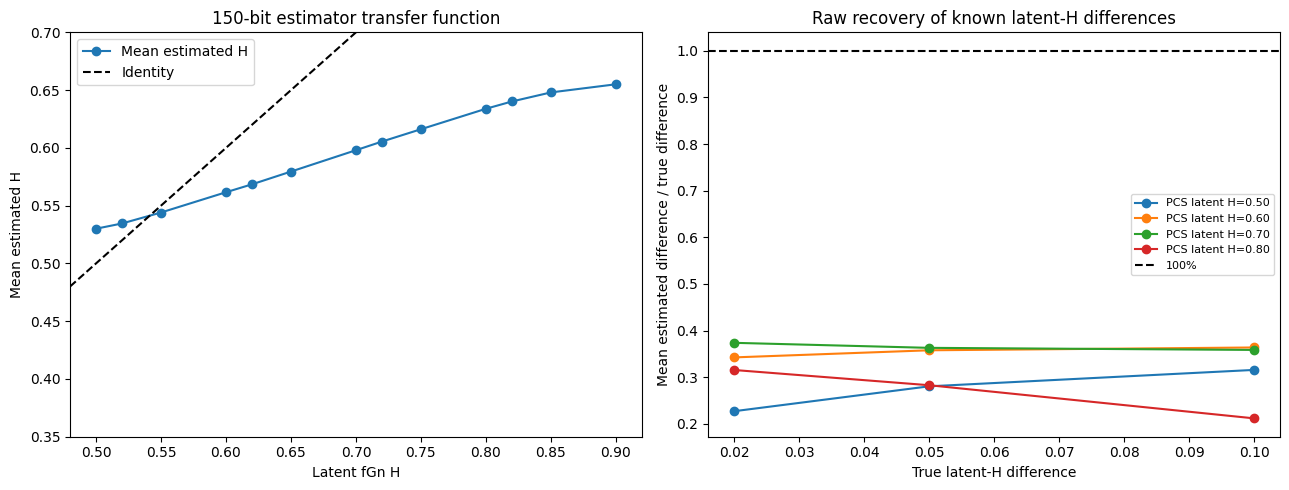

In [31]:
# Calibrate each required H value once, then form independent Subject/PCS pairs.
required_h_values = sorted({
    round(base_h, 2) for base_h in HURST_BASE_VALUES
} | {
    round(base_h + effect, 2)
    for base_h in HURST_BASE_VALUES for effect in HURST_EFFECT_SIZES
})

hurst_calibration_draws = {}
for index, h_value in enumerate(required_h_values):
    hurst_calibration_draws[h_value] = simulate_binary_fgn_estimates(
        h_value,
        HURST_CALIBRATION_N,
        HURST_CALIBRATION_SEED + 10000 * index
    )

hurst_parameter_calibration = pd.DataFrame([
    {
        "latent_H": h_value,
        "mean_H_hat": np.mean(estimates),
        "estimator_bias": np.mean(estimates) - h_value,
        "estimator_sd": np.std(estimates, ddof=1),
        "rmse_to_latent_H": np.sqrt(np.mean(np.square(estimates - h_value))),
    }
    for h_value, estimates in hurst_calibration_draws.items()
]).sort_values("latent_H").reset_index(drop=True)

recovery_rows = []
for base_h in HURST_BASE_VALUES:
    pcs_estimates = hurst_calibration_draws[round(base_h, 2)]
    for true_difference in HURST_EFFECT_SIZES:
        subject_h = round(base_h + true_difference, 2)
        subject_estimates = hurst_calibration_draws[subject_h]
        estimated_difference = subject_estimates - pcs_estimates
        recovered_mean = np.mean(estimated_difference)
        mc_se = np.std(estimated_difference, ddof=1) / np.sqrt(len(estimated_difference))
        subject_bias = np.mean(subject_estimates) - subject_h
        pcs_bias = np.mean(pcs_estimates) - base_h
        differential_bias = subject_bias - pcs_bias
        recovery_rows.append({
            "pcs_latent_H": base_h,
            "subject_latent_H": subject_h,
            "true_H_difference": true_difference,
            "mean_estimated_difference": recovered_mean,
            "raw_recovery_ratio": recovered_mean / true_difference,
            "differential_estimator_bias": differential_bias,
            "identity_check": recovered_mean - (true_difference + differential_bias),
            "mc_ci_low": recovered_mean - 1.96 * mc_se,
            "mc_ci_high": recovered_mean + 1.96 * mc_se,
            "paired_difference_sd": np.std(estimated_difference, ddof=1),
            "paired_rmse_to_true_difference": np.sqrt(
                np.mean(np.square(estimated_difference - true_difference))
            ),
            "block_sign_concordance": np.mean(estimated_difference > 0),
            "n_generated_pairs": len(estimated_difference),
        })

known_hurst_recovery_results = pd.DataFrame(recovery_rows)
assert np.allclose(
    known_hurst_recovery_results["identity_check"], 0.0, atol=1e-12
)

print("\nEstimator calibration by latent H")
print(hurst_parameter_calibration.to_string(
    index=False, float_format=lambda x: f"{x:.6f}"
))
print("\nLatent-H difference response")
print(known_hurst_recovery_results[[
    "pcs_latent_H", "subject_latent_H", "true_H_difference",
    "mean_estimated_difference", "raw_recovery_ratio",
    "differential_estimator_bias", "mc_ci_low", "mc_ci_high",
    "paired_difference_sd", "paired_rmse_to_true_difference",
    "block_sign_concordance", "n_generated_pairs"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    hurst_parameter_calibration["latent_H"],
    hurst_parameter_calibration["mean_H_hat"], "o-", label="Mean estimated H"
)
axes[0].plot([0.48, 0.92], [0.48, 0.92], "--", color="black", label="Identity")
axes[0].set(
    title="150-bit estimator transfer function",
    xlabel="Latent fGn H", ylabel="Mean estimated H",
    xlim=(0.48, 0.92), ylim=(0.35, 0.70)
)
axes[0].legend()

for base_h, group in known_hurst_recovery_results.groupby("pcs_latent_H"):
    axes[1].plot(
        group["true_H_difference"], group["raw_recovery_ratio"],
        "o-", label=f"PCS latent H={base_h:.2f}"
    )
axes[1].axhline(1.0, linestyle="--", color="black", label="100%")
axes[1].set(
    title="Raw recovery of known latent-H differences",
    xlabel="True latent-H difference", ylabel="Mean estimated difference / true difference"
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation boundary for latent-H calibration

The raw recovery ratio is the mean estimated paired difference divided by the known latent-H
difference. It is not bias-corrected. The table separately reports the estimator bias at each
latent H and its difference between Subject and PCS; algebraically,

$$
E(\widehat H_S-\widehat H_P)
= (H_S-H_P)+\{\operatorname{Bias}(\widehat H_S)-\operatorname{Bias}(\widehat H_P)\}.
$$

This separation is deliberate. Subtracting the simulated differential bias and then reporting a
“corrected recovery rate” would reproduce the known input by construction and would not be an
independent validation. The Monte Carlo interval describes simulation precision, not uncertainty
for the observed experiment. The block sign-concordance column is descriptive and is not
study-level statistical power.

The calibration validates only thresholded fGn under the prespecified H values, effect sizes,
150-bit length, and this exact single-scale estimator. It does not establish recovery for every
binary long-memory generator, nonstationary process, or physical mechanism.


# Notebook 1 Conclusions and Transition to Notebook 2

## Structural architecture status

- The five supplied frozen inputs are loaded once and fingerprinted.
- The three-subtest NIST-style audit battery is reported on the 1,771 audits with complete stored subtests; the 120 legacy audits remain explicitly missing, and the battery is not described as a full SP 800-22 suite.
- Frozen block/session/raw-call joins are cardinality-checked, and the 157 excluded rows are reconciled before analysis.
- For every matched raw call, the 301-bit hash, physical split, bit-0 Subject/PCS assignment, and stored labeled streams agree exactly.
- Every retained block is scored against its actual `target_bit`; literal one-fractions are kept distinct from target-aligned hit rates.
- Canonical paired hit-rate and R/S-score estimands are row aligned.
- At the implemented 150-bit half length, the Baseline physical-half synthesis found no detected marginal R/S-score asymmetry or same-call linear association; this is not treated as equivalence or complete independence.
- Session-clustered bootstrap, permutation, and paired sign-flip procedures preserve the relevant session hierarchy; Human-participant sensitivity is reported where stable repeated-participant identifiers are available.
- Artifact injection now uses specified upstream raw-bit perturbations and reports recovery error with session-aware uncertainty, including a stream-specific control and unequal-half failure case.
- A separate thresholded-fGn calibration reports how the exact 150-bit estimator responds to known latent-H differences and shows how estimator bias changes with latent H.
- Hit-count dispersion/tail diagnostics now use discrete events and whole-session uncertainty; same-position mutual information is bias-calibrated with within-block circular shifts and session-aware inference.
- Paper-required PCS within-block lag-1/n-gram/profile-slope comparisons and Subject–PCS correlation/joint-distribution condition comparisons now move intact session bundles; the paired R/S-score-delta variance comparison uses one session mean per session.

Together, these checks verify the frozen-data encoding and exercise the paired-analysis implementation under the specified diagnostics and simulated mechanisms. The latent-H calibration is limited to its generator, parameter values, sequence length, and estimator. The notebook does not establish universal independence, unbiasedness, recovery, or cancellation of all possible artifacts. Notebook 2 analyses must use the canonical paired estimands and preserve session and participant dependence appropriate to each claim.
